# Анализ пунктуационной сложности корпусов НКРЯ

## Определение и метод

Под **пунктуационной сложностью** текста будем понимать степень структурной и функциональной насыщенности его системы знаков препинания, влияющая на трудность его создания пишущим и восприятия читающим. Уровень пунктуационной сложности отражает разнообразие используемых пунктуационных символов; частоту их применения; сложность синтаксических и дискурсивных конструкций, маркируемых используемыми знаками препинания; экспрессивную и стилистическую нагрузку, передаваемую через пунктуацию.

Для определения уровня пунктуационной сложности будем вычислять:

- *Абсолютные метрики* (количество знаков препинания; длина текста в токенах и символах; количество уникальных знаков)

- *Плотность пунктуации* (число знаков препинания на 1000 символов и на 1000 токенов)

- *Разнообразие знаков препинания* (количество различных типов знаков препинания в тексте и энтропию распределения их частот)

- Среднюю, минимальную и максимальную *длину синтагматических отрезков* в токенах и символах (рассматриваем как расстояние между любыми соседними знаками препинания, так и между знаками определённого типа: между парными тире, запятыми, точками с запятой; открывающей и закрывающей кавычками, скобками)

Для анализа первого из трёх корпусов метрики будут вычисляться по-разному: методом скользящего окна и методом деления текста на блоки по 1000 символов или 1000 токенов. Затем, если показатели будут различаться незначительно, остановимся на одном методе.

In [ ]:
import os
import zipfile
import xml.etree.ElementTree as ET
import re
from collections import Counter, defaultdict
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from typing import List, Dict, Tuple, Set, Optional
from concurrent.futures import ProcessPoolExecutor, as_completed
import matplotlib.pyplot as plt
import multiprocessing
import seaborn as sns
import time
import pickle

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 30)

## Обучающий корпус

### Расчёты

In [ ]:
class PunctuationComplexityAnalyzer:
    def __init__(self):
        self.reset_for_new_file()

    def reset_for_new_file(self):
        self.text = ""
        self.tokens = []
        self.punctuation_marks = []
        self.punctuation_by_type = Counter()
        self.sentences = []
        self.filename = ""
        self.filepath = ""
        self._punct_positions_cache = None
        self._word_positions_cache = None

    def extract_text_from_xml(self, file_path: str) -> str:
        try:
            tree = ET.parse(file_path)
            root = tree.getroot()

            text_parts = []
            for elem in root.iter():
                if elem.text and elem.tag not in ['meta', 'head', 'span']:
                    if elem.get('class') != 'note':
                        text_parts.append(elem.text)
                if elem.tail and elem.tag not in ['meta', 'head', 'span']:
                    if elem.get('class') != 'note':
                        text_parts.append(elem.tail)

            self.text = ' '.join(text_parts)
            self.text = re.sub(r'\s+', ' ', self.text).strip()
            return self.text

        except Exception as e:
            print(f"Ошибка при чтении XML {file_path}: {e}")
            return ""

    def tokenize(self) -> List[str]:
        words_text = re.sub(r'[^\w\s]', ' ', self.text)
        self.tokens = [word for word in words_text.split() if word.strip()]
        return self.tokens

    def extract_punctuation(self) -> List[str]:
        punct_pattern = r'[.,!?;:\-–—"«»\'\(\)\[\]{}…]|\.{3,}'
        self.punctuation_marks = []

        for match in re.finditer(punct_pattern, self.text):
            punct = match.group()
            if punct.startswith('...'):
                punct = '…'
            self.punctuation_marks.append(punct)

        self.punctuation_by_type = Counter(self.punctuation_marks)
        return self.punctuation_marks

    def split_into_sentences(self) -> List[str]:
        sentence_endings = r'(?<=[.!?…])\s+(?=[А-ЯA-Z])'
        self.sentences = re.split(sentence_endings, self.text)
        self.sentences = [s.strip() for s in self.sentences if s.strip()]
        return self.sentences

    def get_absolute_metrics(self) -> Dict:
        char_count = len(self.text)
        token_count = len(self.tokens)
        punct_count = len(self.punctuation_marks)

        unique_punct = set()
        for p in self.punctuation_marks:
            if p in ['—', '–', ' - ', '--']:
                unique_punct.add('—')
            elif p in ['«', '»', '"', "'"]:
                unique_punct.add('«»')
            elif p == '…':
                unique_punct.add('…')
            else:
                unique_punct.add(p)

        return {
            'filename': self.filename,
            'filepath': self.filepath,
            'total_characters': char_count,
            'total_tokens': token_count,
            'total_punctuation': punct_count,
            'unique_punctuation_count': len(unique_punct),
            'unique_punctuation_list': sorted(list(unique_punct))
        }

    def calculate_punctuation_density(self) -> Dict:
        char_count = len(self.text)
        token_count = len(self.tokens)
        punct_count = len(self.punctuation_marks)

        density_per_1000_tokens = (punct_count / token_count) * 1000 if token_count > 0 else 0
        density_per_1000_chars = (punct_count / char_count) * 1000 if char_count > 0 else 0

        all_punct_positions = []
        for match in re.finditer(r'[.,!?;:\-–—"«»\'\(\)\[\]{}…]|\.{3,}', self.text):
            all_punct_positions.append(match.start())

        window_size_tokens = 1000
        window_size_chars = 1000

        window_densities_tokens = []
        window_densities_chars = []

        if char_count >= window_size_chars:
            punct_flags = [0] * char_count
            for pos in all_punct_positions:
                if pos < char_count:
                    punct_flags[pos] = 1

            current_sum = sum(punct_flags[:window_size_chars])
            window_densities_chars.append(current_sum)

            for i in range(1, char_count - window_size_chars + 1):
                current_sum = current_sum - punct_flags[i-1] + punct_flags[i + window_size_chars - 1]
                window_densities_chars.append(current_sum)

        if token_count >= window_size_tokens and token_count < 50000:
            token_positions = []
            for match in re.finditer(r'\b\w+\b', self.text):
                token_positions.append(match.start())

            step = max(1, token_count // 100)
            for start_idx in range(0, token_count - window_size_tokens + 1, step):
                end_idx = start_idx + window_size_tokens
                start_char = token_positions[start_idx]
                end_char = token_positions[end_idx - 1] + 50

                punct_in_window = sum(1 for pos in all_punct_positions if start_char <= pos < end_char)
                window_densities_tokens.append(punct_in_window)

        block_densities_tokens = []
        block_densities_chars = []

        for i in range(0, char_count, 1000):
            end_char_idx = min(i + 1000, char_count)
            if end_char_idx - i < 200:
                continue

            punct_in_block = sum(1 for pos in all_punct_positions if i <= pos < end_char_idx)
            block_char_count = end_char_idx - i
            density = (punct_in_block / block_char_count) * 1000
            block_densities_chars.append(density)

        if token_count >= 1000:
            token_positions = []
            for match in re.finditer(r'\b\w+\b', self.text):
                token_positions.append(match.start())

            for i in range(0, len(token_positions), 1000):
                end_idx = min(i + 1000, len(token_positions))
                if end_idx - i < 100:
                    continue

                start_char = token_positions[i]
                end_char = token_positions[end_idx - 1] + 50

                punct_in_block = sum(1 for pos in all_punct_positions if start_char <= pos < end_char)
                block_token_count = end_idx - i
                density = (punct_in_block / block_token_count) * 1000
                block_densities_tokens.append(density)

        return {
            'density_per_1000_tokens': density_per_1000_tokens,
            'density_per_1000_chars': density_per_1000_chars,
            'window_tokens_mean': np.mean(window_densities_tokens) if window_densities_tokens else density_per_1000_tokens,
            'window_tokens_std': np.std(window_densities_tokens) if window_densities_tokens else 0,
            'window_tokens_min': min(window_densities_tokens) if window_densities_tokens else 0,
            'window_tokens_max': max(window_densities_tokens) if window_densities_tokens else 0,
            'window_chars_mean': np.mean(window_densities_chars) if window_densities_chars else density_per_1000_chars,
            'window_chars_std': np.std(window_densities_chars) if window_densities_chars else 0,
            'window_chars_min': min(window_densities_chars) if window_densities_chars else 0,
            'window_chars_max': max(window_densities_chars) if window_densities_chars else 0,
            'blocks_tokens_mean': np.mean(block_densities_tokens) if block_densities_tokens else density_per_1000_tokens,
            'blocks_tokens_std': np.std(block_densities_tokens) if block_densities_tokens else 0,
            'blocks_tokens_min': min(block_densities_tokens) if block_densities_tokens else 0,
            'blocks_tokens_max': max(block_densities_tokens) if block_densities_tokens else 0,
            'blocks_chars_mean': np.mean(block_densities_chars) if block_densities_chars else density_per_1000_chars,
            'blocks_chars_std': np.std(block_densities_chars) if block_densities_chars else 0,
            'blocks_chars_min': min(block_densities_chars) if block_densities_chars else 0,
            'blocks_chars_max': max(block_densities_chars) if block_densities_chars else 0,
        }

    def calculate_punctuation_diversity(self) -> Dict:
        if not self.punctuation_by_type:
            return {'entropy': 0, 'normalized_entropy': 0, 'grouped_counts': {}}

        total = sum(self.punctuation_by_type.values())

        entropy = 0
        for count in self.punctuation_by_type.values():
            p = count / total
            entropy -= p * math.log2(p)

        max_entropy = math.log2(len(self.punctuation_by_type))
        normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0

        grouped_counts = {
            'end_marks': 0,
            'internal_marks': 0,
            'dashes': 0,
            'quotes': 0,
            'parentheses': 0,
            'ellipsis': 0
        }

        for punct, count in self.punctuation_by_type.items():
            if punct in ['.', '!', '?']:
                grouped_counts['end_marks'] += count
            elif punct in [',', ';', ':']:
                grouped_counts['internal_marks'] += count
            elif punct in ['—', '–', ' - ', '--']:
                grouped_counts['dashes'] += count
            elif punct in ['«', '»', '"', "'"]:
                grouped_counts['quotes'] += count
            elif punct in ['(', ')', '[', ']', '{', '}']:
                grouped_counts['parentheses'] += count
            elif punct == '…':
                grouped_counts['ellipsis'] += count

        return {
            'entropy': entropy,
            'max_possible_entropy': max_entropy,
            'normalized_entropy': normalized_entropy,
            'grouped_counts': grouped_counts,
            'total_punctuation': total
        }

    def _get_punct_positions(self):
        if self._punct_positions_cache is None:
            self._punct_positions_cache = []
            for match in re.finditer(r'[.,!?;:\-–—"«»\'\(\)\[\]{}…]|\.{3,}', self.text):
                punct = match.group()
                if punct.startswith('...'):
                    punct = '…'
                self._punct_positions_cache.append((match.start(), punct))
        return self._punct_positions_cache

    def _get_word_positions(self):
        if self._word_positions_cache is None:
            self._word_positions_cache = []
            for match in re.finditer(r'\b\w+\b', self.text):
                self._word_positions_cache.append(match.start())
        return self._word_positions_cache

    def calculate_mean_syntagmatic_length(self) -> Dict:
        punct_positions = self._get_punct_positions()
        punct_positions_only = [pos for pos, _ in punct_positions]

        if len(punct_positions_only) < 2:
            return {
                'mean_words_between_all': 0, 'mean_chars_between_all': 0,
                'min_words_between': 0, 'max_words_between': 0,
                'min_chars_between': 0, 'max_chars_between': 0,
                'std_words_between': 0, 'std_chars_between': 0
            }

        word_positions = self._get_word_positions()

        distances_words = []
        distances_chars = []

        max_samples = 1000

        if len(punct_positions_only) - 1 > max_samples:
            step = (len(punct_positions_only) - 1) // max_samples
            indices = list(range(0, len(punct_positions_only) - 1, step))[:max_samples]
        else:
            indices = range(len(punct_positions_only) - 1)

        for i in indices:
            char_distance = punct_positions_only[i+1] - punct_positions_only[i] - 1
            if char_distance >= 0:
                distances_chars.append(char_distance)

                words_between = 0
                for word_pos in word_positions:
                    if punct_positions_only[i] < word_pos < punct_positions_only[i+1]:
                        words_between += 1
                distances_words.append(words_between)

        return {
            'mean_words_between_all': np.mean(distances_words) if distances_words else 0,
            'mean_chars_between_all': np.mean(distances_chars) if distances_chars else 0,
            'min_words_between': min(distances_words) if distances_words else 0,
            'max_words_between': max(distances_words) if distances_words else 0,
            'min_chars_between': min(distances_chars) if distances_chars else 0,
            'max_chars_between': max(distances_chars) if distances_chars else 0,
            'std_words_between': np.std(distances_words) if distances_words else 0,
            'std_chars_between': np.std(distances_chars) if distances_chars else 0,
        }

    def calculate_sentence_based_metrics(self) -> Dict:
        if not self.sentences:
            self.split_into_sentences()

        words_per_sentence = []
        punct_per_sentence = []
        chars_per_sentence = []

        max_sentences = 500
        sentences_to_process = self.sentences[:max_sentences] if len(self.sentences) > max_sentences else self.sentences

        for sentence in sentences_to_process:
            words = len(re.findall(r'\b\w+\b', sentence))
            if words > 0:
                words_per_sentence.append(words)
                chars_per_sentence.append(len(sentence))
                punct = len(re.findall(r'[.,!?;:\-–—"«»\'\(\)\[\]{}…]|\.{3,}', sentence))
                punct_per_sentence.append(punct)

        return {
            'sentence_count': len(self.sentences),
            'mean_words_per_sentence': np.mean(words_per_sentence) if words_per_sentence else 0,
            'std_words_per_sentence': np.std(words_per_sentence) if words_per_sentence else 0,
            'min_words_per_sentence': min(words_per_sentence) if words_per_sentence else 0,
            'max_words_per_sentence': max(words_per_sentence) if words_per_sentence else 0,
            'mean_punct_per_sentence': np.mean(punct_per_sentence) if punct_per_sentence else 0,
            'mean_chars_per_sentence': np.mean(chars_per_sentence) if chars_per_sentence else 0,
        }

    def calculate_paired_distances(self) -> Dict:
        result = {
            'quotes_mean_tokens': 0, 'quotes_min_tokens': 0, 'quotes_max_tokens': 0,
            'quotes_mean_chars': 0, 'quotes_min_chars': 0, 'quotes_max_chars': 0,
            'quotes_count': 0,
            'parentheses_mean_tokens': 0, 'parentheses_min_tokens': 0, 'parentheses_max_tokens': 0,
            'parentheses_mean_chars': 0, 'parentheses_min_chars': 0, 'parentheses_max_chars': 0,
            'parentheses_count': 0
        }

        quote_pattern = r'[«"]([^»"]+)[»"]'
        quote_lengths_tokens = []
        quote_lengths_chars = []

        for match in re.finditer(quote_pattern, self.text):
            quote_text = match.group(1)
            quote_lengths_chars.append(len(quote_text))
            tokens = len(re.findall(r'\b\w+\b', quote_text))
            if tokens > 0:
                quote_lengths_tokens.append(tokens)

        if quote_lengths_tokens:
            result['quotes_mean_tokens'] = np.mean(quote_lengths_tokens)
            result['quotes_min_tokens'] = min(quote_lengths_tokens)
            result['quotes_max_tokens'] = max(quote_lengths_tokens)
            result['quotes_mean_chars'] = np.mean(quote_lengths_chars)
            result['quotes_min_chars'] = min(quote_lengths_chars)
            result['quotes_max_chars'] = max(quote_lengths_chars)
            result['quotes_count'] = len(quote_lengths_tokens)

        paren_pattern = r'\(([^)]+)\)'
        paren_lengths_tokens = []
        paren_lengths_chars = []

        for match in re.finditer(paren_pattern, self.text):
            paren_text = match.group(1)
            paren_lengths_chars.append(len(paren_text))
            tokens = len(re.findall(r'\b\w+\b', paren_text))
            if tokens > 0:
                paren_lengths_tokens.append(tokens)

        if paren_lengths_tokens:
            result['parentheses_mean_tokens'] = np.mean(paren_lengths_tokens)
            result['parentheses_min_tokens'] = min(paren_lengths_tokens)
            result['parentheses_max_tokens'] = max(paren_lengths_tokens)
            result['parentheses_mean_chars'] = np.mean(paren_lengths_chars)
            result['parentheses_min_chars'] = min(paren_lengths_chars)
            result['parentheses_max_chars'] = max(paren_lengths_chars)
            result['parentheses_count'] = len(paren_lengths_tokens)

        return result

    def calculate_specific_distances(self) -> Dict:
        result = {
            'between_commas_mean_tokens': 0, 'between_commas_min_tokens': 0, 'between_commas_max_tokens': 0,
            'between_commas_mean_chars': 0, 'between_commas_min_chars': 0, 'between_commas_max_chars': 0,
            'between_commas_count': 0,

            'between_semicolons_mean_tokens': 0, 'between_semicolons_min_tokens': 0, 'between_semicolons_max_tokens': 0,
            'between_semicolons_mean_chars': 0, 'between_semicolons_min_chars': 0, 'between_semicolons_max_chars': 0,
            'between_semicolons_count': 0,

            'between_dashes_mean_tokens': 0, 'between_dashes_min_tokens': 0, 'between_dashes_max_tokens': 0,
            'between_dashes_mean_chars': 0, 'between_dashes_min_chars': 0, 'between_dashes_max_chars': 0,
            'between_dashes_count': 0
        }

        punct_positions = self._get_punct_positions()
        word_positions = self._get_word_positions()

        if len(punct_positions) < 2:
            return result

        # Расстояния между запятыми внутри предложений
        self._calculate_punct_distances_in_sentences(',', 'commas', result, punct_positions, word_positions)

        # Расстояния между точками с запятой внутри предложений
        self._calculate_punct_distances_in_sentences(';', 'semicolons', result, punct_positions, word_positions)

        # Расстояния между тире внутри предложений
        dash_chars = ['—', '–', ' - ', '--']
        self._calculate_punct_distances_in_sentences(dash_chars, 'dashes', result, punct_positions, word_positions, require_pair=True)

        return result

    def _calculate_punct_distances_in_sentences(self, punct_chars, result_key, result, punct_positions, word_positions, require_pair=False):
        if not isinstance(punct_chars, list):
            punct_chars = [punct_chars]

        sentences = self.sentences if self.sentences else self.split_into_sentences()

        sentence_positions = []
        current_pos = 0

        for sentence in sentences:
            sent_start = self.text.find(sentence, current_pos)
            if sent_start == -1:
                continue
            sent_end = sent_start + len(sentence)

            punct_in_sentence = []
            for pos, punct in punct_positions:
                if sent_start <= pos < sent_end and punct in punct_chars:
                    punct_in_sentence.append((pos, punct))

            if punct_in_sentence:
                sentence_positions.append((sent_start, sent_end, punct_in_sentence))

            current_pos = sent_end

        distances_tokens = []
        distances_chars = []

        for sent_start, sent_end, punct_in_sentence in sentence_positions:
            positions = [p[0] for p in punct_in_sentence]

            if len(positions) < 2:
                if len(positions) == 1 and not require_pair:
                    pos = positions[0]

                    char_dist_start = pos - sent_start
                    if char_dist_start > 0:
                        distances_chars.append(char_dist_start)

                        tokens_between = 0
                        for word_pos in word_positions:
                            if sent_start < word_pos < pos:
                                tokens_between += 1
                        if tokens_between > 0:
                            distances_tokens.append(tokens_between)

                    char_dist_end = sent_end - pos - 1
                    if char_dist_end > 0:
                        distances_chars.append(char_dist_end)

                        tokens_between = 0
                        for word_pos in word_positions:
                            if pos < word_pos < sent_end:
                                tokens_between += 1
                        if tokens_between > 0:
                            distances_tokens.append(tokens_between)
            else:
                for i in range(len(positions) - 1):
                    char_distance = positions[i+1] - positions[i] - 1
                    if char_distance > 0:
                        distances_chars.append(char_distance)

                        tokens_between = 0
                        for word_pos in word_positions:
                            if positions[i] < word_pos < positions[i+1]:
                                tokens_between += 1
                        if tokens_between > 0:
                            distances_tokens.append(tokens_between)

        if distances_tokens:
            result[f'between_{result_key}_mean_tokens'] = np.mean(distances_tokens)
            result[f'between_{result_key}_min_tokens'] = min(distances_tokens)
            result[f'between_{result_key}_max_tokens'] = max(distances_tokens)
            result[f'between_{result_key}_mean_chars'] = np.mean(distances_chars) if distances_chars else 0
            result[f'between_{result_key}_min_chars'] = min(distances_chars) if distances_chars else 0
            result[f'between_{result_key}_max_chars'] = max(distances_chars) if distances_chars else 0
            result[f'between_{result_key}_count'] = len(distances_tokens)

    def analyze_file(self, file_path: str, filename: str) -> Dict:
        self.reset_for_new_file()
        self.filename = filename
        self.filepath = file_path

        self.extract_text_from_xml(file_path)
        if not self.text:
            return None

        self.tokenize()
        self.extract_punctuation()
        self.split_into_sentences()

        results = {
            **self.get_absolute_metrics(),
            **self.calculate_punctuation_density(),
            **self.calculate_punctuation_diversity(),
            **self.calculate_mean_syntagmatic_length(),
            **self.calculate_sentence_based_metrics(),
            **self.calculate_paired_distances(),
            **self.calculate_specific_distances()
        }

        return results

In [ ]:
def process_batch(file_infos):
    analyzer = PunctuationComplexityAnalyzer()
    batch_results = []

    for file_info in file_infos:
        try:
            result = analyzer.analyze_file(file_info['path'], file_info['filename'])
            if result:
                result['main_category'] = file_info['main_category']
                result['author'] = file_info['author']
                result['relative_path'] = file_info['relative_path']
                batch_results.append(result)
        except Exception as e:
            print(f"\nОшибка при обработке {file_info['path']}: {e}")

    return batch_results


def extract_archive(zip_path: str, extract_path: str = "extracted_corpus"):
    print(f"Извлечение архива {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Архив извлечен в {extract_path}")
    return extract_path


def get_file_category(file_path: str, base_dir: str) -> Tuple[str, str]:
    rel_path = os.path.relpath(file_path, base_dir)
    parts = Path(rel_path).parts

    main_category = "unknown"
    author = ""

    category_keywords = ['of-del', 'publ', 'razg', 'uch-nauch', 'xud']

    for i, part in enumerate(parts):
        if part in category_keywords:
            main_category = part
            if i + 1 < len(parts) and not parts[i+1].endswith('.xml'):
                author = parts[i+1]
            break

    return main_category, author


def find_xml_files(root_dir: str) -> List[Dict]:
    xml_files = []

    for root, dirs, files in os.walk(root_dir):
        dirs[:] = [d for d in dirs if not d.startswith('.')]

        for file in files:
            if file.endswith('.xml'):
                full_path = os.path.join(root, file)
                main_category, author = get_file_category(full_path, root_dir)

                xml_files.append({
                    'path': full_path,
                    'filename': file,
                    'main_category': main_category,
                    'author': author,
                    'relative_path': os.path.relpath(full_path, root_dir)
                })

    return xml_files


def process_corpus_hybrid(zip_path: str = "school-corpus.zip", extract_to: str = "extracted_corpus",
                          max_workers=None, batch_size=50):

    if not os.path.exists(zip_path):
        print(f"Файл {zip_path} не найден!")
        print(f"Текущая папка: {os.getcwd()}")
        return None

    if not os.path.exists(extract_to):
        extract_path = extract_archive(zip_path, extract_to)
    else:
        extract_path = extract_to
        print(f"Используем существующую папку {extract_path}")

    xml_files = find_xml_files(extract_path)
    print(f"Найдено {len(xml_files)} XML-файлов")

    if max_workers is None:
        max_workers = max(1, multiprocessing.cpu_count() - 1)

    batches = []
    for i in range(0, len(xml_files), batch_size):
        batches.append(xml_files[i:i + batch_size])

    all_results = []

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        future_to_batch = {executor.submit(process_batch, batch): i
                          for i, batch in enumerate(batches)}

        with tqdm(total=len(xml_files), desc="Анализ", unit="файл") as pbar:
            for future in as_completed(future_to_batch):
                batch_results = future.result()
                all_results.extend(batch_results)
                pbar.update(len(batch_results))

    print(f"\nУспешно обработано {len(all_results)} файлов")

    df = pd.DataFrame(all_results)
    return df

In [ ]:
def run_analysis_hybrid():

    start_time = time.time()

    df = process_corpus_hybrid(
        max_workers=4,
        batch_size=50
    )

    if df is None or df.empty:
        print("Не удалось обработать файлы!")
        return None

    elapsed_time = time.time() - start_time
    hours = int(elapsed_time // 3600)
    minutes = int((elapsed_time % 3600) // 60)
    seconds = int(elapsed_time % 60)
    print(f"\nОбщее время обработки: {hours} ч {minutes} мин {seconds} сек")

    return df

In [ ]:
def show_general_info(df):
    print(f"Всего обработано текстов: {len(df)}")
    print(f"Категории: {', '.join(sorted(df['main_category'].unique()))}")
    print(f"Количество авторов: {df[df['author'] != '']['author'].nunique()}")

    print("Первые 20 текстов:")

    display_cols = [
        'filename', 'main_category', 'author', 'total_tokens',
        'total_punctuation', 'density_per_1000_tokens', 'entropy',
        'mean_words_between_all', 'sentence_count'
    ]

    display_df = df[display_cols].copy()
    display_df.columns = [
        'Файл', 'Категория', 'Автор', 'Слов', 'Знаков',
        'Плотность на 1000 токенов', 'Энтропия', 'Слов между любыми знаками', 'Предложений'
    ]

    for col in ['Слов', 'Знаков', 'Плотность на 1000 токенов', 'Энтропия', 'Слов между любыми знаками', 'Предложений']:
        display_df[col] = display_df[col].round(2)

    display(display_df.head(20))

In [ ]:
def show_category_stats(df):

    print("Статистика по основным категориям:")

    category_stats = df.groupby('main_category').agg({
        'filename': 'count',
        'total_tokens': ['mean', 'std', 'min', 'max'],
        'density_per_1000_tokens': ['mean', 'std'],
        'entropy': ['mean', 'std'],
        'normalized_entropy': ['mean', 'std'],
        'mean_words_between_all': ['mean', 'std'],
        'sentence_count': ['mean', 'std']
    }).round(2)

    category_stats.columns = ['_'.join(col).strip() for col in category_stats.columns.values]
    category_stats = category_stats.rename(columns={'filename_count': 'текстов'})

    display(category_stats)

In [ ]:
def show_author_stats(df):
    print("Топ-10 авторов по количеству текстов")

    author_counts = df[df['author'] != ''].groupby('author').size().sort_values(ascending=False).head(10)
    author_stats = pd.DataFrame({
        'автор': author_counts.index,
        'текстов': author_counts.values
    })
    display(author_stats)

In [ ]:
def show_detailed_category_stats(df):

    print("\nДетальная статистика по категориям")

    for category in sorted(df['main_category'].unique()):
        cat_df = df[df['main_category'] == category]

        print(f"\n{category.upper()} (всего текстов: {len(cat_df)})")

        metrics = {
            'токенов': cat_df['total_tokens'].describe().round(2),
            'плотность на 1000 токенов': cat_df['density_per_1000_tokens'].describe().round(2),
            'энтропия': cat_df['entropy'].describe().round(2),
            'слов между знаками': cat_df['mean_words_between_all'].describe().round(2)
        }

        for metric_name, metric_series in metrics.items():
            print(f"\n  {metric_name}:")
            print(f"    среднее: {metric_series['mean']}")
            print(f"    std: {metric_series['std']}")
            print(f"    мин.: {metric_series['min']}")
            print(f"    макс.: {metric_series['max']}")

        print(f"\n  Топ-5 самых длинных текстов в категории {category}:")
        longest = cat_df.nlargest(5, 'total_tokens')[['filename', 'author', 'total_tokens']]
        for idx, row in longest.iterrows():
            author_info = f" (автор: {row['author']})" if row['author'] else ""
            print(f"    - {row['filename']}{author_info}: {row['total_tokens']} слов")

In [ ]:
def show_summary_stats(df):

    print("\nСводная статистика по всем метрикам")

    numeric_cols = [
        'total_characters', 'total_tokens', 'total_punctuation',
        'density_per_1000_tokens', 'density_per_1000_chars',
        'entropy', 'normalized_entropy',
        'mean_words_between_all', 'mean_chars_between_all',
        'sentence_count', 'mean_words_per_sentence'
    ]

    summary = df[numeric_cols].describe().round(2)

    summary.columns = [
        'символов', 'слов', 'знаков',
        'плотн_токены', 'плотн_символы',
        'энтропия', 'норм_энтропия',
        'слов_между_знаками', 'симв_между_знаками',
        'кол_предл', 'ср_длина_предл'
    ]

    display(summary)

In [ ]:
def save_all_results(df):

    df.to_csv("all_texts_detailed_results обуч.csv", index=False, encoding='utf-8')

    basic_cols = [
        'filename', 'main_category', 'author',
        'total_tokens', 'total_punctuation', 'density_per_1000_tokens',
        'entropy', 'normalized_entropy', 'mean_words_between_all',
        'sentence_count', 'mean_words_per_sentence'
    ]
    df[basic_cols].to_csv("texts_basic_metrics.csv", index=False, encoding='utf-8')

    category_stats = df.groupby('main_category').agg({
        'total_tokens': ['count', 'mean', 'std', 'min', 'max'],
        'density_per_1000_tokens': ['mean', 'std'],
        'entropy': ['mean', 'std'],
        'mean_words_between_all': ['mean', 'std']
    }).round(2)
    category_stats.to_csv("category_statistics обуч.csv", encoding='utf-8')

    author_stats = df[df['author'] != ''].groupby('author').agg({
        'filename': 'count',
        'total_tokens': ['mean', 'std'],
        'density_per_1000_tokens': ['mean', 'std'],
        'entropy': ['mean', 'std']
    }).round(2)
    author_stats.columns = ['_'.join(col).strip() for col in author_stats.columns.values]
    author_stats = author_stats[author_stats['filename_count'] > 1]
    if not author_stats.empty:
        author_stats.to_csv("author_statistics обуч.csv", encoding='utf-8')

In [ ]:
df = run_analysis_hybrid()

Извлечение архива school-corpus.zip...
Архив извлечен в extracted_corpus
Найдено 1966 XML-файлов


Анализ: 100%|██████████| 1966/1966 [2:05:16<00:00,  3.82s/файл]


Успешно обработано 1966 файлов

Общее время обработки: 2 ч 5 мин 18 сек


In [ ]:
show_general_info(df)

Всего обработано текстов: 1966
Категории: of-del, publ, razg, uch-nauch, xud
Количество авторов: 172
Первые 20 текстов:


,Файл,Категория,Автор,Слов,Знаков,Плотность на 1000 токенов,Энтропия,Слов между любыми знаками,Предложений
0,plungian.xml,uch-nauch,plungian,18021,5137,285.06,2.68,3.60,991
1,miloslavsky.xml,uch-nauch,miloslavskiy,11768,3457,293.76,2.42,3.53,706
2,znanie10.xml,uch-nauch,zn-sila,3376,894,264.81,2.08,3.78,231
3,znasil12.xml,uch-nauch,zn-sila,874,214,244.85,2.10,4.07,61
4,znansi17.xml,uch-nauch,zn-sila,866,163,188.22,2.09,5.28,50
5,znanie19.xml,uch-nauch,zn-sila,1173,249,212.28,2.16,4.72,88
6,znansi21.xml,uch-nauch,zn-sila,947,214,225.98,1.99,4.38,62
7,znansi16.xml,uch-nauch,zn-sila,1268,394,310.73,2.46,3.22,96
8,znansi23.xml,uch-nauch,zn-sila,2936,765,260.56,2.22,3.84,213
9,znanie02.xml,uch-nauch,zn-sila,943,174,184.52,2.33,5.35,49


In [ ]:
show_category_stats(df)

Статистика по основным категориям:


,текстов,total_tokens_mean,total_tokens_std,total_tokens_min,total_tokens_max,density_per_1000_tokens_mean,density_per_1000_tokens_std,entropy_mean,entropy_std,normalized_entropy_mean,normalized_entropy_std,mean_words_between_all_mean,mean_words_between_all_std,sentence_count_mean,sentence_count_std
main_category,,,,,,,,,,,,,,,
of-del,56,4386.41,12634.11,82,67681,201.53,58.83,2.13,0.37,0.74,0.11,5.41,1.76,119.88,395.24
publ,479,1596.25,3790.09,41,45171,243.40,66.62,2.23,0.30,0.72,0.08,4.42,1.17,71.71,150.66
razg,70,2174.54,4367.86,13,28093,304.27,90.72,2.16,0.41,0.72,0.14,3.70,1.62,160.26,359.83
uch-nauch,829,1496.50,6564.85,45,102510,316.52,78.71,2.38,0.32,0.75,0.08,3.35,0.89,94.40,430.20
xud,532,24341.54,39465.51,129,262994,356.92,92.80,2.20,0.20,0.64,0.06,3.01,0.86,1534.71,2600.44


In [ ]:
show_author_stats(df)

Топ-10 авторов по количеству текстов


,автор,текстов
0,encicl_phil,228
1,encicl_hudozh,225
2,yuny_tekhnik,203
3,encicl_litved,203
4,kot_shredingera,111
5,zametki,40
6,intervju,32
7,prishvin,31
8,dragunsky,29
9,kuznetsova_yu,29


In [ ]:
show_detailed_category_stats(df)


Детальная статистика по категориям

OF-DEL (всего текстов: 56)

  токенов:
    среднее: 4386.41
    std: 12634.11
    мин.: 82.0
    макс.: 67681.0

  плотность на 1000 токенов:
    среднее: 201.53
    std: 58.83
    мин.: 93.25
    макс.: 333.33

  энтропия:
    среднее: 2.13
    std: 0.37
    мин.: 1.18
    макс.: 2.9

  слов между знаками:
    среднее: 5.41
    std: 1.76
    мин.: 3.02
    макс.: 10.74

  Топ-5 самых длинных текстов в категории of-del:
    - ustav_2001.xml: 67681 слов
    - fz_273_obrazovanie.xml: 67361 слов
    - constitution_ru_1993-2020.xml: 14837 слов
    - zdorovie.xml: 11596 слов
    - ustav_school.xml: 9354 слов

PUBL (всего текстов: 479)

  токенов:
    среднее: 1596.25
    std: 3790.09
    мин.: 41.0
    макс.: 45171.0

  плотность на 1000 токенов:
    среднее: 243.4
    std: 66.62
    мин.: 85.59
    макс.: 637.17

  энтропия:
    среднее: 2.23
    std: 0.3
    мин.: 0.72
    макс.: 2.9

  слов между знаками:
    среднее: 4.42
    std: 1.17
    мин.: 1.58

In [ ]:
show_summary_stats(df)


Сводная статистика по всем метрикам


,символов,слов,знаков,плотн_токены,плотн_символы,энтропия,норм_энтропия,слов_между_знаками,симв_между_знаками,кол_предл,ср_длина_предл
count,1966.00,1966.00,1966.00,1966.00,1966.00,1966.00,1966.00,1966.00,1966.00,1966.00,1966.00
mean,50686.52,7809.13,2614.10,305.92,45.29,2.28,0.71,3.59,23.12,481.69,35.86
std,153443.78,23438.54,8193.52,91.75,13.89,0.31,0.09,1.19,7.39,1526.98,80.83
min,72.00,13.00,4.00,77.17,14.30,0.72,0.36,1.12,6.13,1.00,3.14
25%,2905.25,407.25,119.25,242.10,35.34,2.10,0.65,2.78,17.74,23.00,11.74
50%,5807.00,837.00,244.00,297.90,42.97,2.28,0.71,3.36,22.26,51.00,14.56
75%,15829.25,2439.25,715.75,360.76,53.39,2.49,0.78,4.14,27.32,122.00,19.75
max,1694074.00,262994.00,100274.00,856.28,139.74,3.36,1.00,12.96,68.39,15951.00,1671.00


In [ ]:
save_all_results(df)

### Интерпретация

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [ ]:
class PunctuationComplexityInterpreter:

    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        self._validate_columns()

    def _validate_columns(self):
        required_cols = [
            'density_per_1000_tokens', 'density_per_1000_chars',
            'entropy', 'normalized_entropy',
            'mean_words_between_all', 'mean_chars_between_all'
        ]

        missing = [col for col in required_cols if col not in self.df.columns]
        if missing:
            col_mapping = {
                'density_per_1000_tokens': ['плотн_токены', 'density_per_1000_tokens', 'density_tokens'],
                'density_per_1000_chars': ['плотн_символы', 'density_per_1000_chars', 'density_chars'],
                'normalized_entropy': ['норм_энтропия', 'normalized_entropy', 'norm_entropy'],
                'entropy': ['энтропия', 'entropy'],
                'mean_words_between_all': ['слов_между_знаками', 'mean_words_between_all', 'mean_words'],
                'mean_chars_between_all': ['симв_между_знаками', 'mean_chars_between_all', 'mean_chars']
            }

            for req_col in missing:
                for alt_name in col_mapping.get(req_col, []):
                    if alt_name in self.df.columns:
                        self.df[req_col] = self.df[alt_name]
                        missing.remove(req_col)
                        break

            if missing:
                raise ValueError(f"Отсутствуют необходимые колонки: {missing}")


    def compare_calculation_methods(self) -> pd.DataFrame:
        comparison = pd.DataFrame()

        # Плотность: токены vs символы
        if 'density_per_1000_tokens' in self.df.columns and 'density_per_1000_chars' in self.df.columns:
            comparison.loc['density', 'correlation'] = self.df['density_per_1000_tokens'].corr(
                self.df['density_per_1000_chars']
            )
            comparison.loc['density', 'mean_diff_pct'] = abs(
                self.df['density_per_1000_tokens'].mean() - self.df['density_per_1000_chars'].mean()
            ) / self.df['density_per_1000_tokens'].mean() * 100

        # Длина отрезков: слова vs символы
        if 'mean_words_between_all' in self.df.columns and 'mean_chars_between_all' in self.df.columns:
            comparison.loc['length', 'correlation'] = self.df['mean_words_between_all'].corr(
                self.df['mean_chars_between_all']
            )
            comparison.loc['length', 'mean_diff_pct'] = 'N/A (разные единицы)'

        # Энтропия: ненормированная vs нормированная
        if 'entropy' in self.df.columns and 'normalized_entropy' in self.df.columns:
            comparison.loc['entropy', 'correlation'] = self.df['entropy'].corr(
                self.df['normalized_entropy']
            )
            comparison.loc['entropy', 'mean_diff_pct'] = 'N/A (разные шкалы)'

        # Проверка окно vs блоки
        window_cols = [c for c in self.df.columns if 'window' in c.lower()]
        blocks_cols = [c for c in self.df.columns if 'blocks' in c.lower()]

        if window_cols and blocks_cols:
            for w_col, b_col in zip(window_cols[:3], blocks_cols[:3]):
                if w_col in self.df.columns and b_col in self.df.columns:
                    corr = self.df[w_col].corr(self.df[b_col])
                    diff_pct = abs(self.df[w_col].mean() - self.df[b_col].mean()) / self.df[w_col].mean() * 100
                    comparison.loc[f'{w_col}_vs_{b_col}', 'correlation'] = corr
                    comparison.loc[f'{w_col}_vs_{b_col}', 'mean_diff_pct'] = round(diff_pct, 2)

        return comparison.round(3)

    def compare_punct_pair_distances(self) -> pd.DataFrame:
        comparison = pd.DataFrame()

        paired_punct = ['parentheses', 'quotes', 'dashes']

        for punct_type in paired_punct:
            tokens_col = f'between_{punct_type}_mean_tokens'
            chars_col = f'between_{punct_type}_mean_chars'
            count_col = f'between_{punct_type}_count'

            if tokens_col in self.df.columns and chars_col in self.df.columns:
                corr = self.df[tokens_col].corr(self.df[chars_col])

                if count_col in self.df.columns:
                    texts_with_pairs = (self.df[count_col] > 0).sum()
                    pct_with_pairs = texts_with_pairs / len(self.df) * 100
                else:
                    texts_with_pairs = (self.df[tokens_col] > 0).sum()
                    pct_with_pairs = texts_with_pairs / len(self.df) * 100

                comparison.loc[f'{punct_type}_pairs', 'correlation_tokens_chars'] = round(corr, 3)
                comparison.loc[f'{punct_type}_pairs', 'texts_with_pairs'] = texts_with_pairs
                comparison.loc[f'{punct_type}_pairs', 'pct_with_pairs'] = round(pct_with_pairs, 1)
                comparison.loc[f'{punct_type}_pairs', 'mean_distance_tokens'] = round(
                    self.df[self.df[tokens_col] > 0][tokens_col].mean() if texts_with_pairs > 0 else 0, 2
                )
                comparison.loc[f'{punct_type}_pairs', 'mean_distance_chars'] = round(
                    self.df[self.df[chars_col] > 0][chars_col].mean() if texts_with_pairs > 0 else 0, 2
                )

        single_punct = ['commas', 'semicolons']

        for punct_type in single_punct:
            tokens_col = f'between_{punct_type}_mean_tokens'
            chars_col = f'between_{punct_type}_mean_chars'
            count_col = f'between_{punct_type}_count'

            if tokens_col in self.df.columns and chars_col in self.df.columns:
                corr = self.df[tokens_col].corr(self.df[chars_col])

                if count_col in self.df.columns:
                    texts_with_pairs = (self.df[count_col] > 0).sum()
                    pct_with_pairs = texts_with_pairs / len(self.df) * 100
                else:
                    texts_with_pairs = (self.df[tokens_col] > 0).sum()
                    pct_with_pairs = texts_with_pairs / len(self.df) * 100

                comparison.loc[f'{punct_type}_pairs', 'correlation_tokens_chars'] = round(corr, 3)
                comparison.loc[f'{punct_type}_pairs', 'texts_with_pairs'] = texts_with_pairs
                comparison.loc[f'{punct_type}_pairs', 'pct_with_pairs'] = round(pct_with_pairs, 1)
                comparison.loc[f'{punct_type}_pairs', 'mean_distance_tokens'] = round(
                    self.df[self.df[tokens_col] > 0][tokens_col].mean() if texts_with_pairs > 0 else 0, 2
                )
                comparison.loc[f'{punct_type}_pairs', 'mean_distance_chars'] = round(
                    self.df[self.df[chars_col] > 0][chars_col].mean() if texts_with_pairs > 0 else 0, 2
                )

        return comparison

    def generate_summary_report(self, group_by: str = 'main_category') -> pd.DataFrame:
        if group_by not in self.df.columns:
            print(f"Колонка '{group_by}' не найдена. Доступные: {self.df.columns.tolist()[:10]}")
            return None

        agg_dict = {
            'density_per_1000_tokens': ['mean', 'std', 'min', 'max'],
            'normalized_entropy': ['mean', 'std'],
            'mean_words_between_all': ['mean', 'std'],
            'total_tokens': ['count', 'mean']
        }

        agg_dict = {k: v for k, v in agg_dict.items() if k in self.df.columns}

        summary = self.df.groupby(group_by).agg(agg_dict).round(2)

        def interpret_complexity(row):
            entropy = row.get(('normalized_entropy', 'mean'), 0.5)
            density = row.get(('density_per_1000_tokens', 'mean'), 200)

            if entropy < 0.6 and density < 250:
                return "Низкая"
            elif entropy < 0.7 and density < 350:
                return "Средняя"
            else:
                return "Высокая"

        summary[('interpretation', 'complexity_level')] = summary.apply(interpret_complexity, axis=1)

        return summary

    def identify_outliers(self, n_std: float = 2.0) -> pd.DataFrame:
        outlier_mask = pd.Series(False, index=self.df.index)

        metric_cols = ['density_per_1000_tokens', 'normalized_entropy', 'mean_words_between_all']
        metric_cols = [c for c in metric_cols if c in self.df.columns]

        for col in metric_cols:
            mean = self.df[col].mean()
            std = self.df[col].std()
            col_mask = abs(self.df[col] - mean) > n_std * std
            outlier_mask = outlier_mask | col_mask

        outlier_cols = ['filename', 'main_category', 'author'] if 'filename' in self.df.columns else None
        if outlier_cols:
            outlier_cols = [c for c in outlier_cols if c in self.df.columns]

        return self.df[outlier_mask][outlier_cols + metric_cols] if outlier_cols else self.df[outlier_mask]

    def get_complexity_distribution(self) -> Dict:
        def classify_complexity(row):
            entropy = row.get('normalized_entropy', 0.5)
            density = row.get('density_per_1000_tokens', 200)

            if entropy < 0.6 and density < 250:
                return "Низкая"
            elif entropy < 0.7 and density < 350:
                return "Средняя"
            else:
                return "Высокая"

        self.df['complexity_level'] = self.df.apply(classify_complexity, axis=1)

        return self.df['complexity_level'].value_counts().to_dict()

In [ ]:
def load_datasets(detailed_path: str = 'all_texts_detailed_results обуч.csv',
                  category_path: str = 'category_statistics обуч.csv',
                  author_path: str = 'author_statistics обуч.csv') -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    try:
        df_detailed = pd.read_csv(detailed_path, encoding='utf-8')
    except Exception as e:
        print(f"Ошибка загрузки detailed: {e}")
        df_detailed = None

    try:
        df_category = pd.read_csv(category_path, encoding='utf-8')
    except Exception as e:
        print(f"Ошибка загрузки category: {e}")
        df_category = None

    try:
        df_author = pd.read_csv(author_path, encoding='utf-8')
    except Exception as e:
        print(f"Ошибка загрузки author: {e}")
        df_author = None

    return df_detailed, df_category, df_author

In [ ]:
def plot_category_distributions(df: pd.DataFrame, save_path: Optional[str] = None):
    if 'main_category' not in df.columns:
        print("Колонка 'main_category' не найдена")
        return

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    sns.boxplot(data=df, x='main_category', y='density_per_1000_tokens', ax=axes[0, 0])
    axes[0, 0].set_title('Плотность пунктуации по категориям', fontsize=14, fontweight='bold')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].set_ylabel('Знаков на 1000 токенов')

    sns.boxplot(data=df, x='main_category', y='normalized_entropy', ax=axes[0, 1])
    axes[0, 1].set_title('Разнообразие пунктуации по категориям', fontsize=14, fontweight='bold')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].set_ylabel('Нормированная энтропия')

    sns.boxplot(data=df, x='main_category', y='mean_words_between_all', ax=axes[1, 0])
    axes[1, 0].set_title('Средняя длина синтагм по категориям', fontsize=14, fontweight='bold')
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].set_ylabel('Слов между знаками')

    scatter = sns.scatterplot(data=df, x='density_per_1000_tokens', y='normalized_entropy',
                             hue='main_category', alpha=0.6, ax=axes[1, 1])
    axes[1, 1].set_title('Взаимосвязь плотности и разнообразия', fontsize=14, fontweight='bold')
    axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nГрафик сохранён: {save_path}\n")

    plt.show()

def plot_author_profiles(df: pd.DataFrame, top_n: int = 10, save_path: Optional[str] = None):
    if 'author' not in df.columns:
        print("Колонка 'author' не найдена")
        return

    author_stats = df.groupby('author').agg({
        'density_per_1000_tokens': 'mean',
        'normalized_entropy': 'mean',
        'mean_words_between_all': 'mean',
        'filename': 'count'
    }).rename(columns={'filename': 'text_count'})

    author_stats = author_stats[author_stats['text_count'] >= 3]

    top_authors = author_stats.nlargest(top_n, 'text_count').index

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    scatter_data = author_stats.loc[top_authors].reset_index()
    sns.scatterplot(data=scatter_data, x='density_per_1000_tokens', y='normalized_entropy',
                   size='text_count', sizes=(50, 300), hue='author', ax=axes[0])
    axes[0].set_title(f'Пунктуационные профили топ-{top_n} авторов', fontsize=14, fontweight='bold')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    interpreter = PunctuationComplexityInterpreter(df)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nГрафик сохранён: {save_path}\n")

    plt.show()

In [ ]:
def analyze_metric_correlations(df: pd.DataFrame):
    metric_cols = [
        'density_per_1000_tokens', 'density_per_1000_chars',
        'entropy', 'normalized_entropy',
        'mean_words_between_all', 'mean_chars_between_all'
    ]

    punct_pair_cols = []
    for punct_type in ['parentheses', 'quotes', 'dashes', 'commas', 'semicolons']:
        for suffix in ['_mean_tokens', '_mean_chars']:
            col = f'between_{punct_type}{suffix}'
            if col in df.columns:
                punct_pair_cols.append(col)

    metric_cols = [c for c in metric_cols if c in df.columns]
    all_metric_cols = metric_cols + punct_pair_cols

    if len(all_metric_cols) < 2:
        print("Недостаточно метрик для корреляционного анализа")
        return

    corr_matrix = df[all_metric_cols].corr()

    print("\nКорреляционная матрица метрик\n")
    print(corr_matrix.round(3))

    strong_corr = corr_matrix.abs().unstack()
    strong_corr = strong_corr[(strong_corr > 0.7) & (strong_corr < 1.0)]
    print('\n')

    if not strong_corr.empty:
        print("\nСильные корреляции\n")
        for (m1, m2), val in strong_corr.sort_values(ascending=False).items():
            print(f"  {m1} ↔ {m2}: {val:.3f}")
    print('\n')

    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
    plt.title('Корреляционная матрица метрик пунктуационной сложности', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
def analyze_punct_pair_distances(df: pd.DataFrame):
    print("\nАнализ расстояний между парными знаками препинания\n")

    between_cols = [col for col in df.columns if 'between' in col.lower()]
    print("Доступные колонки с расстояниями:")
    for col in sorted(between_cols):
        print(f"  - {col}")
    print()

    punct_types = {
        'parentheses': 'Скобки',
        'quotes': 'Кавычки',
        'dashes': 'Тире',
        'commas': 'Запятые',
        'semicolons': 'Точки с запятой'
    }

    results = []

    for punct_key, punct_name in punct_types.items():
        possible_token_cols = [
            f'between_{punct_key}_mean_tokens',
            f'between_{punct_key}_mean_words',
            f'{punct_key}_mean_tokens',
            f'{punct_key}_mean_words'
        ]

        possible_char_cols = [
            f'between_{punct_key}_mean_chars',
            f'{punct_key}_mean_chars'
        ]

        possible_count_cols = [
            f'between_{punct_key}_count',
            f'{punct_key}_count'
        ]

        tokens_col = None
        for col in possible_token_cols:
            if col in df.columns:
                tokens_col = col
                break

        chars_col = None
        for col in possible_char_cols:
            if col in df.columns:
                chars_col = col
                break

        count_col = None
        for col in possible_count_cols:
            if col in df.columns:
                count_col = col
                break

        if tokens_col:
            texts_with = (df[tokens_col] > 0).sum()
            pct_with = texts_with / len(df) * 100
            mean_tokens = df[df[tokens_col] > 0][tokens_col].mean() if texts_with > 0 else 0
            std_tokens = df[df[tokens_col] > 0][tokens_col].std() if texts_with > 0 else 0

            mean_chars = 0
            std_chars = 0
            if chars_col and chars_col in df.columns:
                mean_chars = df[df[chars_col] > 0][chars_col].mean() if texts_with > 0 else 0
                std_chars = df[df[chars_col] > 0][chars_col].std() if texts_with > 0 else 0

            results.append({
                'Знак': punct_name,
                'Колонка (tokens)': tokens_col,
                'Колонка (chars)': chars_col if chars_col else 'не найдена',
                'Текстов с конструкцией': int(texts_with),
                '% текстов': round(pct_with, 1),
                'Ср. расстояние (слова)': round(mean_tokens, 2),
                'Стд. откл. (слова)': round(std_tokens, 2) if std_tokens > 0 else 0,
                'Ср. расстояние (символы)': round(mean_chars, 2),
                'Стд. откл. (символы)': round(std_chars, 2) if std_chars > 0 else 0
            })
        else:
            print(f"Для '{punct_name}' не найдена колонка с расстояниями")

    if results:
        results_df = pd.DataFrame(results)
        print("\n")
        print(results_df.to_string(index=False))
        print("\n")

        plot_data = results_df[results_df['Ср. расстояние (слова)'] > 0]

        if len(plot_data) > 0:
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))

            sns.barplot(data=plot_data, x='Знак', y='Ср. расстояние (слова)', ax=axes[0])
            axes[0].set_title('Среднее расстояние между знаками (слова)', fontsize=12, fontweight='bold')
            axes[0].tick_params(axis='x', rotation=45)

            sns.barplot(data=plot_data, x='Знак', y='% текстов', ax=axes[1])
            axes[1].set_title('Доля текстов с парными конструкциями', fontsize=12, fontweight='bold')
            axes[1].tick_params(axis='x', rotation=45)

            plt.tight_layout()
            plt.savefig('punct_pair_distances.png', dpi=300, bbox_inches='tight')
            print("График сохранён: punct_pair_distances.png\n")
            plt.show()
        else:
            print("Нет данных для визуализации")
    else:
        print("Не найдено данных ни для одного типа знаков")

In [ ]:
def generate_final_report(df_detailed: pd.DataFrame,
                         df_category: pd.DataFrame = None,
                         df_author: pd.DataFrame = None):

    interpreter = PunctuationComplexityInterpreter(df_detailed)

    print("Общая статистика\n")
    print(f"Всего текстов: {len(df_detailed)}")
    print(f"Средняя плотность пунктуации: {df_detailed['density_per_1000_tokens'].mean():.2f} знаков на 1000 токенов")
    print(f"Средняя нормированная энтропия: {df_detailed['normalized_entropy'].mean():.3f}")
    print(f"Средняя длина синтагм: {df_detailed['mean_words_between_all'].mean():.2f} слов")

    print("\nРаспределение по уровням сложности\n")
    complexity_dist = interpreter.get_complexity_distribution()
    for level, count in complexity_dist.items():
        pct = count / len(df_detailed) * 100
        print(f"  {level}: {count} текстов ({pct:.1f}%)")

    print("\nСравнение методов расчёта\n")
    comparison = interpreter.compare_calculation_methods()
    print(comparison)

    print("\nСравнение расстояний между парными знаками препинания\n")
    pair_comparison = interpreter.compare_punct_pair_distances()
    print(pair_comparison)

    if 'main_category' in df_detailed.columns:
        print("\nСтатистика по сферам функционирования (категориям)\n")
        category_summary = interpreter.generate_summary_report('main_category')
        if category_summary is not None:
            print(category_summary)

    print("\nВыбросы (n_std = 2.0)")
    outliers = interpreter.identify_outliers()
    if len(outliers) > 0:
        print(f"Найдено {len(outliers)} текстов-выбросов\n")
        print(outliers.head(10))
    else:
        print("Выбросы не обнаружены")

In [ ]:
def main():
    df_detailed, df_category, df_author = load_datasets()

    if df_detailed is None or df_detailed.empty:
        print("Не удалось загрузить данные")
        return

    generate_final_report(df_detailed, df_category, df_author)

    if 'main_category' in df_detailed.columns:
        plot_category_distributions(df_detailed, save_path='category_distributions.png')

    if 'author' in df_detailed.columns:
        plot_author_profiles(df_detailed, top_n=15, save_path='author_profiles.png')

    analyze_metric_correlations(df_detailed)

    analyze_punct_pair_distances(df_detailed)

    interpreter = PunctuationComplexityInterpreter(df_detailed)

    df_detailed.to_csv('all_texts_with_interpretation.csv', index=False, encoding='utf-8')
    print("\nРезультаты интерпретации сохранены: all_texts_with_interpretation обуч.csv")

Общая статистика

Всего текстов: 1966
Средняя плотность пунктуации: 305.92 знаков на 1000 токенов
Средняя нормированная энтропия: 0.713
Средняя длина синтагм: 3.59 слов

Распределение по уровням сложности

  Высокая: 1294 текстов (65.8%)
  Средняя: 604 текстов (30.7%)
  Низкая: 68 текстов (3.5%)

Сравнение методов расчёта

                                correlation         mean_diff_pct
density                               0.913             85.196929
length                                0.869  N/A (разные единицы)
entropy                               0.546    N/A (разные шкалы)
window_tokens_mean_vs_block...        0.992                  0.06
window_tokens_std_vs_blocks...        0.748                 59.66
window_tokens_min_vs_blocks...        0.934                 11.19

Сравнение расстояний между парными знаками препинания

                  correlation_tokens_chars  texts_with_pairs  pct_with_pairs  \
dashes_pairs                         0.969            1787.0            90.9 

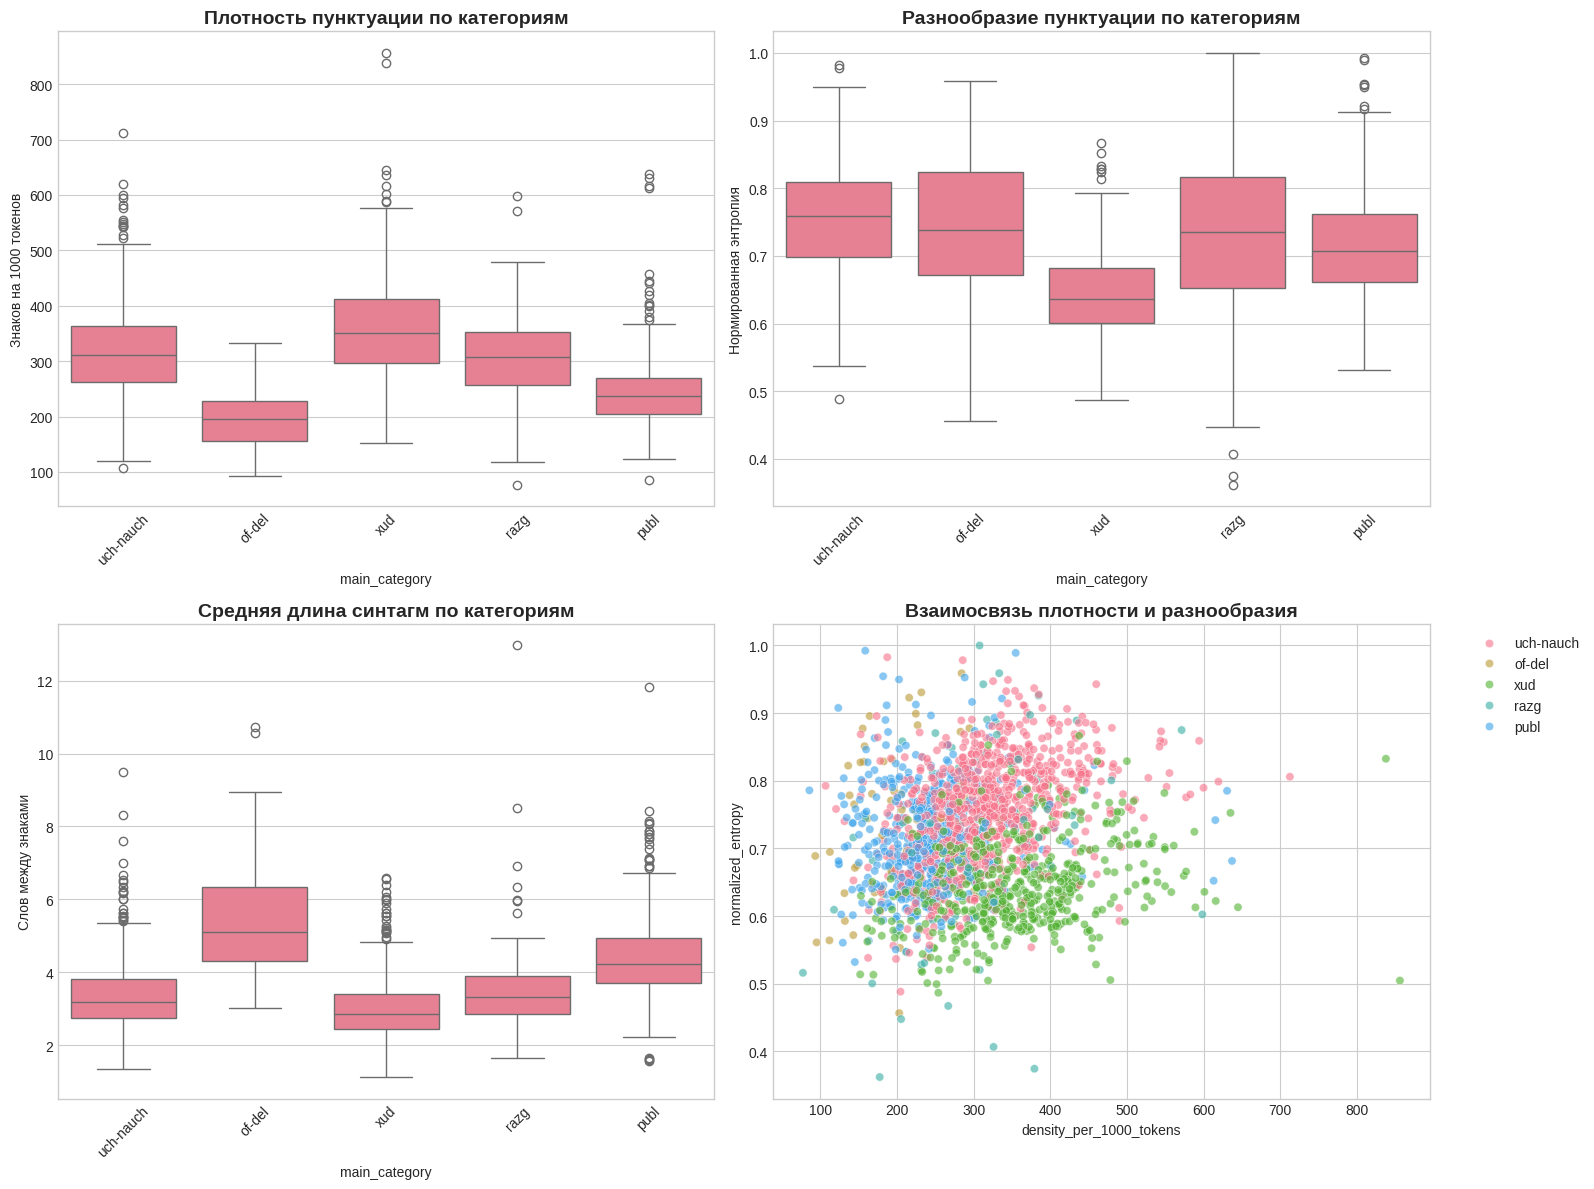


Корреляционная матрица метрик

                                density_per_1000_tokens  \
density_per_1000_tokens                           1.000   
density_per_1000_chars                            0.913   
entropy                                           0.307   
normalized_entropy                                0.111   
mean_words_between_all                           -0.892   
mean_chars_between_all                           -0.844   
between_dashes_mean_tokens                       -0.382   
between_dashes_mean_chars                        -0.351   
between_commas_mean_tokens                       -0.496   
between_commas_mean_chars                        -0.500   
between_semicolons_mean_tokens                   -0.153   
between_semicolons_mean_chars                    -0.137   

                                density_per_1000_chars  entropy  \
density_per_1000_tokens                          0.913    0.307   
density_per_1000_chars                           1.000    0.224   

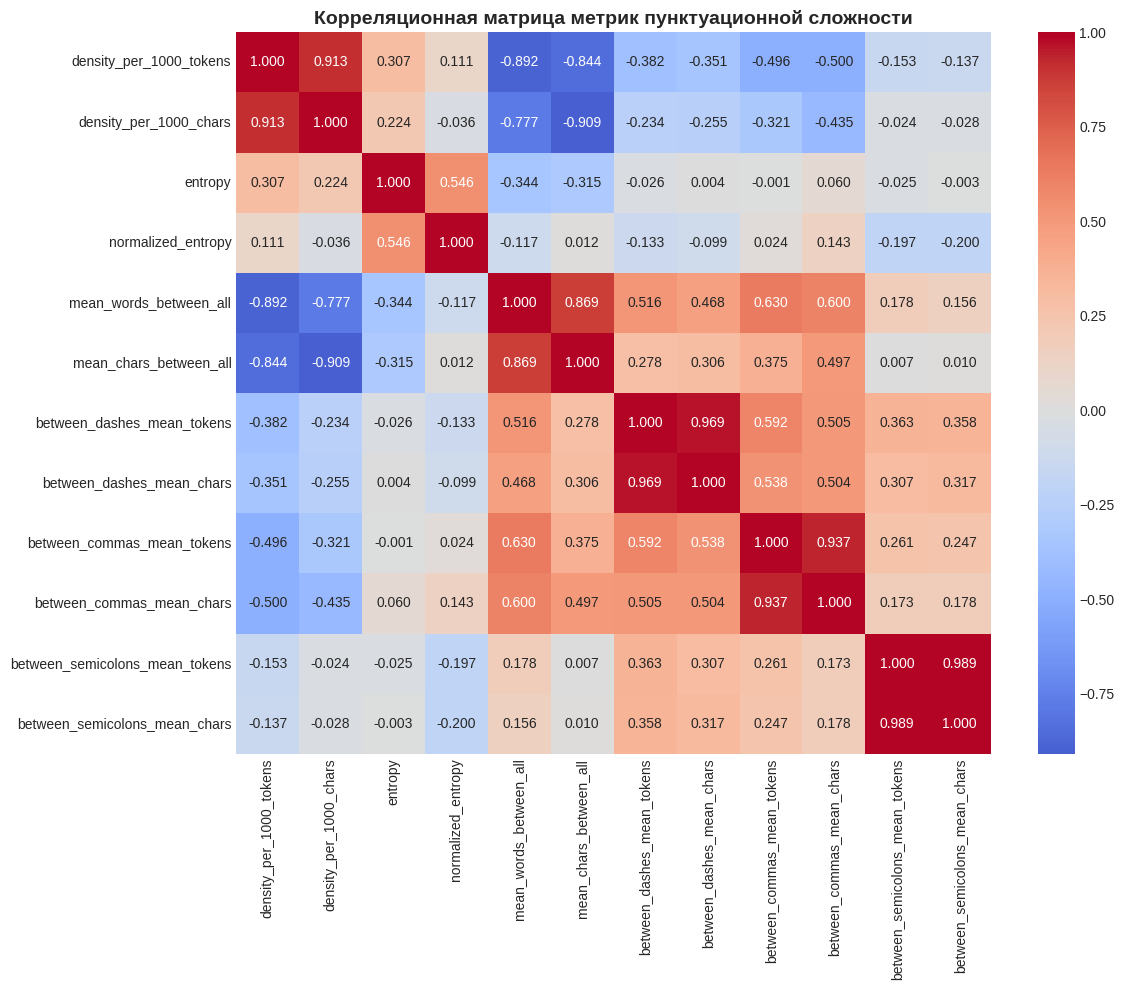


Анализ расстояний между парными знаками препинания

Доступные колонки с расстояниями:
  - between_commas_count
  - between_commas_max_chars
  - between_commas_max_tokens
  - between_commas_mean_chars
  - between_commas_mean_tokens
  - between_commas_min_chars
  - between_commas_min_tokens
  - between_dashes_count
  - between_dashes_max_chars
  - between_dashes_max_tokens
  - between_dashes_mean_chars
  - between_dashes_mean_tokens
  - between_dashes_min_chars
  - between_dashes_min_tokens
  - between_semicolons_count
  - between_semicolons_max_chars
  - between_semicolons_max_tokens
  - between_semicolons_mean_chars
  - between_semicolons_mean_tokens
  - between_semicolons_min_chars
  - between_semicolons_min_tokens
  - max_chars_between
  - max_words_between
  - mean_chars_between_all
  - mean_words_between_all
  - min_chars_between
  - min_words_between
  - std_chars_between
  - std_words_between



           Знак               Колонка (tokens)               Колонка (chars)  Тексто

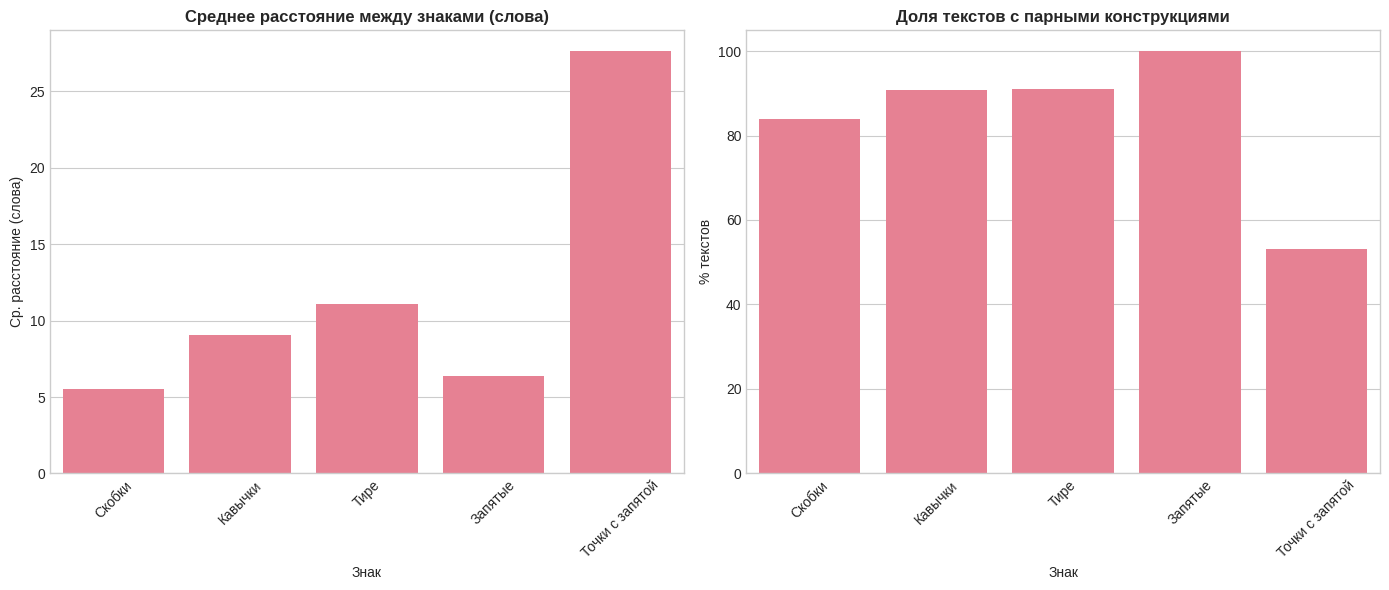


Результаты интерпретации сохранены: all_texts_with_interpretation обуч.csv


In [ ]:
if __name__ == "__main__":
    main()

***Комментарий в разговорном стиле**. Пунктуационные профили авторов (сначала убрала их из-за неинформативности, но сохранила картинку, а потом решила вставить отдельно). Мне всё ещё кажется, что график показывает почти то же, что анализ категорий, но оставлю для сравнения на всякий случай...*

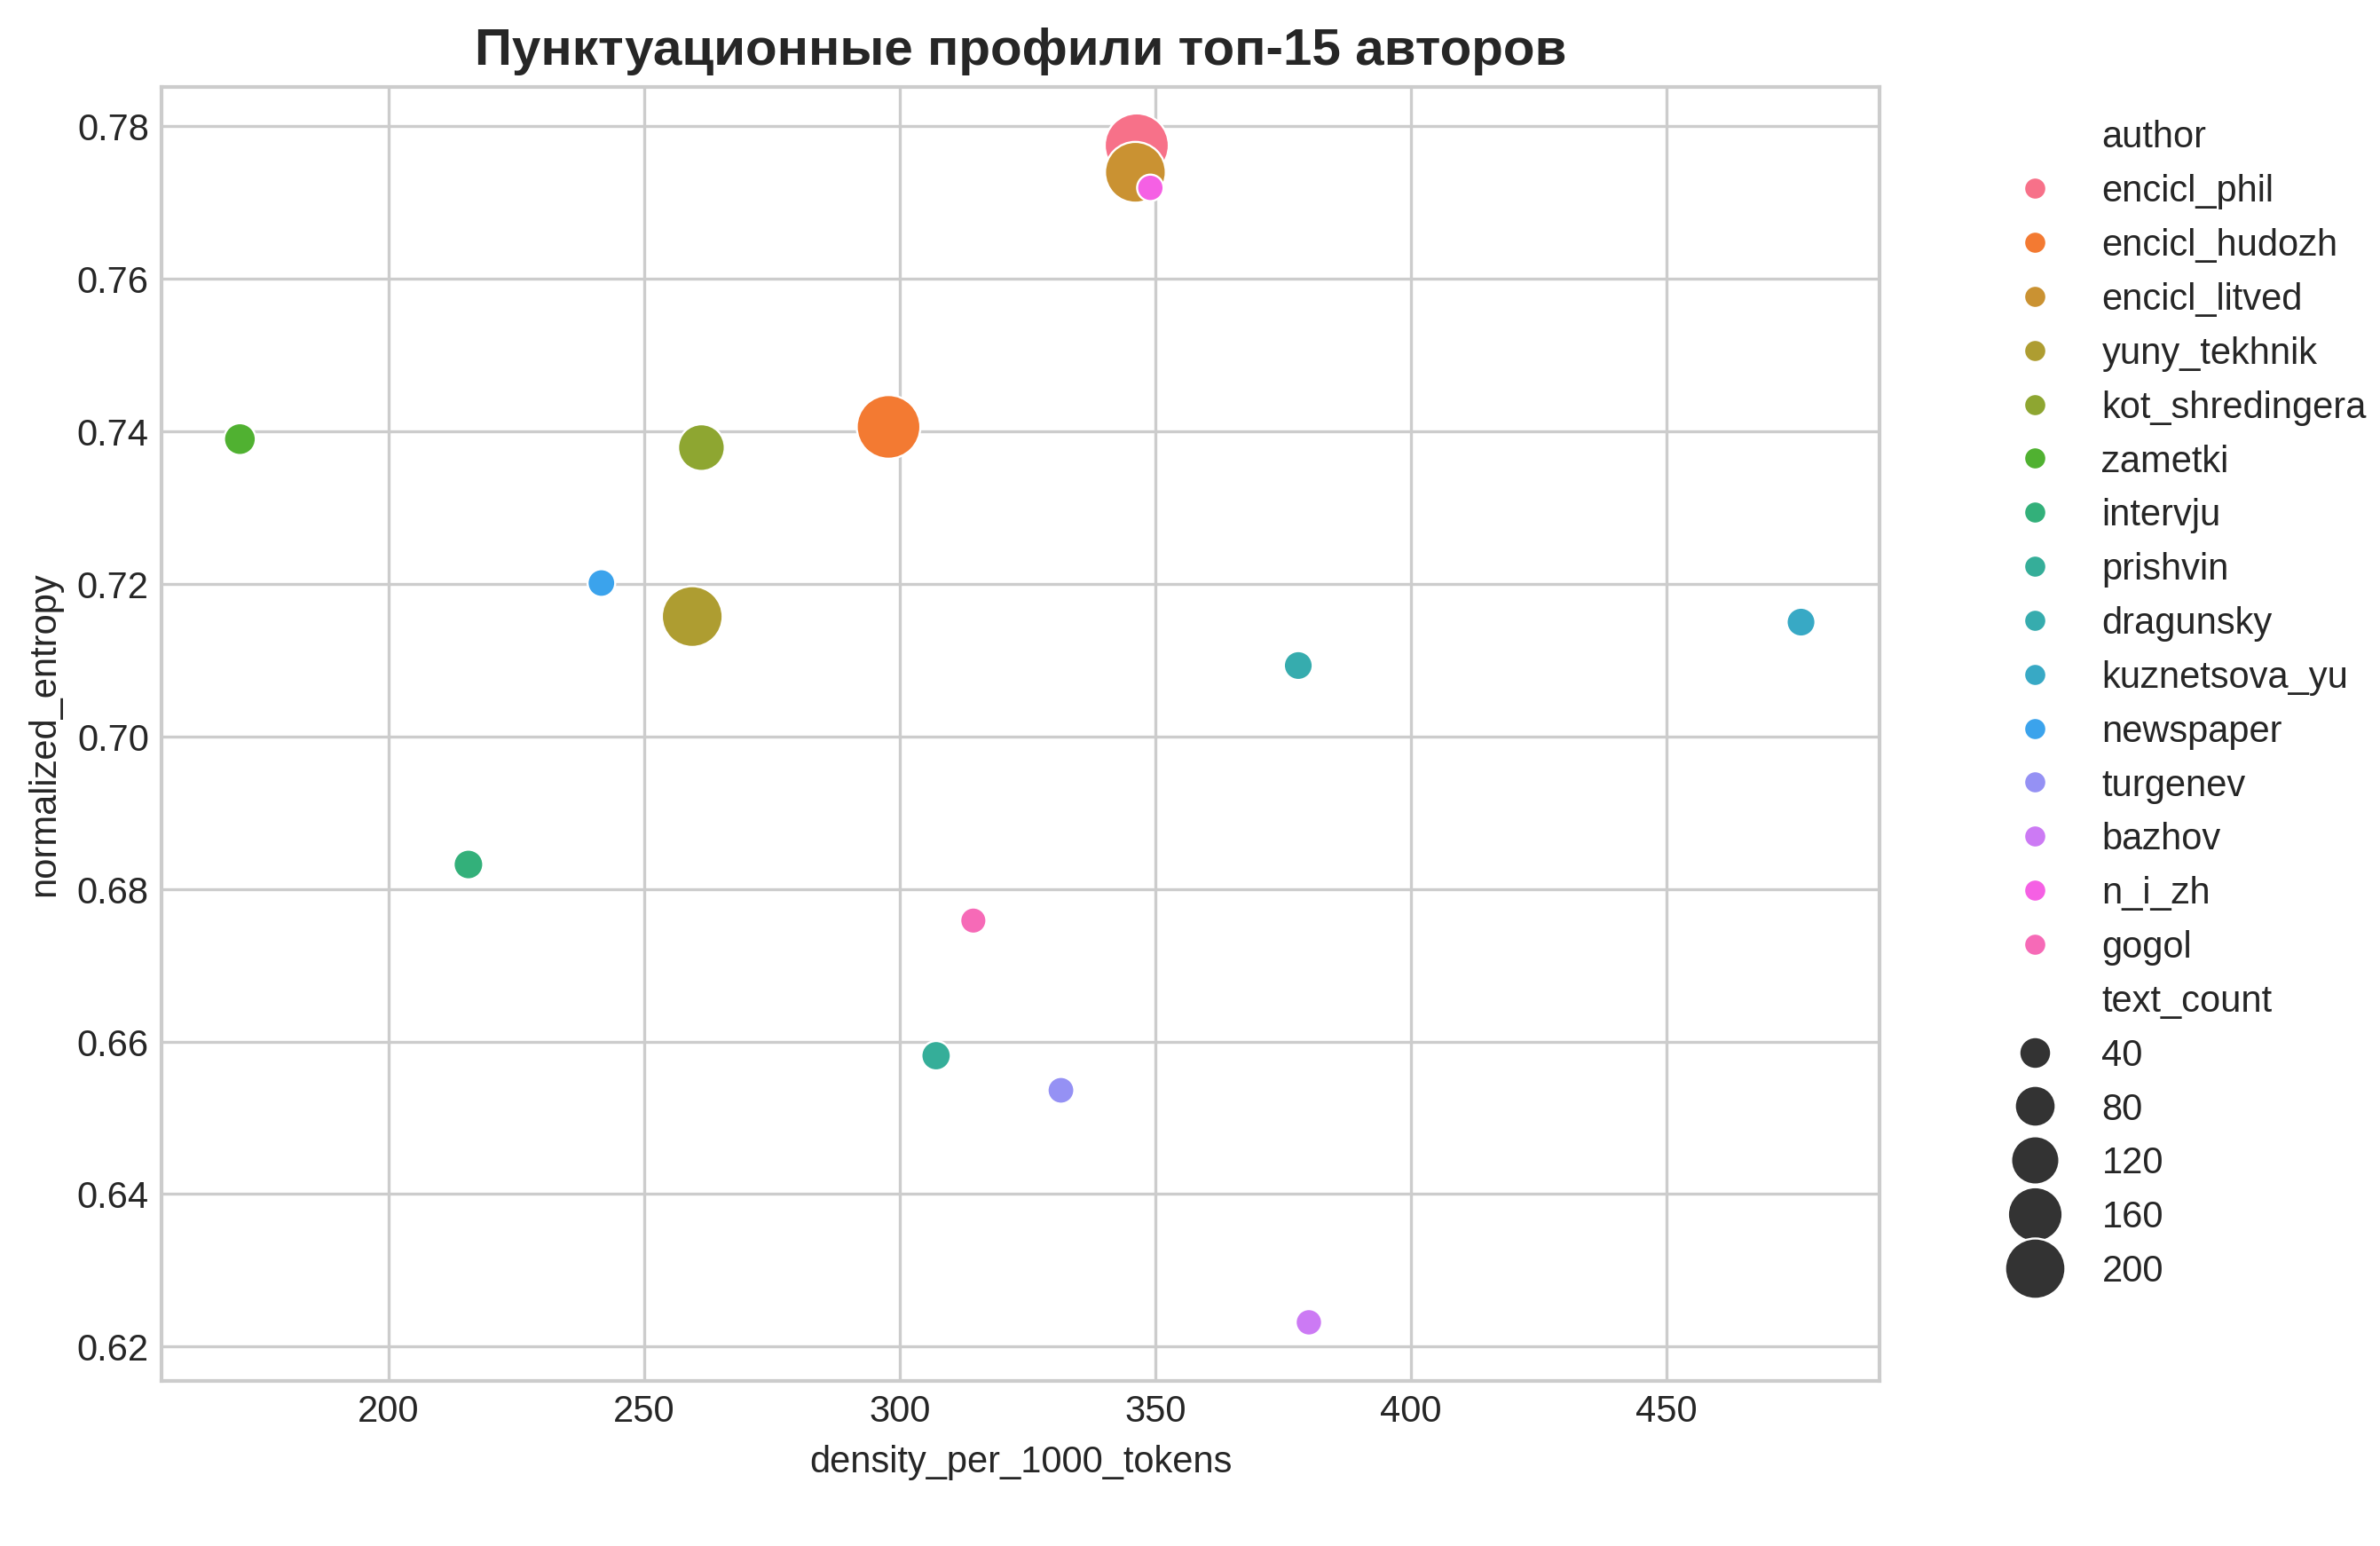

### Выводы по Обучающему корпусу

**Общая характеристика**

Средняя плотность пунктуации в Обучающем корпусе составляет 305,92 знака на 1000 токенов. Средняя нормированная энтропия — 0,713, средняя длина синтагматических отрезков — 3,59 слова.

**Уровни пунктуационной сложности**

Более 65% текстов (1294) характеризуются высоким уровнем пунктуационной сложности, 30,7% — средним, 3,5% — низким. Корпус состоит преимущественно из текстов с достаточно сложной пунктуацией, что нормально для учебных, художественных, официально-деловых и научных материалов.

**Методы расчёта**

Если считать показатели методом скользящего окна и дроблением текста на блоки, то разница получается меньше 2%. При этом средние значения различаются всего на 0,06%. Целесообразно сделать выбор в пользу расчёта по блокам, поскольку это позволит ускорить анализ в несколько раз.

Плотность и длины синтагматических отрезков будем рассчитывать прежде всего на 1000 токенов, но сохраним расчёт и на 1000 символов для контроля длины текста.

Энтропию будем рассматривать нормированную, посколько она умеренно коррелирует с ненормированной (0,546), а значит нужна для корректного сравнения текстов разной длины.

**Парные знаки препинания**

Запятые встречаются практически во всех текстах (99,9%), и между соседними знаками этого типа находится в среднем 6,38 слова. Точки с запятой есть всего в 53,1% текстов, но разделяют более крупные фрагменты (в среднем 27,6 слова).

Скобки содержатся в 84% текстов. Средняя количество слов внутри них равно 5,54 слова. При этом вставные конструкции с тире в два раза длиннее (11,06 слова) и присутствуют в 90,9% текстов.

Фрагменты, заключенные в кавычки, также значительно длиннее, чем вставные конструкции в скобках (9,05 слова). Они есть в 90,8% текстов.

**Анализ сфер функционирования (категорий)**

- *Официально-деловые (of-del)*. Самая низкая средняя плотность пунктуации (201,53 знака на 1000 токенов), в 1,5 раза ниже средней по корпусу. Тексты этой категории характеризуются самой большой длиной синтагм (5,41 слова), что объясняется стандартизированными канцелярскими оборотами с редкой постановкой знаков препинания. Кроме того, у официально-деловых текстов относительно высокая энтропия (0,74), то есть большое разнообразие пунктуации.

- *Публицистические (publ)*. Плотность пунктуации (243,4) ниже средней по корпусу, длина синтагм (4,42 слова) — выше средней, а разнообразие знаков препинания относительно небольшое. Это закономерно для публицистики и объясняется, в частности, стремлением создавать несложные для восприятия и однозначно интерпретируемые тексты.

- *Разговорные (razg)*. Плотность (304,27) и энтропия (0,72) близки к среднекорпусным. Длина синтагм (3,70) немного выше среднего, что может отражать специфику записи устной речи.

- *Учебно-научные (uch-nauch)*. Высокая плотность пунктуации (316,52) сочетается с короткими синтагмами (3,35 слова). Также именно в этой категории самая высокая энтропия (0,75), то есть самое высокое разнообразие пунктуации. Это характерно для учебного и научного стилей, поскольку пунктуация в них используется активно и помогает структурировать сложную мысль.

- *Художественный (xud)*. Тексты этой категории характеризуются максимальной плотностью пунктуации (356,92 слова на 1000 токенов) и минимальной длиной синтагм (3,01 слова). Кроме того, энтропия в художественных текстах значительно ниже, чем в других категориях (0,6): хотя авторы ставят знаки препинания очень часто, их набор ограничен.

**Корреляционный анализ**

Заметна сильная обратная связь между плотностью пунктуации и длиной синтагм (r = -0.84...-0.89), а также очень высокая корреляция между метриками парных знаков в словах и символах (r > 0.93 для всех типов).

Энтропия слабо коррелирует с плотностью (r = 0.11 для нормированной энтропии), что говорит о независимости этих характеристик (см., например, выводы по художественным текстам). При этом наблюдается умеренная отрицательная связь между длиной синтагм и энтропией (r = -0.34): чем длиннее отрезки, тем меньше разнообразие знаков.

**Итог**

Обучающий корпус можно считать сбалансированным по жанрам массивом текстов, пунктуационные характеристики которых варьируются в зависимости от функционального стиля. Наиболее отчётливо противопоставлены официально-деловой и художественный стили: первый тяготеет к редкой, но разнообразной пунктуации с длинными синтагматическими отрезками, второй — к частой, но относительно однообразной пунктуации с короткими синтагмами. Учебно-научный стиль демонстрирует максимальное разнообразие знаков, что отражает его ориентацию на точность и структурированность изложения.



## Корпус «От двух до пятнадцати»

### Расчёты

In [ ]:
class PunctuationComplexityAnalyzerKids:
    def __init__(self):
        self.reset_for_new_file()

    def reset_for_new_file(self):
        self.text = ""
        self.tokens = []
        self.punctuation_marks = []
        self.punctuation_by_type = Counter()
        self.sentences = []
        self.filename = ""
        self.filepath = ""
        self._punct_positions_cache = None
        self._word_positions_cache = None
        self._sentence_boundaries_cache = None

    def extract_text_from_xml(self, file_path: str) -> str:
        try:
            tree = ET.parse(file_path)
            root = tree.getroot()

            text_parts = []
            for elem in root.iter():
                if elem.text and elem.tag not in ['meta', 'head', 'span']:
                    if elem.get('class') != 'note':
                        text_parts.append(elem.text)
                if elem.tail and elem.tag not in ['meta', 'head', 'span']:
                    if elem.get('class') != 'note':
                        text_parts.append(elem.tail)

            self.text = ' '.join(text_parts)
            self.text = re.sub(r'\s+', ' ', self.text).strip()
            return self.text

        except Exception as e:
            print(f"Ошибка при чтении XML {file_path}: {e}")
            return ""

    def tokenize(self) -> List[str]:
        words_text = re.sub(r'[^\w\s]', ' ', self.text)
        self.tokens = [word for word in words_text.split() if word.strip()]
        return self.tokens

    def extract_punctuation(self) -> List[str]:
        punct_pattern = r'[.,!?;:\-–—"«»\'\(\)\[\]{}…]|\.{3,}'
        self.punctuation_marks = []

        for match in re.finditer(punct_pattern, self.text):
            punct = match.group()
            if punct.startswith('...'):
                punct = '…'
            self.punctuation_marks.append(punct)

        self.punctuation_by_type = Counter(self.punctuation_marks)
        return self.punctuation_marks

    def split_into_sentences(self) -> List[str]:
        sentence_endings = r'(?<=[.!?…])\s+(?=[А-ЯA-Z])'
        self.sentences = re.split(sentence_endings, self.text)
        self.sentences = [s.strip() for s in self.sentences if s.strip()]

        self._sentence_boundaries_cache = None
        return self.sentences

    def get_category_from_path(self, file_path: str, base_dir: str) -> str:
        """Определение категории по пути к файлу (название подпапки)"""
        try:
            rel_path = os.path.relpath(file_path, base_dir)
            parts = Path(rel_path).parts

            valid_categories = ['1-2', '3-4', '5-7', '8-9', '10-11']

            for part in parts:
                if part in valid_categories:
                    return part

            return "unknown"
        except:
            return "unknown"

    def get_absolute_metrics(self, base_dir: str) -> Dict:
        char_count = len(self.text)
        token_count = len(self.tokens)
        punct_count = len(self.punctuation_marks)

        unique_punct = set()
        for p in self.punctuation_marks:
            if p in ['—', '–', '-', '--']:
                unique_punct.add('—')
            elif p in ['«', '»', '"', "'"]:
                unique_punct.add('«»')
            elif p == '…':
                unique_punct.add('…')
            else:
                unique_punct.add(p)

        return {
            'filename': self.filename,
            'category': self.get_category_from_path(self.filepath, base_dir),
            'total_characters': char_count,
            'total_tokens': token_count,
            'total_punctuation': punct_count,
            'unique_punctuation_count': len(unique_punct),
            'unique_punctuation_list': sorted(list(unique_punct))
        }

    def calculate_punctuation_density(self) -> Dict:
        char_count = len(self.text)
        token_count = len(self.tokens)
        punct_count = len(self.punctuation_marks)

        density_per_1000_tokens = (punct_count / token_count) * 1000 if token_count > 0 else 0
        density_per_1000_chars = (punct_count / char_count) * 1000 if char_count > 0 else 0

        all_punct_positions = [pos for pos, _ in self._get_punct_positions()]

        blocks_density_chars = []
        for i in range(0, char_count, 1000):
            end_char_idx = min(i + 1000, char_count)
            if end_char_idx - i < 200:
                continue

            punct_in_block = sum(1 for pos in all_punct_positions if i <= pos < end_char_idx)
            block_char_count = end_char_idx - i
            density = (punct_in_block / block_char_count) * 1000
            blocks_density_chars.append(density)

        blocks_density_tokens = []
        if token_count >= 1000:
            token_positions = self._get_word_positions()

            for i in range(0, len(token_positions), 1000):
                end_idx = min(i + 1000, len(token_positions))
                if end_idx - i < 100:
                    continue

                start_char = token_positions[i]
                end_char = token_positions[end_idx - 1] + 50

                punct_in_block = sum(1 for pos in all_punct_positions if start_char <= pos < end_char)
                block_token_count = end_idx - i
                density = (punct_in_block / block_token_count) * 1000
                blocks_density_tokens.append(density)

        return {
            'density_per_1000_tokens': density_per_1000_tokens,
            'density_per_1000_chars': density_per_1000_chars,
            'blocks_tokens_mean': np.mean(blocks_density_tokens) if blocks_density_tokens else density_per_1000_tokens,
            'blocks_tokens_std': np.std(blocks_density_tokens) if blocks_density_tokens else 0,
            'blocks_tokens_min': min(blocks_density_tokens) if blocks_density_tokens else 0,
            'blocks_tokens_max': max(blocks_density_tokens) if blocks_density_tokens else 0,
            'blocks_chars_mean': np.mean(blocks_density_chars) if blocks_density_chars else density_per_1000_chars,
            'blocks_chars_std': np.std(blocks_density_chars) if blocks_density_chars else 0,
            'blocks_chars_min': min(blocks_density_chars) if blocks_density_chars else 0,
            'blocks_chars_max': max(blocks_density_chars) if blocks_density_chars else 0
        }

    def calculate_punctuation_diversity(self) -> Dict:
        if not self.punctuation_by_type:
            return {'entropy': 0, 'normalized_entropy': 0}

        total = sum(self.punctuation_by_type.values())

        entropy = 0
        for count in self.punctuation_by_type.values():
            p = count / total
            entropy -= p * math.log2(p)

        max_entropy = math.log2(len(self.punctuation_by_type))
        normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0

        return {
            'entropy': entropy,
            'normalized_entropy': normalized_entropy,
            'unique_punct_types': len(self.punctuation_by_type)
        }

    def _get_punct_positions(self):
        if self._punct_positions_cache is None:
            self._punct_positions_cache = []
            for match in re.finditer(r'[.,!?;:\-–—"«»\'\(\)\[\]{}…]|\.{3,}', self.text):
                punct = match.group()
                if punct.startswith('...'):
                    punct = '…'
                self._punct_positions_cache.append((match.start(), punct))
        return self._punct_positions_cache

    def _get_word_positions(self):
        if self._word_positions_cache is None:
            self._word_positions_cache = []
            for match in re.finditer(r'\b\w+\b', self.text):
                self._word_positions_cache.append(match.start())
        return self._word_positions_cache

    def _get_sentence_boundaries(self):
        if self._sentence_boundaries_cache is None:
            self._sentence_boundaries_cache = []
            current_pos = 0
            for sentence in self.sentences:
                sent_start = self.text.find(sentence, current_pos)
                if sent_start != -1:
                    sent_end = sent_start + len(sentence)
                    self._sentence_boundaries_cache.append((sent_start, sent_end))
                    current_pos = sent_end
        return self._sentence_boundaries_cache

    def calculate_mean_syntagmatic_length(self) -> Dict:
        punct_positions = self._get_punct_positions()
        punct_positions_only = [pos for pos, _ in punct_positions]

        if len(punct_positions_only) < 2:
            return {
                'mean_words_between_all': 0, 'mean_chars_between_all': 0,
                'min_words_between': 0, 'max_words_between': 0,
                'min_chars_between': 0, 'max_chars_between': 0,
                'std_words_between': 0, 'std_chars_between': 0
            }

        word_positions = self._get_word_positions()

        distances_words = []
        distances_chars = []

        max_samples = 500

        if len(punct_positions_only) - 1 > max_samples:
            step = (len(punct_positions_only) - 1) // max_samples
            indices = list(range(0, len(punct_positions_only) - 1, step))[:max_samples]
        else:
            indices = range(len(punct_positions_only) - 1)

        for i in indices:
            char_distance = punct_positions_only[i+1] - punct_positions_only[i] - 1
            if char_distance >= 0:
                distances_chars.append(char_distance)

                words_between = 0
                for word_pos in word_positions:
                    if punct_positions_only[i] < word_pos < punct_positions_only[i+1]:
                        words_between += 1
                distances_words.append(words_between)

        return {
            'mean_words_between_all': np.mean(distances_words) if distances_words else 0,
            'mean_chars_between_all': np.mean(distances_chars) if distances_chars else 0,
            'min_words_between': min(distances_words) if distances_words else 0,
            'max_words_between': max(distances_words) if distances_words else 0,
            'min_chars_between': min(distances_chars) if distances_chars else 0,
            'max_chars_between': max(distances_chars) if distances_chars else 0,
            'std_words_between': np.std(distances_words) if distances_words else 0,
            'std_chars_between': np.std(distances_chars) if distances_chars else 0
        }

    def calculate_sentence_based_metrics(self) -> Dict:
        if not self.sentences:
            self.split_into_sentences()

        words_per_sentence = []
        chars_per_sentence = []

        for sentence in self.sentences:
            words = len(re.findall(r'\b\w+\b', sentence))
            if words > 0:
                words_per_sentence.append(words)
                chars_per_sentence.append(len(sentence))

        return {
            'sentence_count': len(self.sentences),
            'mean_words_per_sentence': np.mean(words_per_sentence) if words_per_sentence else 0,
            'std_words_per_sentence': np.std(words_per_sentence) if words_per_sentence else 0,
            'min_words_per_sentence': min(words_per_sentence) if words_per_sentence else 0,
            'max_words_per_sentence': max(words_per_sentence) if words_per_sentence else 0,
            'mean_chars_per_sentence': np.mean(chars_per_sentence) if chars_per_sentence else 0
        }

    def calculate_paired_distances(self) -> Dict:
        """Расчет расстояний для парных знаков (скобки и кавычки)"""
        result = {
            'quotes_mean_tokens': 0, 'quotes_min_tokens': 0, 'quotes_max_tokens': 0,
            'quotes_mean_chars': 0, 'quotes_min_chars': 0, 'quotes_max_chars': 0,
            'quotes_count': 0,
            'parentheses_mean_tokens': 0, 'parentheses_min_tokens': 0, 'parentheses_max_tokens': 0,
            'parentheses_mean_chars': 0, 'parentheses_min_chars': 0, 'parentheses_max_chars': 0,
            'parentheses_count': 0
        }

        quote_pattern = r'[«"]([^»"]+)[»"]'
        quote_lengths_tokens = []
        quote_lengths_chars = []

        for match in re.finditer(quote_pattern, self.text):
            quote_text = match.group(1)
            quote_lengths_chars.append(len(quote_text))
            tokens = len(re.findall(r'\b\w+\b', quote_text))
            if tokens > 0:
                quote_lengths_tokens.append(tokens)

        if quote_lengths_tokens:
            result['quotes_mean_tokens'] = np.mean(quote_lengths_tokens)
            result['quotes_min_tokens'] = min(quote_lengths_tokens)
            result['quotes_max_tokens'] = max(quote_lengths_tokens)
            result['quotes_mean_chars'] = np.mean(quote_lengths_chars)
            result['quotes_min_chars'] = min(quote_lengths_chars)
            result['quotes_max_chars'] = max(quote_lengths_chars)
            result['quotes_count'] = len(quote_lengths_tokens)

        paren_pattern = r'\(([^)]+)\)'
        paren_lengths_tokens = []
        paren_lengths_chars = []

        for match in re.finditer(paren_pattern, self.text):
            paren_text = match.group(1)
            paren_lengths_chars.append(len(paren_text))
            tokens = len(re.findall(r'\b\w+\b', paren_text))
            if tokens > 0:
                paren_lengths_tokens.append(tokens)

        if paren_lengths_tokens:
            result['parentheses_mean_tokens'] = np.mean(paren_lengths_tokens)
            result['parentheses_min_tokens'] = min(paren_lengths_tokens)
            result['parentheses_max_tokens'] = max(paren_lengths_tokens)
            result['parentheses_mean_chars'] = np.mean(paren_lengths_chars)
            result['parentheses_min_chars'] = min(paren_lengths_chars)
            result['parentheses_max_chars'] = max(paren_lengths_chars)
            result['parentheses_count'] = len(paren_lengths_tokens)

        return result

    def calculate_specific_distances(self) -> Dict:
        result = {
            'between_commas_mean_tokens': 0, 'between_commas_min_tokens': 0, 'between_commas_max_tokens': 0,
            'between_commas_mean_chars': 0, 'between_commas_min_chars': 0, 'between_commas_max_chars': 0,
            'between_commas_count': 0,

            'between_semicolons_mean_tokens': 0, 'between_semicolons_min_tokens': 0, 'between_semicolons_max_tokens': 0,
            'between_semicolons_mean_chars': 0, 'between_semicolons_min_chars': 0, 'between_semicolons_max_chars': 0,
            'between_semicolons_count': 0,

            'between_dashes_mean_tokens': 0, 'between_dashes_min_tokens': 0, 'between_dashes_max_tokens': 0,
            'between_dashes_mean_chars': 0, 'between_dashes_min_chars': 0, 'between_dashes_max_chars': 0,
            'between_dashes_count': 0
        }

        punct_positions = self._get_punct_positions()

        if len(punct_positions) < 5:
            return result

        word_positions = self._get_word_positions()

        # Расстояния между запятыми внутри предложений
        self._calculate_punct_distances_in_sentences_optimized(',', 'commas', result, punct_positions, word_positions)

        # Расстояния между точками с запятой внутри предложений
        self._calculate_punct_distances_in_sentences_optimized(';', 'semicolons', result, punct_positions, word_positions)

        # Расстояния между тире внутри предложений
        dash_chars = ['—', '–', ' - ', '--']
        self._calculate_punct_distances_in_sentences_optimized(dash_chars, 'dashes', result, punct_positions, word_positions,
                                                               require_pair=True)

        return result

    def _calculate_punct_distances_in_sentences_optimized(self, punct_chars, result_key, result, punct_positions,
                                                          word_positions, require_pair=False):
        if not isinstance(punct_chars, list):
            punct_chars = [punct_chars]

        sentence_boundaries = self._get_sentence_boundaries()

        if not sentence_boundaries:
            return

        punct_by_sentence = [[] for _ in range(len(sentence_boundaries))]

        for pos, punct in punct_positions:
            if punct not in punct_chars:
                continue

            for i, (sent_start, sent_end) in enumerate(sentence_boundaries):
                if sent_start <= pos < sent_end:
                    punct_by_sentence[i].append(pos)
                    break

        distances_tokens = []
        distances_chars = []

        for sent_idx, (sent_start, sent_end) in enumerate(sentence_boundaries):
            positions = punct_by_sentence[sent_idx]
            if not positions:
                continue

            positions.sort()

            if len(positions) < 2:
                if len(positions) == 1 and not require_pair:
                    pos = positions[0]

                    if pos > sent_start:
                        char_dist = pos - sent_start
                        if char_dist > 0:
                            distances_chars.append(char_dist)
                            words_before = sum(1 for wp in word_positions if sent_start < wp < pos)
                            if words_before > 0:
                                distances_tokens.append(words_before)

                    if pos < sent_end - 1:
                        char_dist = sent_end - pos - 1
                        if char_dist > 0:
                            distances_chars.append(char_dist)
                            words_after = sum(1 for wp in word_positions if pos < wp < sent_end)
                            if words_after > 0:
                                distances_tokens.append(words_after)
            else:
                for i in range(len(positions) - 1):
                    char_dist = positions[i+1] - positions[i] - 1
                    if char_dist > 0:
                        distances_chars.append(char_dist)
                        words_between = sum(1 for wp in word_positions if positions[i] < wp < positions[i+1])
                        if words_between > 0:
                            distances_tokens.append(words_between)

        if distances_tokens:
            result[f'between_{result_key}_mean_tokens'] = np.mean(distances_tokens)
            result[f'between_{result_key}_min_tokens'] = min(distances_tokens)
            result[f'between_{result_key}_max_tokens'] = max(distances_tokens)
            result[f'between_{result_key}_mean_chars'] = np.mean(distances_chars) if distances_chars else 0
            result[f'between_{result_key}_min_chars'] = min(distances_chars) if distances_chars else 0
            result[f'between_{result_key}_max_chars'] = max(distances_chars) if distances_chars else 0
            result[f'between_{result_key}_count'] = len(distances_tokens)

    def analyze_file(self, file_path: str, filename: str, base_dir: str) -> Dict:
        self.reset_for_new_file()
        self.filename = filename
        self.filepath = file_path

        self.extract_text_from_xml(file_path)
        if not self.text:
            return None

        self.tokenize()
        self.extract_punctuation()
        self.split_into_sentences()

        results = {
            **self.get_absolute_metrics(base_dir),
            **self.calculate_punctuation_density(),
            **self.calculate_punctuation_diversity(),
            **self.calculate_mean_syntagmatic_length(),
            **self.calculate_sentence_based_metrics(),
            **self.calculate_paired_distances(),
            **self.calculate_specific_distances()
        }

        return results

In [ ]:
def extract_archive(zip_path: str, extract_path: str = "extracted_kids_corpus"):
    print(f"Извлечение архива {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Архив извлечен в {extract_path}")
    return extract_path


def find_xml_files(root_dir: str) -> List[Dict]:
    xml_files = []

    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file.endswith('.xml'):
                full_path = os.path.join(root, file)
                xml_files.append({
                    'path': full_path,
                    'filename': file
                })

    return xml_files


def process_batch(file_infos, base_dir):
    analyzer = PunctuationComplexityAnalyzerKids()
    batch_results = []

    for file_info in file_infos:
        try:
            result = analyzer.analyze_file(file_info['path'], file_info['filename'], base_dir)
            if result:
                batch_results.append(result)
        except Exception as e:
            print(f"\nОшибка при обработке {file_info['path']}: {e}")

    return batch_results


def process_corpus_kids(zip_path: str = "kids-corpus.zip", extract_to: str = "extracted_kids_corpus",
                        max_workers=None, batch_size=20):

    if not os.path.exists(zip_path):
        print(f"Файл {zip_path} не найден!")
        print(f"Текущая папка: {os.getcwd()}")
        return None

    if not os.path.exists(extract_to):
        extract_path = extract_archive(zip_path, extract_to)
    else:
        extract_path = extract_to
        print(f"Используем существующую папку {extract_path}")

    xml_files = find_xml_files(extract_path)
    print(f"Найдено {len(xml_files)} XML-файлов")

    if max_workers is None:
        max_workers = max(1, multiprocessing.cpu_count() - 1)

    batches = []
    for i in range(0, len(xml_files), batch_size):
        batches.append(xml_files[i:i + batch_size])

    all_results = []

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        future_to_batch = {executor.submit(process_batch, batch, extract_path): i
                          for i, batch in enumerate(batches)}

        with tqdm(total=len(xml_files), desc="Анализ", unit="файл") as pbar:
            for future in as_completed(future_to_batch):
                batch_results = future.result()
                all_results.extend(batch_results)
                pbar.update(len(batch_results))

    print(f"\nУспешно обработано {len(all_results)} файлов")

    df = pd.DataFrame(all_results)
    return df

In [ ]:
def run_analysis_kids():
    start_time = time.time()

    df = process_corpus_kids(
        zip_path="kids-corpus.zip",
        max_workers=4,
        batch_size=20
    )

    if df is None or df.empty:
        print("Не удалось обработать файлы!")
        return None

    elapsed_time = time.time() - start_time
    hours = int(elapsed_time // 3600)
    minutes = int((elapsed_time % 3600) // 60)
    seconds = int(elapsed_time % 60)
    print(f"\nОбщее время обработки: {hours} ч {minutes} мин {seconds} сек")

    return df

In [ ]:
def show_general_info(df):
    """Общая информация о корпусе"""
    print(f"\nВсего обработано текстов: {len(df)}")

    if 'category' in df.columns:
        categories = sorted(df['category'].unique())
        print(f"Категории: {', '.join(categories)}")

    print("\nПервые 20 текстов:")

    display_cols = [
        'filename', 'category', 'total_tokens', 'total_punctuation',
        'density_per_1000_tokens', 'entropy',
        'mean_words_between_all', 'sentence_count'
    ]

    available_cols = [col for col in display_cols if col in df.columns]
    display_df = df[available_cols].copy().head(20)

    col_names = {
        'filename': 'Файл',
        'category': 'Категория',
        'total_tokens': 'Слов',
        'total_punctuation': 'Знаков',
        'density_per_1000_tokens': 'Плотность на 1000 токенов',
        'entropy': 'Энтропия',
        'mean_words_between_all': 'Слов между любыми знаками',
        'sentence_count': 'Предложений'
    }

    display_df.columns = [col_names.get(col, col) for col in available_cols]

    for col in display_df.select_dtypes(include=[np.number]).columns:
        display_df[col] = display_df[col].round(2)

    print(display_df.to_string(index=False))
    print()

In [ ]:
def show_category_stats(df):
    """Статистика по категориям"""
    if 'category' not in df.columns:
        print("Нет информации о категориях")
        return

    print("\nСтатистика по категориям:")

    agg_metrics = {
        'filename': 'count',
        'total_tokens': ['mean', 'std', 'min', 'max'],
        'density_per_1000_tokens': ['mean', 'std'],
        'entropy': ['mean', 'std'],
        'normalized_entropy': ['mean', 'std'],
        'mean_words_between_all': ['mean', 'std'],
        'sentence_count': ['mean', 'std']
    }

    available_metrics = {k: v for k, v in agg_metrics.items() if k in df.columns}

    if not available_metrics:
        print("Нет доступных метрик для агрегации")
        return

    category_order = ['1-2', '3-4', '5-7', '8-9', '10-11', 'unknown']
    df['category'] = pd.Categorical(df['category'], categories=category_order, ordered=True)

    category_stats = df.groupby('category', observed=True).agg(available_metrics).round(2)

    category_stats.columns = ['_'.join(col).strip() for col in category_stats.columns.values]
    if 'filename_count' in category_stats.columns:
        category_stats = category_stats.rename(columns={'filename_count': 'текстов'})

    print(category_stats.to_string())
    print()

In [ ]:
def show_detailed_category_stats(df):
    if 'category' not in df.columns:
        print("Нет информации о категориях")
        return

    print("\nДетальная статистика по категориям")

    category_order = ['1-2', '3-4', '5-7', '8-9', '10-11', 'unknown']

    for category in category_order:
        if category not in df['category'].values:
            if category != 'unknown':
                print(f"\n{category} (нет текстов)")
            continue

        cat_df = df[df['category'] == category]

        print(f"\n{category} (всего текстов: {len(cat_df)})")

        if 'total_tokens' in cat_df.columns:
            print(f"\n  токенов:")
            print(f"    среднее: {cat_df['total_tokens'].mean():.2f}")
            print(f"    std: {cat_df['total_tokens'].std():.2f}")
            print(f"    мин.: {cat_df['total_tokens'].min():.2f}")
            print(f"    макс.: {cat_df['total_tokens'].max():.2f}")

        if 'density_per_1000_tokens' in cat_df.columns:
            print(f"\n  плотность на 1000 токенов:")
            print(f"    среднее: {cat_df['density_per_1000_tokens'].mean():.2f}")
            print(f"    std: {cat_df['density_per_1000_tokens'].std():.2f}")
            print(f"    мин.: {cat_df['density_per_1000_tokens'].min():.2f}")
            print(f"    макс.: {cat_df['density_per_1000_tokens'].max():.2f}")

        if 'entropy' in cat_df.columns:
            print(f"\n  энтропия:")
            print(f"    среднее: {cat_df['entropy'].mean():.2f}")
            print(f"    std: {cat_df['entropy'].std():.2f}")
            print(f"    мин.: {cat_df['entropy'].min():.2f}")
            print(f"    макс.: {cat_df['entropy'].max():.2f}")

        if 'normalized_entropy' in cat_df.columns:
            print(f"\n  нормированная энтропия:")
            print(f"    среднее: {cat_df['normalized_entropy'].mean():.3f}")

        if 'mean_words_between_all' in cat_df.columns:
            print(f"\n  слов между знаками:")
            print(f"    среднее: {cat_df['mean_words_between_all'].mean():.2f}")

        if 'total_tokens' in cat_df.columns:
            print(f"\n  Топ-5 самых длинных текстов в категории {category}:")
            longest = cat_df.nlargest(5, 'total_tokens')[['filename', 'total_tokens']]
            for idx, row in longest.iterrows():
                print(f"    - {row['filename']}: {row['total_tokens']} слов")
    print()

In [ ]:
def show_summary_stats(df):
    print("\nСводная статистика по всем метрикам")

    numeric_cols = [
        'total_characters', 'total_tokens', 'total_punctuation',
        'density_per_1000_tokens', 'density_per_1000_chars',
        'entropy', 'normalized_entropy',
        'mean_words_between_all', 'mean_chars_between_all',
        'sentence_count', 'mean_words_per_sentence'
    ]

    available_cols = [col for col in numeric_cols if col in df.columns]

    if not available_cols:
        print("Нет числовых метрик для отображения")
        return

    summary = df[available_cols].describe().round(2)

    col_names = {
        'total_characters': 'символов',
        'total_tokens': 'слов',
        'total_punctuation': 'знаков',
        'density_per_1000_tokens': 'плотн_токены',
        'density_per_1000_chars': 'плотн_символы',
        'entropy': 'энтропия',
        'normalized_entropy': 'норм_энтропия',
        'mean_words_between_all': 'слов_между_знаками',
        'mean_chars_between_all': 'симв_между_знаками',
        'sentence_count': 'кол_предл',
        'mean_words_per_sentence': 'ср_длина_предл'
    }

    summary.columns = [col_names.get(col, col) for col in available_cols]
    print(summary.to_string())
    print()

In [ ]:
def save_all_results(df, base_name="kids_corpus"):
    df.to_csv(f"{base_name}_detailed_results.csv", index=False, encoding='utf-8-sig')
    print(f"Полные результаты сохранены: {base_name}_detailed_results.csv")

    basic_cols = [
        'filename', 'category', 'total_tokens', 'total_punctuation',
        'density_per_1000_tokens', 'entropy', 'normalized_entropy',
        'mean_words_between_all', 'sentence_count', 'mean_words_per_sentence'
    ]

    available_basic = [col for col in basic_cols if col in df.columns]
    if available_basic:
        df[available_basic].to_csv(f"{base_name}_basic_metrics.csv", index=False, encoding='utf-8-sig')
        print(f"Базовые метрики сохранены: {base_name}_basic_metrics.csv")

    if 'category' in df.columns:
        category_order = ['1-2', '3-4', '5-7', '8-9', '10-11', 'unknown']
        df['category'] = pd.Categorical(df['category'], categories=category_order, ordered=True)

        category_stats = df.groupby('category', observed=True).agg({
            'total_tokens': ['count', 'mean', 'std', 'min', 'max'],
            'density_per_1000_tokens': ['mean', 'std'],
            'entropy': ['mean', 'std'],
            'normalized_entropy': ['mean', 'std'],
            'mean_words_between_all': ['mean', 'std']
        }).round(2)
        category_stats.to_csv(f"{base_name}_category_statistics.csv", encoding='utf-8-sig')
        print(f"Статистика по категориям сохранена: {base_name}_category_statistics.csv")

In [ ]:
df = run_analysis_kids()

Используем существующую папку extracted_kids_corpus
Найдено 75 XML-файлов


Анализ: 100%|██████████| 75/75 [50:01<00:00, 40.02s/файл]


Успешно обработано 75 файлов

Общее время обработки: 0 ч 50 мин 1 сек


In [ ]:
show_general_info(df)


Всего обработано текстов: 75
Категории: 1-2, 10-11, 3-4, 5-7, 8-9

Первые 20 текстов:
  Файл Категория   Слов  Знаков  Плотность на 1000 токенов  Энтропия  Слов между любыми знаками  Предложений
 9.xml       1-2  71645   22716                     317.06      2.68                       3.30         6869
13.xml       1-2  22573    8107                     359.15      2.53                       2.90         1306
18.xml       1-2  63165   18280                     289.40      2.29                       3.25         3559
 5.xml       1-2  31325    9404                     300.21      2.44                       3.36         1936
 1.xml       1-2  18365    7048                     383.77      2.61                       2.51         1430
27.xml       1-2   1688     569                     337.09      2.33                       2.92          134
26.xml       1-2  21207    7410                     349.41      2.45                       2.96         1803
17.xml       1-2  26134    8523          

In [ ]:
show_category_stats(df)


Статистика по категориям:
          текстов  total_tokens_mean  total_tokens_std  total_tokens_min  total_tokens_max  density_per_1000_tokens_mean  density_per_1000_tokens_std  entropy_mean  entropy_std  normalized_entropy_mean  normalized_entropy_std  mean_words_between_all_mean  mean_words_between_all_std  sentence_count_mean  sentence_count_std
category                                                                                                                                                                                                                                                                                                                           
1-2            31           31604.13          33377.21              1329            150206                        319.71                        35.73          2.40         0.18                     0.64                    0.04                         3.19                        0.35              2062.39             1992.02
3

In [ ]:
show_detailed_category_stats(df)


Детальная статистика по категориям

1-2 (всего текстов: 31)

  токенов:
    среднее: 31604.13
    std: 33377.21
    мин.: 1329.00
    макс.: 150206.00

  плотность на 1000 токенов:
    среднее: 319.71
    std: 35.73
    мин.: 256.85
    макс.: 398.91

  энтропия:
    среднее: 2.40
    std: 0.18
    мин.: 2.06
    макс.: 2.88

  нормированная энтропия:
    среднее: 0.638

  слов между знаками:
    среднее: 3.19

  Топ-5 самых длинных текстов в категории 1-2:
    - 6.xml: 150206 слов
    - 8.xml: 82164 слов
    - 9.xml: 71645 слов
    - 7.xml: 71391 слов
    - 14.xml: 64409 слов

3-4 (всего текстов: 14)

  токенов:
    среднее: 69050.00
    std: 58087.01
    мин.: 10777.00
    макс.: 180750.00

  плотность на 1000 токенов:
    среднее: 299.54
    std: 45.93
    мин.: 199.20
    макс.: 372.27

  энтропия:
    среднее: 2.38
    std: 0.21
    мин.: 1.91
    макс.: 2.65

  нормированная энтропия:
    среднее: 0.617

  слов между знаками:
    среднее: 3.42

  Топ-5 самых длинных текстов в ка

In [ ]:
show_summary_stats(df)


Сводная статистика по всем метрикам
         символов       слов     знаков  плотн_токены  плотн_символы  энтропия  норм_энтропия  слов_между_знаками  симв_между_знаками  кол_предл  ср_длина_предл
count       75.00      75.00      75.00         75.00          75.00     75.00          75.00               75.00               75.00      75.00           75.00
mean    380093.17   59321.33   17779.19        306.14          48.17      2.37           0.62                3.32               20.09    3682.24           15.33
std     420121.38   65366.32   19242.18         37.42           6.10      0.19           0.05                0.44                2.97    3785.27            2.96
min       8110.00    1329.00     380.00        199.20          31.46      1.91           0.48                2.46               14.08      95.00           10.22
25%     108898.50   16582.50    6039.50        281.83          44.55      2.26           0.59                3.03               18.17    1113.00           13.

In [ ]:
save_all_results(df)

Полные результаты сохранены: kids_corpus_detailed_results.csv
Базовые метрики сохранены: kids_corpus_basic_metrics.csv
Статистика по категориям сохранена: kids_corpus_category_statistics.csv


### Интерпретация


Общая статистика

Всего текстов: 75
Средняя плотность пунктуации: 306.14 знаков на 1000 токенов
Средняя нормированная энтропия: 0.620
Средняя длина синтагм: 3.32 слов

Распределение по уровням сложности

Высокая: 12 текстов (16.0%)
Средняя: 59 текстов (78.7%)
Низкая: 4 текстов (5.3%)

Сравнение методов расчёта

         correlation         mean_diff_pct
density        0.963             84.265822
length         0.969  N/A (разные единицы)
entropy        0.929    N/A (разные шкалы)

Сравнение расстояний между парными знаками препинания

                  correlation_tokens_chars  texts_with_pairs  pct_with_pairs  \
dashes_pairs                         0.975              75.0           100.0   
commas_pairs                         0.941              75.0           100.0   
semicolons_pairs                     0.995              62.0            82.7   

                  mean_distance_tokens  mean_distance_chars  
dashes_pairs                      4.47                28.73  
commas_pairs 

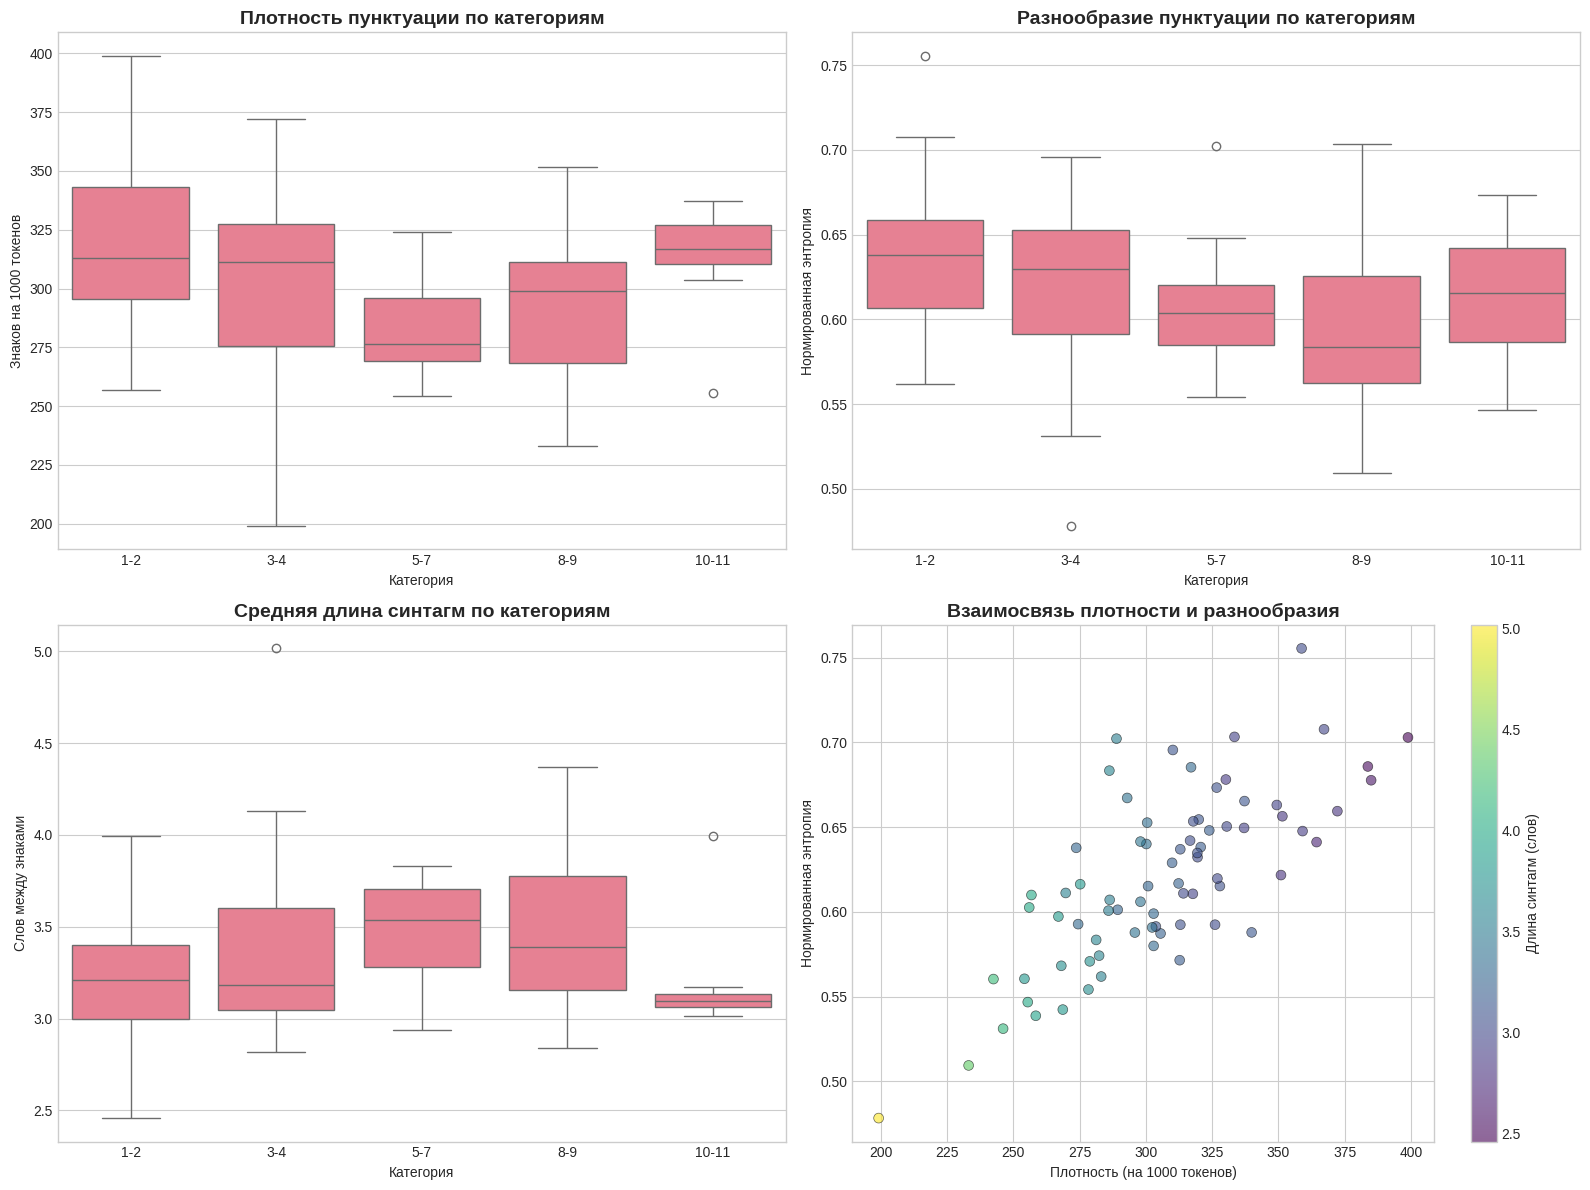


Корелляционная матрица метрик

График сохранён: correlation_matrix.png



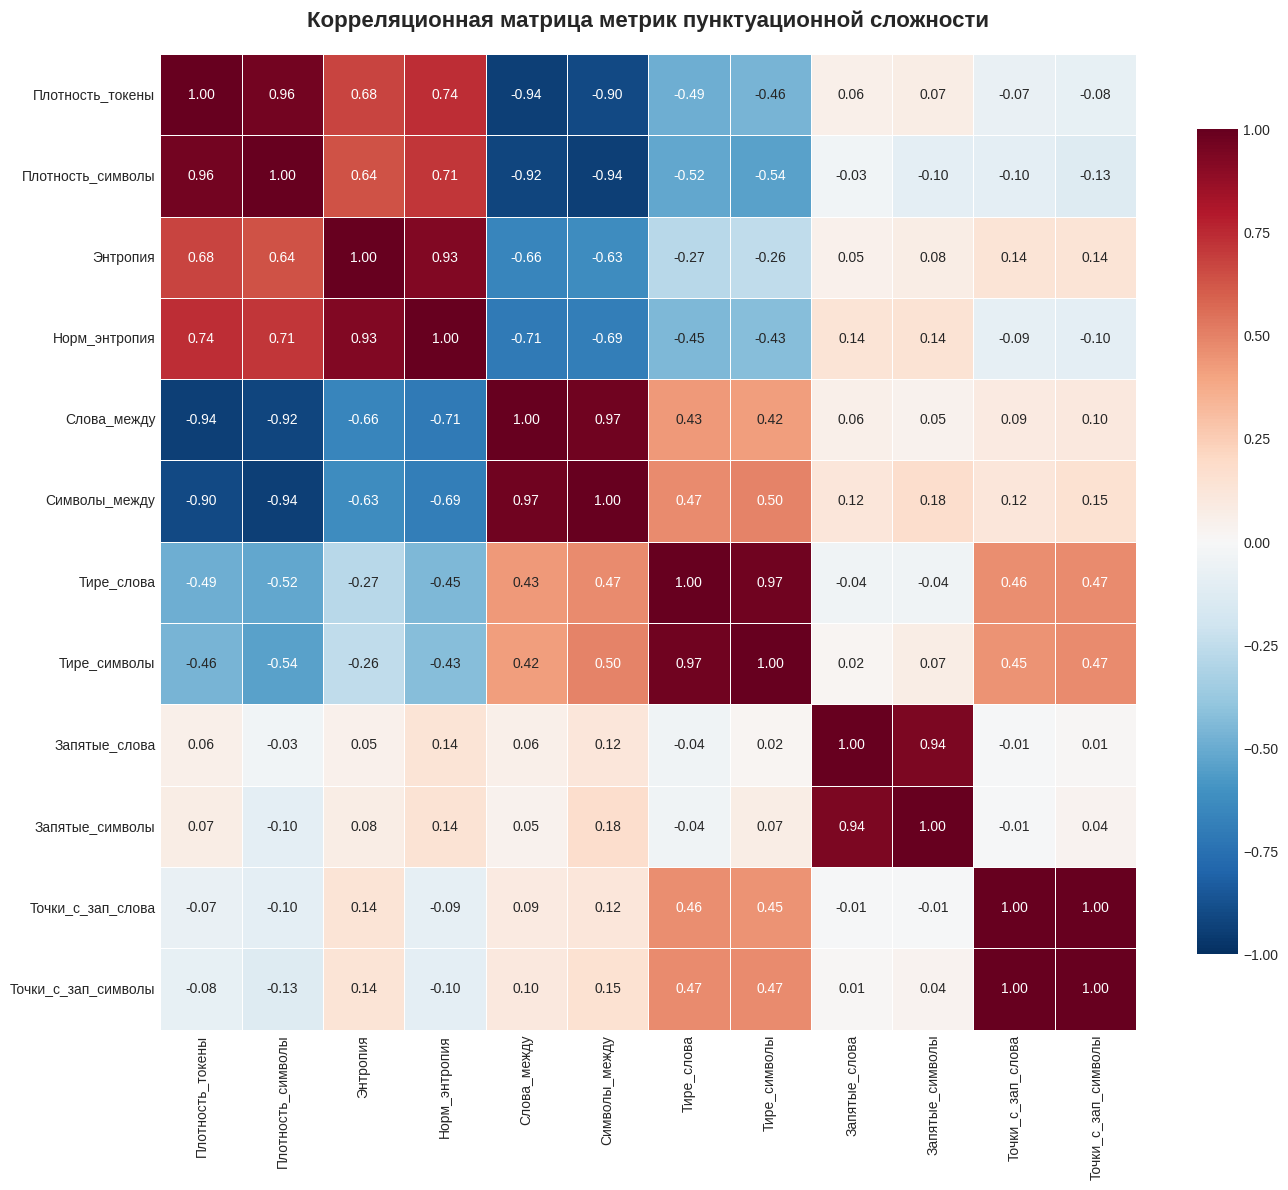


Корреляционная матрица (числовые значения):
                                density_per_1000_tokens  \
density_per_1000_tokens                           1.000   
density_per_1000_chars                            0.963   
entropy                                           0.677   
normalized_entropy                                0.736   
mean_words_between_all                           -0.939   
mean_chars_between_all                           -0.903   
between_dashes_mean_tokens                       -0.492   
between_dashes_mean_chars                        -0.463   
between_commas_mean_tokens                        0.060   
between_commas_mean_chars                         0.074   
between_semicolons_mean_tokens                   -0.072   
between_semicolons_mean_chars                    -0.081   

                                density_per_1000_chars  entropy  \
density_per_1000_tokens                          0.963    0.677   
density_per_1000_chars                           1.00

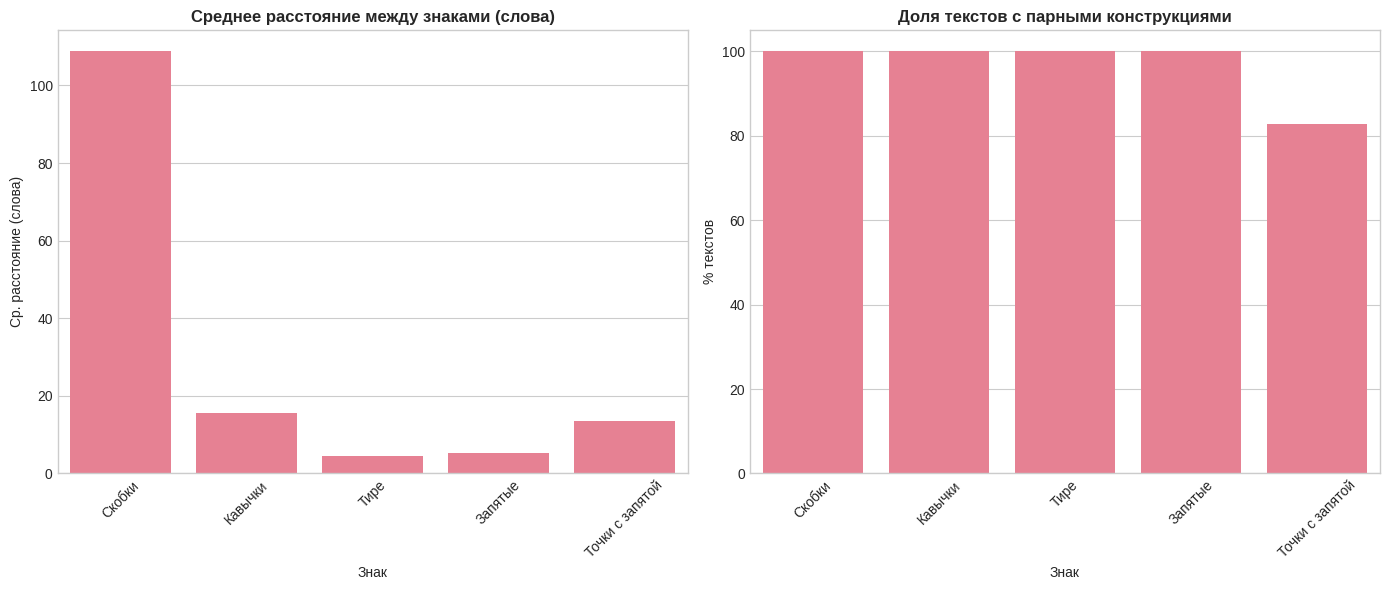


Результаты интерпретации сохранены: all_texts_with_interpretation.csv


In [ ]:
class PunctuationComplexityInterpreterKids:

    def __init__(self, data_path: str):
        self.df = self._load_data(data_path)
        self._prepare_data()

    def _load_data(self, data_path: str) -> pd.DataFrame:
        if not os.path.exists(data_path):
            raise FileNotFoundError(f"Файл {data_path} не найден!")

        df = pd.read_csv(data_path, encoding='utf-8-sig')
        return df

    def _prepare_data(self):
        numeric_cols = ['total_tokens', 'total_characters', 'total_punctuation',
                       'sentence_count', 'mean_words_per_sentence',
                       'density_per_1000_tokens', 'density_per_1000_chars',
                       'entropy', 'normalized_entropy',
                       'mean_words_between_all', 'mean_chars_between_all']

        for col in numeric_cols:
            if col in self.df.columns:
                self.df[col] = pd.to_numeric(self.df[col], errors='coerce')


    def print_general_stats(self):
        print("\nОбщая статистика\n")
        print(f"Всего текстов: {len(self.df)}")
        print(f"Средняя плотность пунктуации: {self.df['density_per_1000_tokens'].mean():.2f} знаков на 1000 токенов")
        print(f"Средняя нормированная энтропия: {self.df['normalized_entropy'].mean():.3f}")
        print(f"Средняя длина синтагм: {self.df['mean_words_between_all'].mean():.2f} слов")

    def print_complexity_distribution(self):
        print("\nРаспределение по уровням сложности\n")

        def classify_complexity(row):
            entropy = row.get('normalized_entropy', 0.5)
            density = row.get('density_per_1000_tokens', 200)

            if entropy < 0.6 and density < 250:
                return "Низкая"
            elif entropy < 0.7 and density < 350:
                return "Средняя"
            else:
                return "Высокая"

        self.df['complexity_level'] = self.df.apply(classify_complexity, axis=1)
        distribution = self.df['complexity_level'].value_counts()

        for level in ['Высокая', 'Средняя', 'Низкая']:
            if level in distribution:
                count = distribution[level]
                pct = count / len(self.df) * 100
                print(f"{level}: {count} текстов ({pct:.1f}%)")

    def print_methods_comparison(self):
        print("\nСравнение методов расчёта\n")

        comparison = pd.DataFrame()

        # Плотность: токены vs символы
        if 'density_per_1000_tokens' in self.df.columns and 'density_per_1000_chars' in self.df.columns:
            comparison.loc['density', 'correlation'] = self.df['density_per_1000_tokens'].corr(
                self.df['density_per_1000_chars']
            )
            comparison.loc['density', 'mean_diff_pct'] = abs(
                self.df['density_per_1000_tokens'].mean() - self.df['density_per_1000_chars'].mean()
            ) / self.df['density_per_1000_tokens'].mean() * 100

        # Длина отрезков: слова vs символы
        if 'mean_words_between_all' in self.df.columns and 'mean_chars_between_all' in self.df.columns:
            comparison.loc['length', 'correlation'] = self.df['mean_words_between_all'].corr(
                self.df['mean_chars_between_all']
            )
            comparison.loc['length', 'mean_diff_pct'] = 'N/A (разные единицы)'

        # Энтропия: ненормированная vs нормированная
        if 'entropy' in self.df.columns and 'normalized_entropy' in self.df.columns:
            comparison.loc['entropy', 'correlation'] = self.df['entropy'].corr(
                self.df['normalized_entropy']
            )
            comparison.loc['entropy', 'mean_diff_pct'] = 'N/A (разные шкалы)'

        print(comparison.round(3))

    def print_paired_distances_comparison(self):
        print("\nСравнение расстояний между парными знаками препинания\n")

        comparison = pd.DataFrame()

        paired_punct = ['dashes', 'commas', 'semicolons']

        for punct_type in paired_punct:
            tokens_col = f'between_{punct_type}_mean_tokens'
            chars_col = f'between_{punct_type}_mean_chars'
            count_col = f'between_{punct_type}_count'

            if tokens_col in self.df.columns and chars_col in self.df.columns:
                corr = self.df[tokens_col].corr(self.df[chars_col])

                if count_col in self.df.columns:
                    texts_with_pairs = (self.df[count_col] > 0).sum()
                    pct_with_pairs = texts_with_pairs / len(self.df) * 100
                else:
                    texts_with_pairs = (self.df[tokens_col] > 0).sum()
                    pct_with_pairs = texts_with_pairs / len(self.df) * 100

                comparison.loc[f'{punct_type}_pairs', 'correlation_tokens_chars'] = round(corr, 3)
                comparison.loc[f'{punct_type}_pairs', 'texts_with_pairs'] = texts_with_pairs
                comparison.loc[f'{punct_type}_pairs', 'pct_with_pairs'] = round(pct_with_pairs, 1)
                comparison.loc[f'{punct_type}_pairs', 'mean_distance_tokens'] = round(
                    self.df[self.df[tokens_col] > 0][tokens_col].mean() if texts_with_pairs > 0 else 0, 2
                )
                comparison.loc[f'{punct_type}_pairs', 'mean_distance_chars'] = round(
                    self.df[self.df[chars_col] > 0][chars_col].mean() if texts_with_pairs > 0 else 0, 2
                )

        print(comparison)

    def print_category_stats(self):
        if 'category' not in self.df.columns:
            print("\nСтатистика по категориям недоступна")
            return

        print("\nСтатистика по сферам функционирования (категориям)\n")

        category_order = ['1-2', '3-4', '5-7', '8-9', '10-11']
        self.df['category'] = pd.Categorical(self.df['category'], categories=category_order, ordered=True)

        density_stats = self.df.groupby('category', observed=True)['density_per_1000_tokens'].agg(['mean', 'std', 'min', 'max']).round(2)
        density_stats.columns = ['mean', 'std', 'min', 'max']
        print("density_per_1000_tokens")
        print("    mean    std    min    max")
        print("category")
        for cat in category_order:
            if cat in density_stats.index:
                row = density_stats.loc[cat]
                print(f"{cat}    {row['mean']:.2f}  {row['std']:.2f}  {row['min']:.2f}  {row['max']:.2f}")

        print("\nnormalized_entropy")
        print("    mean    std")
        print("category")
        entropy_stats = self.df.groupby('category', observed=True)['normalized_entropy'].agg(['mean', 'std']).round(3)
        for cat in category_order:
            if cat in entropy_stats.index:
                row = entropy_stats.loc[cat]
                print(f"{cat}    {row['mean']:.3f}  {row['std']:.3f}")

        print("\nmean_words_between_all")
        print("    mean    std")
        print("category")
        syntagm_stats = self.df.groupby('category', observed=True)['mean_words_between_all'].agg(['mean', 'std']).round(2)
        for cat in category_order:
            if cat in syntagm_stats.index:
                row = syntagm_stats.loc[cat]
                print(f"{cat}    {row['mean']:.2f}  {row['std']:.2f}")

        print("\ntotal_tokens")
        print("    count    mean")
        print("category")
        tokens_stats = self.df.groupby('category', observed=True)['total_tokens'].agg(['count', 'mean']).round(2)
        for cat in category_order:
            if cat in tokens_stats.index:
                row = tokens_stats.loc[cat]
                print(f"{cat}    {int(row['count'])}    {row['mean']:.2f}")

    def print_outliers(self, n_std: float = 2.0):
        print(f"\nВыбросы (n_std = {n_std})")

        outlier_mask = pd.Series(False, index=self.df.index)

        metric_cols = ['density_per_1000_tokens', 'normalized_entropy', 'mean_words_between_all']
        metric_cols = [c for c in metric_cols if c in self.df.columns]

        for col in metric_cols:
            mean = self.df[col].mean()
            std = self.df[col].std()
            col_mask = abs(self.df[col] - mean) > n_std * std
            outlier_mask = outlier_mask | col_mask

        outliers = self.df[outlier_mask]

        if len(outliers) > 0:
            print(f"Найдено {len(outliers)} текстов-выбросов\n")

            display_cols = ['filename', 'category', 'density_per_1000_tokens',
                           'normalized_entropy', 'mean_words_between_all']
            display_cols = [c for c in display_cols if c in outliers.columns]

            print(outliers[display_cols].head(10).to_string(index=False))
        else:
            print("\nВыбросы не обнаружены")

    def plot_category_distributions(self, save_path: Optional[str] = None):
        if 'category' not in self.df.columns:
            print("Нет данных по категориям для визуализации")
            return

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        category_order = ['1-2', '3-4', '5-7', '8-9', '10-11']
        df_for_plot = self.df[self.df['category'].isin(category_order)].copy()

        sns.boxplot(data=df_for_plot, x='category', y='density_per_1000_tokens',
                   order=category_order, ax=axes[0, 0])
        axes[0, 0].set_title('Плотность пунктуации по категориям', fontsize=14, fontweight='bold')
        axes[0, 0].set_xlabel('Категория')
        axes[0, 0].set_ylabel('Знаков на 1000 токенов')

        sns.boxplot(data=df_for_plot, x='category', y='normalized_entropy',
                   order=category_order, ax=axes[0, 1])
        axes[0, 1].set_title('Разнообразие пунктуации по категориям', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Категория')
        axes[0, 1].set_ylabel('Нормированная энтропия')

        # Длина синтагм
        sns.boxplot(data=df_for_plot, x='category', y='mean_words_between_all',
                   order=category_order, ax=axes[1, 0])
        axes[1, 0].set_title('Средняя длина синтагм по категориям', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Категория')
        axes[1, 0].set_ylabel('Слов между знаками')

        # Плотность vs энтропия
        scatter = axes[1, 1].scatter(df_for_plot['density_per_1000_tokens'],
                                    df_for_plot['normalized_entropy'],
                                    c=df_for_plot['mean_words_between_all'] if 'mean_words_between_all' in df_for_plot.columns else None,
                                    cmap='viridis', alpha=0.6, s=50, edgecolor='black', linewidth=0.5)
        axes[1, 1].set_title('Взаимосвязь плотности и разнообразия', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Плотность (на 1000 токенов)')
        axes[1, 1].set_ylabel('Нормированная энтропия')
        if 'mean_words_between_all' in df_for_plot.columns:
            plt.colorbar(scatter, ax=axes[1, 1], label='Длина синтагм (слов)')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"\nГрафик сохранён: {save_path}\n")

        plt.show()

    def plot_correlation_matrix(self, save_path: Optional[str] = None):
        print("\nКорелляционная матрица метрик")

        metric_cols = [
            'density_per_1000_tokens', 'density_per_1000_chars',
            'entropy', 'normalized_entropy',
            'mean_words_between_all', 'mean_chars_between_all'
        ]

        for punct_type in ['dashes', 'commas', 'semicolons', 'parentheses', 'quotes']:
            tokens_col = f'between_{punct_type}_mean_tokens'
            chars_col = f'between_{punct_type}_mean_chars'
            if tokens_col in self.df.columns:
                metric_cols.append(tokens_col)
            if chars_col in self.df.columns:
                metric_cols.append(chars_col)

        available_cols = [col for col in metric_cols if col in self.df.columns]

        if len(available_cols) < 2:
            print("Недостаточно метрик для корреляционного анализа")
            return

        corr_matrix = self.df[available_cols].corr()

        label_map = {
            'density_per_1000_tokens': 'Плотность_токены',
            'density_per_1000_chars': 'Плотность_символы',
            'entropy': 'Энтропия',
            'normalized_entropy': 'Норм_энтропия',
            'mean_words_between_all': 'Слова_между',
            'mean_chars_between_all': 'Символы_между',
            'between_dashes_mean_tokens': 'Тире_слова',
            'between_dashes_mean_chars': 'Тире_символы',
            'between_commas_mean_tokens': 'Запятые_слова',
            'between_commas_mean_chars': 'Запятые_символы',
            'between_semicolons_mean_tokens': 'Точки_с_зап_слова',
            'between_semicolons_mean_chars': 'Точки_с_зап_символы',
            'parentheses_mean_tokens': 'Скобки_слова',
            'parentheses_mean_chars': 'Скобки_символы',
            'quotes_mean_tokens': 'Кавычки_слова',
            'quotes_mean_chars': 'Кавычки_символы'
        }

        corr_matrix_plot = corr_matrix.copy()
        corr_matrix_plot.columns = [label_map.get(col, col) for col in corr_matrix_plot.columns]
        corr_matrix_plot.index = [label_map.get(col, col) for col in corr_matrix_plot.index]

        fig, ax = plt.subplots(figsize=(14, 12))

        mask = np.triu(np.ones_like(corr_matrix_plot, dtype=bool))
        sns.heatmap(corr_matrix_plot, annot=True, fmt='.2f',
                    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                    ax=ax)

        ax.set_title('Корреляционная матрица метрик пунктуационной сложности',
                     fontsize=16, fontweight='bold', pad=20)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"\nГрафик сохранён: {save_path}\n")

        plt.show()

        print("\nКорреляционная матрица (числовые значения):")
        print(corr_matrix.round(3))

        strong_corr = corr_matrix.abs().unstack()
        strong_corr = strong_corr[(strong_corr > 0.7) & (strong_corr < 1.0)]

        if not strong_corr.empty:
            print("\nСильные корреляции (>0.7):")
            strong_corr_sorted = strong_corr.sort_values(ascending=False)
            for (m1, m2), val in strong_corr_sorted.items():
                print(f"  {m1} ↔ {m2}: {val:.3f}")

    def print_paired_distances_table(self):
        print("\nАнализ расстояний между парными знаками препинания\n")

        punct_types = {
            'parentheses': 'Скобки',
            'quotes': 'Кавычки',
            'dashes': 'Тире',
            'commas': 'Запятые',
            'semicolons': 'Точки с запятой'
        }

        results = []

        for punct_key, punct_name in punct_types.items():
            possible_token_cols = [
                f'between_{punct_key}_mean_tokens',
                f'{punct_key}_mean_tokens',
                f'{punct_key}_mean_words'
            ]

            possible_char_cols = [
                f'between_{punct_key}_mean_chars',
                f'{punct_key}_mean_chars'
            ]

            possible_count_cols = [
                f'between_{punct_key}_count',
                f'{punct_key}_count'
            ]

            tokens_col = None
            for col in possible_token_cols:
                if col in self.df.columns:
                    tokens_col = col
                    break

            chars_col = None
            for col in possible_char_cols:
                if col in self.df.columns:
                    chars_col = col
                    break

            count_col = None
            for col in possible_count_cols:
                if col in self.df.columns:
                    count_col = col
                    break

            if tokens_col:
                texts_with = (self.df[tokens_col] > 0).sum()
                pct_with = texts_with / len(self.df) * 100
                mean_tokens = self.df[self.df[tokens_col] > 0][tokens_col].mean() if texts_with > 0 else 0
                std_tokens = self.df[self.df[tokens_col] > 0][tokens_col].std() if texts_with > 0 else 0

                mean_chars = 0
                if chars_col and chars_col in self.df.columns:
                    mean_chars = self.df[self.df[chars_col] > 0][chars_col].mean() if texts_with > 0 else 0

                results.append({
                    'Знак': punct_name,
                    'Колонка (tokens)': tokens_col,
                    'Колонка (chars)': chars_col if chars_col else 'не найдена',
                    'Текстов с конструкцией': int(texts_with),
                    '% текстов': round(pct_with, 1),
                    'Ср. расстояние (слова)': round(mean_tokens, 2)
                })

        if results:
            results_df = pd.DataFrame(results)
            print(results_df.to_string(index=False))

            fig, axes = plt.subplots(1, 2, figsize=(14, 6))

            plot_data = results_df[results_df['Ср. расстояние (слова)'] > 0]

            if len(plot_data) > 0:
                sns.barplot(data=plot_data, x='Знак', y='Ср. расстояние (слова)', ax=axes[0])
                axes[0].set_title('Среднее расстояние между знаками (слова)', fontsize=12, fontweight='bold')
                axes[0].tick_params(axis='x', rotation=45)

                sns.barplot(data=plot_data, x='Знак', y='% текстов', ax=axes[1])
                axes[1].set_title('Доля текстов с парными конструкциями', fontsize=12, fontweight='bold')
                axes[1].tick_params(axis='x', rotation=45)

                plt.tight_layout()
                plt.savefig('punct_pair_distances.png', dpi=300, bbox_inches='tight')
                print("\nГрафик сохранён: punct_pair_distances.png\n")
                plt.show()
        else:
            print("Не найдено данных ни для одного типа знаков")

    def generate_full_report(self):
        self.print_general_stats()
        self.print_complexity_distribution()
        self.print_methods_comparison()
        self.print_paired_distances_comparison()
        self.print_category_stats()
        self.print_outliers()
        self.plot_category_distributions(save_path='category_distributions.png')
        self.plot_correlation_matrix(save_path='correlation_matrix.png')  # ← НОВОЕ
        self.print_paired_distances_table()


def main():
    data_file = "kids_corpus_detailed_results.csv"

    if not os.path.exists(data_file):
        alternatives = [
            "kids_corpus_results_full.csv",
            "kids_corpus_basic_metrics.csv",
            "kids_corpus_raw_full.csv"
        ]

        for alt in alternatives:
            if os.path.exists(alt):
                data_file = alt
                break
        else:
            print(f"\nФайл с результатами не найден!")
            return

    try:
        interpreter = PunctuationComplexityInterpreterKids(data_file)

        interpreter.generate_full_report()

        output_file = "all_texts_with_interpretation.csv"
        interpreter.df.to_csv(output_file, index=False, encoding='utf-8-sig')
        print(f"\nРезультаты интерпретации сохранены: {output_file}")


    except Exception as e:
        print(f"\nОшибка при интерпретации: {e}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()

### Выводы по корпусу «От двух до 15»

**Общая характеристика корпуса**

В среднем у текстов высокая плотность пунктуации (306,14 знаков на 1000 токенов), что выше, чем во многих текстах Обучающего корпуса. Там средняя плотность была 305,92 знака на 1000 токенов при большем количестве текстов (1966).

Средняя нормированная энтропия корпуса «От двух до 15» составляет 0,62 — среднее разнообразие знаков препинания.

Средняя длина синтагматических отрезков — 3,32 слова. Это довольно короткие отрезки, что характерно для экспрессивной, синтаксически дробной речи.

**Уровни пунктуационной сложности**

Большинство текстов (78,7%) характеризуются средним уровне пунктуационной сложности. Высокий уровень сложности у 16% текстов, у 5,3% — низкий. Можно сделать вывод, что тексты корпуса достаточно однородны по этому параметру и в целом соответствуют среднему уровню развития пунктуационных навыков.

**Парные знаки препинания**

Скобки, тире, кавычки и парные запятые встречаются во всех 75 текстах корпуса. Точки с запятой есть только в 82,7% текстов.

Самое большое среднее расстояние — между открывающей и закрывающей скобкой (почти 109 слов). Вероятно, авторы текстов чаще использовали их для оформления очень длинных вставных конструкций или примечаний, а не коротких пояснений. При этом средняя длина вставных конструкций, оформленных с помощью тире, — 4,47 слова.

Внутри кавычек в среднем находится 15,48 слов. Это типично для оформления цитат, названий и прямой речи.

Между парными запятыми в среднем 5,22 слова, что нормально для обособленных оборотов.

Запятые в парных конструкциях встречаются во всех текстах, среднее расстояние — 5.22 слова (типично для обособленных оборотов). В то же время среднее расстояние между парными точками с запятой — 13,63 слова. Это согласуетя с функцией знака — разделением относительно крупных синтаксических единиц.

**Анализ возрастных категорий**

*Плотность пунктуации (знаков на 1000 токенов)*

- 1-2 класс: 319,71 — самая высокая плотность. Это может объясняться небольшой длиной текстов

- 3-4 класс: 299,54

- 5-7 класс: 284,31 — минимальная плотность

- 8-9 класс: 291,77

- 10-11 класс: 312,08 — высокая плотность, приближающаяся к показателям младших классов

Плотность пунктуации высокая в текстах для начальной школы, снижается в средних классах и снова растёт к старшим классам. Это может отражать переход от простых, но «перегруженных» пунктуацией текстов к более сложным синтаксическим конструкциям.

*Нормированная энтропия (разнообразие знаков)*

- 1-2 класс: 0,638 — самое высокое разнообразие

- 3-4 класс: 0,617

- 5-7 класс: 0,610

- 8-9 класс: 0,594 — минимальное разнообразие

- 10-11 класс: 0,614

Разнообразие знаков постепенно снижается к 8-9 классу, а затем возрастает. Это может быть связано с тем, что тексты для младших школьников ориентированы в том числе на ознакомление с разными знаками препинания, а произведения для старшеклассников насыщены сложными синтаксическими конструкциями, для выделения которых нужны лишь некоторые пунктуационные символы.

*Длина синтагм (слов между знаками)*

- 1-2 класс: 3,19 слова — самые короткие синтагмы (частая постановка знаков)

- 3-4 класс: 3,42

- 5-7 класс: 3,48

- 8-9 класс: 3,48

- 10-11 класс: 3,20

Длина синтагматических отрезков коррелирует с плотностью пунктуации (обратная зависимость, r = -0.94): чем выше плотность, тем короче синтагмы.

*Объём текстов*

- 1-2 класс: 31 текст, средняя длина 31,604 слова.

- 3-4 класс: 14 текстов, средняя длина 69,050 слов (резкий скачок объёма).

- 5-7 класс: 8 текстов, средняя длина 94,411 слов (максимум).

- 8-9 класс: 14 текстов, средняя длина 82,502 слов.

- 10-11 класс: 8 текстов, средняя длина 74,044 слов.

Объём текстов закономерно растёт от 1 к 11 классу, достигая пика в 5-7 классах, после чего несколько снижается. Однако следует учитывать, что количество текстов в разных возрастных группах неравномерно.

**Корреляционный анализ**

Сильная положительная корреляция наблюдается между всеми вариантами одной и той же метрики (плотность токены/символы, длина синтагм слова/символы, энтропия / нормированная энтропия, парные знаки). Это подтверждает валидность измерений.

Сильная отрицательная корреляция между плотностью пунктуации и длиной синтагм (r ~ -0.94): чем чаще расставлены знаки, тем короче отрезки между ними.

Расстояния между парными знаками (тире, запятые, точки с запятой) в словах и в символах демонстрируют высокую корреляцию (r > 0.94). Это говорит о предсказуемости длины этих конструкций.

**Итог**

Корпус «От двух до 15» — достаточно однородный массив текстов среднего уровня пунктуационной сложности. Есть чёткие возрастные закономерности: тексты для младших классов характеризуются высокой плотностью пунктуации, короткими синтагмами и большим разнообразием знаков; в средних классах плотность снижается, а синтагмы удлинняются; к старшим классам показатели вновь приближаются к уровню младших, но на качественно ином уровне — за счёт усложнения синтаксиса, а не избыточности знаков.

Наиболее информативными метриками для оценки пунктуационной сложности детских текстов, по-видимому, являются плотность пунктуации и длина синтагматических отрезков.

## Корпус «Русская классика»

### Расчёты

In [ ]:
class PunctuationComplexityAnalyzerClassics:
    def __init__(self):
        self.reset_for_new_file()

    def reset_for_new_file(self):
        self.text = ""
        self.tokens = []
        self.punctuation_marks = []
        self.punctuation_by_type = Counter()
        self.sentences = []
        self.filename = ""
        self.filepath = ""
        self._punct_positions_cache = None
        self._word_positions_cache = None
        self._sentence_boundaries_cache = None

    def extract_text_from_xml(self, file_path: str) -> str:
        try:
            tree = ET.parse(file_path)
            root = tree.getroot()

            text_parts = []
            for elem in root.iter():
                if elem.text and elem.tag not in ['meta', 'head', 'span']:
                    if elem.get('class') != 'note':
                        text_parts.append(elem.text)
                if elem.tail and elem.tag not in ['meta', 'head', 'span']:
                    if elem.get('class') != 'note':
                        text_parts.append(elem.tail)

            self.text = ' '.join(text_parts)
            self.text = re.sub(r'\s+', ' ', self.text).strip()
            return self.text

        except Exception as e:
            print(f"Ошибка при чтении XML {file_path}: {e}")
            return ""

    def tokenize(self) -> List[str]:
        words_text = re.sub(r'[^\w\s]', ' ', self.text)
        self.tokens = [word for word in words_text.split() if word.strip()]
        return self.tokens

    def extract_punctuation(self) -> List[str]:
        punct_pattern = r'[.,!?;:\-–—"«»\'\(\)\[\]{}…]|\.{3,}'
        self.punctuation_marks = []

        for match in re.finditer(punct_pattern, self.text):
            punct = match.group()
            if punct.startswith('...'):
                punct = '…'
            self.punctuation_marks.append(punct)

        self.punctuation_by_type = Counter(self.punctuation_marks)
        return self.punctuation_marks

    def split_into_sentences(self) -> List[str]:
        sentence_endings = r'(?<=[.!?…])\s+(?=[А-ЯA-Z])'
        self.sentences = re.split(sentence_endings, self.text)
        self.sentences = [s.strip() for s in self.sentences if s.strip()]
        self._sentence_boundaries_cache = None  # Сбрасываем кэш
        return self.sentences

    def get_author_and_category_from_path(self, file_path: str, base_dir: str) -> Tuple[str, str]:
        """
        Определение автора и категории по пути к файлу
        Структура: classics-master-texts/texts/author/category/file.xml
        """
        try:
            rel_path = os.path.relpath(file_path, base_dir)
            parts = Path(rel_path).parts

            author = "unknown"
            category = "unknown"

            # Ищем части пути
            if len(parts) >= 4:  # classics-master-texts/texts/author/category/file.xml
                # parts[0] = classics-master-texts
                # parts[1] = texts
                # parts[2] = автор (например, pushkin)
                # parts[3] = категория (например, works)
                if len(parts) >= 3:
                    author = parts[2]
                if len(parts) >= 4:
                    category = parts[3]

            return author, category
        except:
            return "unknown", "unknown"

    def get_absolute_metrics(self, base_dir: str) -> Dict:
        char_count = len(self.text)
        token_count = len(self.tokens)
        punct_count = len(self.punctuation_marks)

        unique_punct = set()
        for p in self.punctuation_marks:
            if p in ['—', '–', ' - ', '--']:
                unique_punct.add('—')
            elif p in ['«', '»', '"', "'"]:
                unique_punct.add('«»')
            elif p == '…':
                unique_punct.add('…')
            else:
                unique_punct.add(p)

        author, category = self.get_author_and_category_from_path(self.filepath, base_dir)

        return {
            'filename': self.filename,
            'author': author,
            'category': category,
            'total_characters': char_count,
            'total_tokens': token_count,
            'total_punctuation': punct_count,
            'unique_punctuation_count': len(unique_punct),
            'unique_punctuation_list': sorted(list(unique_punct))
        }

    def calculate_punctuation_density(self) -> Dict:
        char_count = len(self.text)
        token_count = len(self.tokens)
        punct_count = len(self.punctuation_marks)

        density_per_1000_tokens = (punct_count / token_count) * 1000 if token_count > 0 else 0
        density_per_1000_chars = (punct_count / char_count) * 1000 if char_count > 0 else 0

        # Используем кэшированные позиции
        all_punct_positions = [pos for pos, _ in self._get_punct_positions()]

        # Блоки по символам (1000 символов)
        blocks_density_chars = []
        for i in range(0, char_count, 1000):
            end_char_idx = min(i + 1000, char_count)
            if end_char_idx - i < 200:
                continue

            punct_in_block = sum(1 for pos in all_punct_positions if i <= pos < end_char_idx)
            block_char_count = end_char_idx - i
            density = (punct_in_block / block_char_count) * 1000
            blocks_density_chars.append(density)

        # Блоки по токенам (1000 слов)
        blocks_density_tokens = []
        if token_count >= 1000:
            token_positions = self._get_word_positions()

            for i in range(0, len(token_positions), 1000):
                end_idx = min(i + 1000, len(token_positions))
                if end_idx - i < 100:
                    continue

                start_char = token_positions[i]
                end_char = token_positions[end_idx - 1] + 50

                punct_in_block = sum(1 for pos in all_punct_positions if start_char <= pos < end_char)
                block_token_count = end_idx - i
                density = (punct_in_block / block_token_count) * 1000
                blocks_density_tokens.append(density)

        return {
            'density_per_1000_tokens': density_per_1000_tokens,
            'density_per_1000_chars': density_per_1000_chars,
            'blocks_tokens_mean': np.mean(blocks_density_tokens) if blocks_density_tokens else density_per_1000_tokens,
            'blocks_tokens_std': np.std(blocks_density_tokens) if blocks_density_tokens else 0,
            'blocks_tokens_min': min(blocks_density_tokens) if blocks_density_tokens else 0,
            'blocks_tokens_max': max(blocks_density_tokens) if blocks_density_tokens else 0,
            'blocks_chars_mean': np.mean(blocks_density_chars) if blocks_density_chars else density_per_1000_chars,
            'blocks_chars_std': np.std(blocks_density_chars) if blocks_density_chars else 0,
            'blocks_chars_min': min(blocks_density_chars) if blocks_density_chars else 0,
            'blocks_chars_max': max(blocks_density_chars) if blocks_density_chars else 0
        }

    def calculate_punctuation_diversity(self) -> Dict:
        if not self.punctuation_by_type:
            return {'entropy': 0, 'normalized_entropy': 0}

        total = sum(self.punctuation_by_type.values())

        entropy = 0
        for count in self.punctuation_by_type.values():
            p = count / total
            entropy -= p * math.log2(p)

        max_entropy = math.log2(len(self.punctuation_by_type))
        normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0

        return {
            'entropy': entropy,
            'normalized_entropy': normalized_entropy,
            'unique_punct_types': len(self.punctuation_by_type)
        }

    def _get_punct_positions(self):
        if self._punct_positions_cache is None:
            self._punct_positions_cache = []
            for match in re.finditer(r'[.,!?;:\-–—"«»\'\(\)\[\]{}…]|\.{3,}', self.text):
                punct = match.group()
                if punct.startswith('...'):
                    punct = '…'
                self._punct_positions_cache.append((match.start(), punct))
        return self._punct_positions_cache

    def _get_word_positions(self):
        if self._word_positions_cache is None:
            self._word_positions_cache = []
            for match in re.finditer(r'\b\w+\b', self.text):
                self._word_positions_cache.append(match.start())
        return self._word_positions_cache

    def _get_sentence_boundaries(self):
        """Кэширование границ предложений"""
        if self._sentence_boundaries_cache is None:
            self._sentence_boundaries_cache = []
            current_pos = 0
            for sentence in self.sentences:
                sent_start = self.text.find(sentence, current_pos)
                if sent_start != -1:
                    sent_end = sent_start + len(sentence)
                    self._sentence_boundaries_cache.append((sent_start, sent_end))
                    current_pos = sent_end
        return self._sentence_boundaries_cache

    def calculate_mean_syntagmatic_length(self) -> Dict:
        punct_positions = self._get_punct_positions()
        punct_positions_only = [pos for pos, _ in punct_positions]

        if len(punct_positions_only) < 2:
            return {
                'mean_words_between_all': 0, 'mean_chars_between_all': 0,
                'min_words_between': 0, 'max_words_between': 0,
                'min_chars_between': 0, 'max_chars_between': 0,
                'std_words_between': 0, 'std_chars_between': 0
            }

        word_positions = self._get_word_positions()

        distances_words = []
        distances_chars = []

        max_samples = 500  # Ограничиваем для ускорения

        if len(punct_positions_only) - 1 > max_samples:
            step = (len(punct_positions_only) - 1) // max_samples
            indices = list(range(0, len(punct_positions_only) - 1, step))[:max_samples]
        else:
            indices = range(len(punct_positions_only) - 1)

        for i in indices:
            char_distance = punct_positions_only[i+1] - punct_positions_only[i] - 1
            if char_distance >= 0:
                distances_chars.append(char_distance)

                words_between = 0
                for word_pos in word_positions:
                    if punct_positions_only[i] < word_pos < punct_positions_only[i+1]:
                        words_between += 1
                distances_words.append(words_between)

        return {
            'mean_words_between_all': np.mean(distances_words) if distances_words else 0,
            'mean_chars_between_all': np.mean(distances_chars) if distances_chars else 0,
            'min_words_between': min(distances_words) if distances_words else 0,
            'max_words_between': max(distances_words) if distances_words else 0,
            'min_chars_between': min(distances_chars) if distances_chars else 0,
            'max_chars_between': max(distances_chars) if distances_chars else 0,
            'std_words_between': np.std(distances_words) if distances_words else 0,
            'std_chars_between': np.std(distances_chars) if distances_chars else 0
        }

    def calculate_sentence_based_metrics(self) -> Dict:
        if not self.sentences:
            self.split_into_sentences()

        words_per_sentence = []
        chars_per_sentence = []

        for sentence in self.sentences:
            words = len(re.findall(r'\b\w+\b', sentence))
            if words > 0:
                words_per_sentence.append(words)
                chars_per_sentence.append(len(sentence))

        return {
            'sentence_count': len(self.sentences),
            'mean_words_per_sentence': np.mean(words_per_sentence) if words_per_sentence else 0,
            'std_words_per_sentence': np.std(words_per_sentence) if words_per_sentence else 0,
            'min_words_per_sentence': min(words_per_sentence) if words_per_sentence else 0,
            'max_words_per_sentence': max(words_per_sentence) if words_per_sentence else 0,
            'mean_chars_per_sentence': np.mean(chars_per_sentence) if chars_per_sentence else 0
        }

    def calculate_paired_distances(self) -> Dict:
        """Расчет расстояний для парных знаков (скобки и кавычки)"""
        result = {
            'quotes_mean_tokens': 0, 'quotes_min_tokens': 0, 'quotes_max_tokens': 0,
            'quotes_mean_chars': 0, 'quotes_min_chars': 0, 'quotes_max_chars': 0,
            'quotes_count': 0,
            'parentheses_mean_tokens': 0, 'parentheses_min_tokens': 0, 'parentheses_max_tokens': 0,
            'parentheses_mean_chars': 0, 'parentheses_min_chars': 0, 'parentheses_max_chars': 0,
            'parentheses_count': 0
        }

        # Кавычки
        quote_pattern = r'[«"]([^»"]+)[»"]'
        quote_lengths_tokens = []
        quote_lengths_chars = []

        for match in re.finditer(quote_pattern, self.text):
            quote_text = match.group(1)
            quote_lengths_chars.append(len(quote_text))
            tokens = len(re.findall(r'\b\w+\b', quote_text))
            if tokens > 0:
                quote_lengths_tokens.append(tokens)

        if quote_lengths_tokens:
            result['quotes_mean_tokens'] = np.mean(quote_lengths_tokens)
            result['quotes_min_tokens'] = min(quote_lengths_tokens)
            result['quotes_max_tokens'] = max(quote_lengths_tokens)
            result['quotes_mean_chars'] = np.mean(quote_lengths_chars)
            result['quotes_min_chars'] = min(quote_lengths_chars)
            result['quotes_max_chars'] = max(quote_lengths_chars)
            result['quotes_count'] = len(quote_lengths_tokens)

        # Скобки
        paren_pattern = r'\(([^)]+)\)'
        paren_lengths_tokens = []
        paren_lengths_chars = []

        for match in re.finditer(paren_pattern, self.text):
            paren_text = match.group(1)
            paren_lengths_chars.append(len(paren_text))
            tokens = len(re.findall(r'\b\w+\b', paren_text))
            if tokens > 0:
                paren_lengths_tokens.append(tokens)

        if paren_lengths_tokens:
            result['parentheses_mean_tokens'] = np.mean(paren_lengths_tokens)
            result['parentheses_min_tokens'] = min(paren_lengths_tokens)
            result['parentheses_max_tokens'] = max(paren_lengths_tokens)
            result['parentheses_mean_chars'] = np.mean(paren_lengths_chars)
            result['parentheses_min_chars'] = min(paren_lengths_chars)
            result['parentheses_max_chars'] = max(paren_lengths_chars)
            result['parentheses_count'] = len(paren_lengths_tokens)

        return result

    def calculate_specific_distances(self) -> Dict:
        """Расчет расстояний для конкретных знаков (запятые, точки с запятой, тире) внутри предложений"""
        result = {
            'between_commas_mean_tokens': 0, 'between_commas_min_tokens': 0, 'between_commas_max_tokens': 0,
            'between_commas_mean_chars': 0, 'between_commas_min_chars': 0, 'between_commas_max_chars': 0,
            'between_commas_count': 0,

            'between_semicolons_mean_tokens': 0, 'between_semicolons_min_tokens': 0, 'between_semicolons_max_tokens': 0,
            'between_semicolons_mean_chars': 0, 'between_semicolons_min_chars': 0, 'between_semicolons_max_chars': 0,
            'between_semicolons_count': 0,

            'between_dashes_mean_tokens': 0, 'between_dashes_min_tokens': 0, 'between_dashes_max_tokens': 0,
            'between_dashes_mean_chars': 0, 'between_dashes_min_chars': 0, 'between_dashes_max_chars': 0,
            'between_dashes_count': 0
        }

        punct_positions = self._get_punct_positions()

        if len(punct_positions) < 5:
            return result

        word_positions = self._get_word_positions()

        # Расстояния между запятыми
        self._calculate_punct_distances_in_sentences_optimized(',', 'commas', result, punct_positions, word_positions)

        # Расстояния между точками с запятой
        self._calculate_punct_distances_in_sentences_optimized(';', 'semicolons', result, punct_positions, word_positions)

        # Расстояния между тире (только парные случаи)
        dash_chars = ['—', '–', ' - ', '--']
        self._calculate_punct_distances_in_sentences_optimized(dash_chars, 'dashes', result, punct_positions, word_positions, require_pair=True)

        return result

    def _calculate_punct_distances_in_sentences_optimized(self, punct_chars, result_key, result, punct_positions, word_positions, require_pair=False):
        """Оптимизированная версия для расчета расстояний между знаками внутри предложений"""
        if not isinstance(punct_chars, list):
            punct_chars = [punct_chars]

        sentence_boundaries = self._get_sentence_boundaries()

        if not sentence_boundaries:
            return

        # Группируем знаки по предложениям
        punct_by_sentence = [[] for _ in range(len(sentence_boundaries))]

        for pos, punct in punct_positions:
            if punct not in punct_chars:
                continue

            for i, (sent_start, sent_end) in enumerate(sentence_boundaries):
                if sent_start <= pos < sent_end:
                    punct_by_sentence[i].append(pos)
                    break

        distances_tokens = []
        distances_chars = []

        # Обрабатываем каждое предложение
        for sent_idx, (sent_start, sent_end) in enumerate(sentence_boundaries):
            positions = punct_by_sentence[sent_idx]
            if not positions:
                continue

            positions.sort()

            if len(positions) < 2:
                # Один знак в предложении
                if len(positions) == 1 and not require_pair:
                    pos = positions[0]

                    # От начала до знака
                    if pos > sent_start:
                        char_dist = pos - sent_start
                        if char_dist > 0:
                            distances_chars.append(char_dist)
                            words_before = sum(1 for wp in word_positions if sent_start < wp < pos)
                            if words_before > 0:
                                distances_tokens.append(words_before)

                    # От знака до конца
                    if pos < sent_end - 1:
                        char_dist = sent_end - pos - 1
                        if char_dist > 0:
                            distances_chars.append(char_dist)
                            words_after = sum(1 for wp in word_positions if pos < wp < sent_end)
                            if words_after > 0:
                                distances_tokens.append(words_after)
            else:
                # Несколько знаков - считаем между соседними
                for i in range(len(positions) - 1):
                    char_dist = positions[i+1] - positions[i] - 1
                    if char_dist > 0:
                        distances_chars.append(char_dist)
                        words_between = sum(1 for wp in word_positions if positions[i] < wp < positions[i+1])
                        if words_between > 0:
                            distances_tokens.append(words_between)

        if distances_tokens:
            result[f'between_{result_key}_mean_tokens'] = np.mean(distances_tokens)
            result[f'between_{result_key}_min_tokens'] = min(distances_tokens)
            result[f'between_{result_key}_max_tokens'] = max(distances_tokens)
            result[f'between_{result_key}_mean_chars'] = np.mean(distances_chars) if distances_chars else 0
            result[f'between_{result_key}_min_chars'] = min(distances_chars) if distances_chars else 0
            result[f'between_{result_key}_max_chars'] = max(distances_chars) if distances_chars else 0
            result[f'between_{result_key}_count'] = len(distances_tokens)

    def analyze_file(self, file_path: str, filename: str, base_dir: str) -> Dict:
        self.reset_for_new_file()
        self.filename = filename
        self.filepath = file_path

        self.extract_text_from_xml(file_path)
        if not self.text:
            return None

        self.tokenize()
        self.extract_punctuation()
        self.split_into_sentences()

        results = {
            **self.get_absolute_metrics(base_dir),
            **self.calculate_punctuation_density(),
            **self.calculate_punctuation_diversity(),
            **self.calculate_mean_syntagmatic_length(),
            **self.calculate_sentence_based_metrics(),
            **self.calculate_paired_distances(),
            **self.calculate_specific_distances()
        }

        return results

In [ ]:
def extract_archive(zip_path: str, extract_path: str = "extracted_classics_corpus"):
    print(f"Извлечение архива {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Архив извлечен в {extract_path}")
    return extract_path


def find_xml_files(root_dir: str) -> List[Dict]:
    xml_files = []

    for root, dirs, files in os.walk(root_dir):
        # Исключаем скрытые папки
        dirs[:] = [d for d in dirs if not d.startswith('.')]

        for file in files:
            if file.endswith('.xml') and not file.startswith('.'):
                full_path = os.path.join(root, file)
                if os.path.getsize(full_path) > 0:  # Проверяем, что файл не пустой
                    xml_files.append({
                        'path': full_path,
                        'filename': file
                    })

    return xml_files


def process_batch(file_infos, base_dir):
    analyzer = PunctuationComplexityAnalyzerClassics()
    batch_results = []

    for file_info in file_infos:
        try:
            result = analyzer.analyze_file(file_info['path'], file_info['filename'], base_dir)
            if result:
                batch_results.append(result)
        except Exception as e:
            print(f"\nОшибка при обработке {file_info['path']}: {e}")

    return batch_results

In [ ]:
def process_corpus_classics(zip_path: str = "classics-corpus.zip", extract_to: str = "extracted_classics_corpus",
                            max_workers=None, batch_size=20):

    if not os.path.exists(zip_path):
        print(f"Файл {zip_path} не найден!")
        print(f"Текущая папка: {os.getcwd()}")
        return None

    if not os.path.exists(extract_to):
        extract_path = extract_archive(zip_path, extract_to)
    else:
        extract_path = extract_to
        print(f"Используем существующую папку {extract_path}")

    xml_files = find_xml_files(extract_path)
    print(f"Найдено {len(xml_files)} XML-файлов")

    if max_workers is None:
        max_workers = max(1, multiprocessing.cpu_count() - 1)

    batches = []
    for i in range(0, len(xml_files), batch_size):
        batches.append(xml_files[i:i + batch_size])

    all_results = []

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        future_to_batch = {executor.submit(process_batch, batch, extract_path): i
                          for i, batch in enumerate(batches)}

        with tqdm(total=len(xml_files), desc="Анализ", unit="файл") as pbar:
            for future in as_completed(future_to_batch):
                batch_results = future.result()
                all_results.extend(batch_results)
                pbar.update(len(batch_results))

    print(f"\nУспешно обработано {len(all_results)} файлов")

    df = pd.DataFrame(all_results)
    return df

In [ ]:
def show_general_info(df):
    """Общая информация о корпусе"""
    print(f"\nВсего обработано текстов: {len(df)}")

    if 'author' in df.columns:
        print(f"Количество авторов: {df['author'].nunique()}")

    if 'category' in df.columns:
        categories = ['works', 'drama', 'letters', 'notes']
        print(f"Категории: {', '.join(categories)}")

    print("\nПервые 20 текстов:")

    display_cols = [
        'filename', 'author', 'category', 'total_tokens', 'total_punctuation',
        'density_per_1000_tokens', 'entropy',
        'mean_words_between_all', 'sentence_count'
    ]

    available_cols = [col for col in display_cols if col in df.columns]
    display_df = df[available_cols].copy().head(20)

    col_names = {
        'filename': 'Файл',
        'author': 'Автор',
        'category': 'Категория',
        'total_tokens': 'Слов',
        'total_punctuation': 'Знаков',
        'density_per_1000_tokens': 'Плотность на 1000 токенов',
        'entropy': 'Энтропия',
        'mean_words_between_all': 'Слов между знаками',
        'sentence_count': 'Предложений'
    }

    display_df.columns = [col_names.get(col, col) for col in available_cols]

    for col in display_df.select_dtypes(include=[np.number]).columns:
        display_df[col] = display_df[col].round(2)

    print(display_df.to_string(index=False))
    print()

In [ ]:
def show_author_stats(df):
    """Статистика по авторам"""
    if 'author' not in df.columns:
        return

    print("Топ-20 авторов по количеству текстов")

    author_counts = df['author'].value_counts().head(20)

    print("\nАвтор                 текстов")

    for author, count in author_counts.items():
        print(f"{author:<20} {count:>3}")
    print()

In [ ]:
def show_category_stats(df):
    """Статистика по категориям"""
    if 'category' not in df.columns:
        return

    print("Статистика по категориям:")

    cat_stats = df.groupby('category').agg({
        'filename': 'count',
        'total_tokens': ['mean', 'std'],
        'density_per_1000_tokens': ['mean', 'std'],
        'normalized_entropy': ['mean', 'std'],
        'mean_words_between_all': ['mean', 'std']
    }).round(2)

    cat_stats.columns = ['_'.join(col).strip() for col in cat_stats.columns.values]
    cat_stats = cat_stats.rename(columns={'filename_count': 'текстов'})

    print(cat_stats.to_string())
    print()

In [ ]:
def show_summary_stats(df):
    """Сводная статистика по всем метрикам"""
    print("Сводная статистика по всем метрикам")

    numeric_cols = [
        'total_characters', 'total_tokens', 'total_punctuation',
        'density_per_1000_tokens', 'density_per_1000_chars',
        'entropy', 'normalized_entropy',
        'mean_words_between_all', 'mean_chars_between_all',
        'sentence_count', 'mean_words_per_sentence'
    ]

    available_cols = [col for col in numeric_cols if col in df.columns]

    if not available_cols:
        return

    summary = df[available_cols].describe().round(2)

    col_names = {
        'total_characters': 'символов',
        'total_tokens': 'слов',
        'total_punctuation': 'знаков',
        'density_per_1000_tokens': 'плотн_токены',
        'density_per_1000_chars': 'плотн_символы',
        'entropy': 'энтропия',
        'normalized_entropy': 'норм_энтропия',
        'mean_words_between_all': 'слов_между_знаками',
        'mean_chars_between_all': 'симв_между_знаками',
        'sentence_count': 'кол_предл',
        'mean_words_per_sentence': 'ср_длина_предл'
    }

    summary.columns = [col_names.get(col, col) for col in available_cols]
    print(summary.to_string())
    print()

In [ ]:
def save_all_results(df, base_name="classics_corpus"):
    """Сохранение всех результатов в CSV"""

    df.to_csv(f"{base_name}_detailed_results.csv", index=False, encoding='utf-8-sig')
    print(f"Полные результаты сохранены: {base_name}_detailed_results.csv")

    basic_cols = [
        'filename', 'author', 'category', 'total_tokens', 'total_punctuation',
        'density_per_1000_tokens', 'entropy', 'normalized_entropy',
        'mean_words_between_all', 'sentence_count', 'mean_words_per_sentence'
    ]

    available_basic = [col for col in basic_cols if col in df.columns]
    if available_basic:
        df[available_basic].to_csv(f"{base_name}_basic_metrics.csv", index=False, encoding='utf-8-sig')
        print(f"Базовые метрики сохранены: {base_name}_basic_metrics.csv")

In [ ]:
def run_analysis_classics():
    start_time = time.time()

    df = process_corpus_classics(
        zip_path="classics-corpus.zip",
        max_workers=4,
        batch_size=20
    )

    if df is None or df.empty:
        print("Не удалось обработать файлы!")
        return None

    elapsed_time = time.time() - start_time
    hours = int(elapsed_time // 3600)
    minutes = int((elapsed_time % 3600) // 60)
    seconds = int(elapsed_time % 60)
    print(f"\nОбщее время обработки: {hours} ч {minutes} мин {seconds} сек")

    return df

In [ ]:
df = run_analysis_classics()

Используем существующую папку extracted_classics_corpus
Найдено 35960 XML-файлов


Анализ: 100%|██████████| 35960/35960 [1:32:55<00:00,  6.45файл/s]



Успешно обработано 35960 файлов

Общее время обработки: 1 ч 32 мин 57 сек


In [ ]:
show_general_info(df)


Всего обработано текстов: 35960
Количество авторов: 16
Категории: works, drama, letters, notes

Первые 20 текстов:
            Файл    Автор        Категория  Слов  Знаков  Плотность на 1000 токенов  Энтропия  Слов между знаками  Предложений
 writing_542.xml nekrasov  writing_542.xml    22       3                     136.36      0.92                6.50            1
 writing_618.xml nekrasov  writing_618.xml    77      24                     311.69      2.12                3.22            5
writing_1714.xml nekrasov writing_1714.xml    91      26                     285.71      1.77                3.60           11
 writing_811.xml nekrasov  writing_811.xml  1248     366                     293.27      2.37                3.40           81
writing_1475.xml nekrasov writing_1475.xml    26      12                     461.54      1.21                2.27            6
 writing_487.xml nekrasov  writing_487.xml   760     301                     396.05      2.74                2.52         

In [ ]:
show_author_stats(df)

Топ-20 авторов по количеству текстов

Автор                 текстов
tolstoy              13935
chekhov              5067
turgenev             4030
nekrasov             2820
saltykov-schedrin    2152
pushkin              1751
gogol                1687
dostoevsky           1360
tiutchev             778
leskov               560
lermontov            510
zhukovsky            404
krylov               378
baratynsky           246
griboedov            168
radischev            114



In [ ]:
show_category_stats(df)

Статистика по категориям:
                           текстов  total_tokens_mean  total_tokens_std  density_per_1000_tokens_mean  density_per_1000_tokens_std  normalized_entropy_mean  normalized_entropy_std  mean_words_between_all_mean  mean_words_between_all_std
category                                                                                                                                                                                                                                    
drama                           16           10041.75          10463.94                        497.68                        57.88                     0.62                    0.04                         2.07                        0.27
letters                      16731             201.19            218.81                        293.71                       163.71                     0.72                    0.14                         3.65                        0.96
notes                     

In [ ]:
save_all_results(df)

Полные результаты сохранены: classics_corpus_detailed_results.csv
Базовые метрики сохранены: classics_corpus_basic_metrics.csv


### Интерпретация

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 30)

In [ ]:
class ClassicsCorpusInterpreter:
    """
    Класс для интерпретации результатов анализа пунктуационной сложности
    корпуса русской классики
    """

    # Категории, которые оставляем как есть
    KEEP_CATEGORIES = ['works', 'drama', 'letters', 'notes']

    def __init__(self, data_path: str):
        """
        Параметры:
        data_path: путь к CSV-файлу с результатами анализа
        """
        self.df = self._load_data(data_path)
        self._recode_categories()  # Перекодируем категории
        self._prepare_data()

    def _load_data(self, data_path: str) -> pd.DataFrame:
        """Загрузка данных из CSV"""
        if not os.path.exists(data_path):
            raise FileNotFoundError(f"Файл {data_path} не найден!")

        df = pd.read_csv(data_path, encoding='utf-8-sig')
        print(f"Загружено {len(df)} текстов")
        return df

    def _recode_categories(self):
        """
        Перекодировка категорий:
        - 'works', 'drama', 'letters', 'notes' оставляем как есть
        - все остальные заменяем на 'works'
        """
        if 'category' in self.df.columns:
            # Подсчитываем исходное распределение
            original_counts = self.df['category'].value_counts()
            print("\nИсходное распределение по категориям:")
            for cat, count in original_counts.head(10).items():
                print(f"  {cat}: {count}")
            if len(original_counts) > 10:
                print(f"  ... и ещё {len(original_counts) - 10} категорий")

            # Перекодируем
            self.df['original_category'] = self.df['category']  # сохраняем оригинал на всякий случай
            self.df['category'] = self.df['category'].apply(
                lambda x: x if x in self.KEEP_CATEGORIES else 'works'
            )

            # Подсчитываем новое распределение
            new_counts = self.df['category'].value_counts()
            print("\nРаспределение после перекодировки:")
            for cat in self.KEEP_CATEGORIES:
                count = new_counts.get(cat, 0)
                print(f"  {cat}: {count}")

    def _prepare_data(self):
        """Подготовка данных: проверка и приведение типов"""
        numeric_cols = ['total_tokens', 'total_characters', 'total_punctuation',
                       'sentence_count', 'mean_words_per_sentence',
                       'density_per_1000_tokens', 'density_per_1000_chars',
                       'entropy', 'normalized_entropy',
                       'mean_words_between_all', 'mean_chars_between_all',
                       'quotes_mean_tokens', 'parentheses_mean_tokens',
                       'between_commas_mean_tokens', 'between_semicolons_mean_tokens',
                       'between_dashes_mean_tokens']

        for col in numeric_cols:
            if col in self.df.columns:
                self.df[col] = pd.to_numeric(self.df[col], errors='coerce')

    def print_general_stats(self):
        print("Общая статистика\n")

        print(f"Всего текстов: {len(self.df)}")
        print(f"Всего авторов: {self.df['author'].nunique()}")
        print(f"Категории: {', '.join(sorted(self.df['category'].unique()))}")

        print(f"\nСредняя плотность пунктуации: {self.df['density_per_1000_tokens'].mean():.2f} знаков на 1000 токенов")
        print(f"Средняя нормированная энтропия: {self.df['normalized_entropy'].mean():.3f}")
        print(f"Средняя длина синтагм: {self.df['mean_words_between_all'].mean():.2f} слов")

    def print_complexity_distribution(self):
        """Распределение по уровням сложности"""
        print("Распределение по уровням сложности")

        def classify_complexity(row):
            entropy = row.get('normalized_entropy', 0.5)
            density = row.get('density_per_1000_tokens', 200)

            if entropy < 0.6 and density < 250:
                return "Низкая"
            elif entropy < 0.7 and density < 350:
                return "Средняя"
            else:
                return "Высокая"

        self.df['complexity_level'] = self.df.apply(classify_complexity, axis=1)
        distribution = self.df['complexity_level'].value_counts()

        for level in ['Высокая', 'Средняя', 'Низкая']:
            if level in distribution:
                count = distribution[level]
                pct = count / len(self.df) * 100
                print(f"{level}: {count} текстов ({pct:.1f}%)")

    def print_methods_comparison(self):
        print("\nСравнение методов расчёта\n")

        comparison = pd.DataFrame()

        # Плотность: токены vs символы
        if 'density_per_1000_tokens' in self.df.columns and 'density_per_1000_chars' in self.df.columns:
            comparison.loc['density', 'correlation'] = self.df['density_per_1000_tokens'].corr(
                self.df['density_per_1000_chars']
            )
            comparison.loc['density', 'mean_diff_pct'] = abs(
                self.df['density_per_1000_tokens'].mean() - self.df['density_per_1000_chars'].mean()
            ) / self.df['density_per_1000_tokens'].mean() * 100

        # Длина отрезков: слова vs символы
        if 'mean_words_between_all' in self.df.columns and 'mean_chars_between_all' in self.df.columns:
            comparison.loc['length', 'correlation'] = self.df['mean_words_between_all'].corr(
                self.df['mean_chars_between_all']
            )
            comparison.loc['length', 'mean_diff_pct'] = 'N/A (разные единицы)'

        # Энтропия: ненормированная vs нормированная
        if 'entropy' in self.df.columns and 'normalized_entropy' in self.df.columns:
            comparison.loc['entropy', 'correlation'] = self.df['entropy'].corr(
                self.df['normalized_entropy']
            )
            comparison.loc['entropy', 'mean_diff_pct'] = 'N/A (разные шкалы)'

        print(comparison.round(3))

    def print_paired_distances_comparison(self):
        print("\nСравнение расстояний между парными знаками препинания\n")

        comparison = pd.DataFrame()

        paired_punct = [
            ('dashes', 'Тире'),
            ('commas', 'Запятые'),
            ('semicolons', 'Точки с запятой'),
            ('parentheses', 'Скобки'),
            ('quotes', 'Кавычки')
        ]

        for punct_key, punct_name in paired_punct:
            tokens_col = f'between_{punct_key}_mean_tokens' if 'between' in punct_key else f'{punct_key}_mean_tokens'
            chars_col = f'between_{punct_key}_mean_chars' if 'between' in punct_key else f'{punct_key}_mean_chars'
            count_col = f'between_{punct_key}_count' if 'between' in punct_key else f'{punct_key}_count'

            if tokens_col in self.df.columns and chars_col in self.df.columns:
                corr = self.df[tokens_col].corr(self.df[chars_col])

                if count_col in self.df.columns:
                    texts_with_pairs = (self.df[count_col] > 0).sum()
                    pct_with_pairs = texts_with_pairs / len(self.df) * 100
                else:
                    texts_with_pairs = (self.df[tokens_col] > 0).sum()
                    pct_with_pairs = texts_with_pairs / len(self.df) * 100

                comparison.loc[punct_name, 'correlation_tokens_chars'] = round(corr, 3)
                comparison.loc[punct_name, 'texts_with_pairs'] = texts_with_pairs
                comparison.loc[punct_name, '% текстов'] = round(pct_with_pairs, 1)
                comparison.loc[punct_name, 'ср. расстояние (слова)'] = round(
                    self.df[self.df[tokens_col] > 0][tokens_col].mean() if texts_with_pairs > 0 else 0, 2
                )

        print(comparison.to_string())

    def print_category_stats(self):
        """Статистика по категориям"""
        if 'category' not in self.df.columns:
            return

        print("\nСтатистика по категориям\n")

        # Используем нужные категории в заданном порядке
        for category in self.KEEP_CATEGORIES:
            if category not in self.df['category'].values:
                print(f"\n{category.upper()} (нет текстов)")
                continue

            cat_df = self.df[self.df['category'] == category]

            print(f"\n{category.upper()} (всего текстов: {len(cat_df)})")

            print(f"  токенов:")
            print(f"    среднее: {cat_df['total_tokens'].mean():.2f}")
            print(f"    std: {cat_df['total_tokens'].std():.2f}")
            print(f"    мин.: {cat_df['total_tokens'].min():.2f}")
            print(f"    макс.: {cat_df['total_tokens'].max():.2f}")

            print(f"\n  плотность на 1000 токенов:")
            print(f"    среднее: {cat_df['density_per_1000_tokens'].mean():.2f}")
            print(f"    std: {cat_df['density_per_1000_tokens'].std():.2f}")
            print(f"    мин.: {cat_df['density_per_1000_tokens'].min():.2f}")
            print(f"    макс.: {cat_df['density_per_1000_tokens'].max():.2f}")

            print(f"\n  нормированная энтропия:")
            print(f"    среднее: {cat_df['normalized_entropy'].mean():.3f}")
            print(f"    std: {cat_df['normalized_entropy'].std():.3f}")

            print(f"\n  слов между знаками:")
            print(f"    среднее: {cat_df['mean_words_between_all'].mean():.2f}")

            # Топ-5 самых длинных текстов в категории
            print(f"\n  Топ-5 самых длинных текстов в категории {category}:")
            longest = cat_df.nlargest(5, 'total_tokens')[['filename', 'author', 'total_tokens']]
            for idx, row in longest.iterrows():
                print(f"    - {row['filename']} (автор: {row['author']}): {row['total_tokens']} слов")

    def print_author_profiles(self, top_n: int = 15):
        """Пунктуационные профили авторов"""
        if 'author' not in self.df.columns:
            return

        print(f"Пунктуационные профили авторов (топ-{top_n})")

        # Группируем по авторам
        author_stats = self.df.groupby('author').agg({
            'filename': 'count',
            'total_tokens': 'mean',
            'density_per_1000_tokens': 'mean',
            'normalized_entropy': 'mean',
            'mean_words_between_all': 'mean',
            'between_commas_mean_tokens': 'mean',
            'between_dashes_mean_tokens': 'mean'
        }).round(2)

        author_stats = author_stats.rename(columns={'filename': 'текстов'})
        author_stats = author_stats[author_stats['текстов'] >= 3]  # Только авторы с 3+ текстами

        # Сортируем по количеству текстов
        top_authors = author_stats.nlargest(top_n, 'текстов')

        print("\n" + top_authors.to_string())

        # Визуализация
        self._plot_author_profiles(top_authors)

    def _plot_author_profiles(self, author_stats: pd.DataFrame):
        """Визуализация профилей авторов"""
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))

        # Плотность vs энтропия для авторов
        scatter = axes[0].scatter(author_stats['density_per_1000_tokens'],
                                  author_stats['normalized_entropy'],
                                  s=author_stats['текстов'] * 10,  # Размер пузырька = количество текстов
                                  c=author_stats['mean_words_between_all'],
                                  cmap='viridis', alpha=0.7, edgecolor='black', linewidth=0.5)

        # Добавляем подписи авторов
        for idx, row in author_stats.iterrows():
            axes[0].annotate(idx[:10] + '...' if len(idx) > 10 else idx,
                            (row['density_per_1000_tokens'], row['normalized_entropy']),
                            fontsize=8, alpha=0.7)

        axes[0].set_title('Пунктуационные профили авторов', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Плотность (на 1000 токенов)')
        axes[0].set_ylabel('Нормированная энтропия')
        plt.colorbar(scatter, ax=axes[0], label='Длина синтагм (слов)')

        # Топ авторов по плотности
        top_density = author_stats.nlargest(10, 'density_per_1000_tokens')[['density_per_1000_tokens', 'текстов']]
        top_density.plot(kind='barh', ax=axes[1], legend=False)
        axes[1].set_title('Топ-10 авторов по плотности пунктуации', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Плотность (на 1000 токенов)')

        plt.tight_layout()
        plt.savefig('author_profiles.png', dpi=300, bbox_inches='tight')
        print("\nГрафик сохранён: author_profiles.png\n")
        plt.show()

    def print_outliers(self, n_std: float = 2.0):
        """Вывод текстов-выбросов"""
        print(f"\nТексты-выбросы\n")

        outlier_mask = pd.Series(False, index=self.df.index)

        metric_cols = ['density_per_1000_tokens', 'normalized_entropy', 'mean_words_between_all']
        metric_cols = [c for c in metric_cols if c in self.df.columns]

        for col in metric_cols:
            mean = self.df[col].mean()
            std = self.df[col].std()
            col_mask = abs(self.df[col] - mean) > n_std * std
            outlier_mask = outlier_mask | col_mask

        outliers = self.df[outlier_mask]

        if len(outliers) > 0:
            print(f"\nНайдено {len(outliers)} текстов-выбросов\n")

            display_cols = ['filename', 'author', 'category', 'total_tokens',
                           'density_per_1000_tokens', 'normalized_entropy',
                           'mean_words_between_all']
            display_cols = [c for c in display_cols if c in outliers.columns]

            print(outliers[display_cols].head(15).to_string(index=False))
        else:
            print("\nВыбросы не обнаружены\n")

    def plot_category_distributions(self, save_path: Optional[str] = None):
        """Графики распределений по категориям"""
        if 'category' not in self.df.columns:
            return

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # Используем нужные категории в заданном порядке
        df_plot = self.df[self.df['category'].isin(self.KEEP_CATEGORIES)].copy()

        # Плотность пунктуации
        sns.boxplot(data=df_plot, x='category', y='density_per_1000_tokens',
                   order=self.KEEP_CATEGORIES, ax=axes[0, 0])
        axes[0, 0].set_title('Плотность пунктуации по категориям', fontsize=14, fontweight='bold')
        axes[0, 0].tick_params(axis='x', rotation=45)

        # Энтропия
        sns.boxplot(data=df_plot, x='category', y='normalized_entropy',
                   order=self.KEEP_CATEGORIES, ax=axes[0, 1])
        axes[0, 1].set_title('Разнообразие пунктуации по категориям', fontsize=14, fontweight='bold')
        axes[0, 1].tick_params(axis='x', rotation=45)

        # Длина синтагм
        sns.boxplot(data=df_plot, x='category', y='mean_words_between_all',
                   order=self.KEEP_CATEGORIES, ax=axes[1, 0])
        axes[1, 0].set_title('Длина синтагм по категориям', fontsize=14, fontweight='bold')
        axes[1, 0].tick_params(axis='x', rotation=45)

        # Плотность vs энтропия
        scatter = axes[1, 1].scatter(df_plot['density_per_1000_tokens'],
                                    df_plot['normalized_entropy'],
                                    c=df_plot['mean_words_between_all'] if 'mean_words_between_all' in df_plot.columns else None,
                                    cmap='viridis', alpha=0.6, s=30, edgecolor='black', linewidth=0.5)
        axes[1, 1].set_title('Взаимосвязь плотности и разнообразия', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Плотность (на 1000 токенов)')
        axes[1, 1].set_ylabel('Нормированная энтропия')
        if 'mean_words_between_all' in df_plot.columns:
            plt.colorbar(scatter, ax=axes[1, 1], label='Длина синтагм (слов)')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"\nГрафик сохранён: {save_path}\n")

        plt.show()

    def plot_correlation_matrix(self, save_path: Optional[str] = None):
        print("Корреляционная матрица метрик")

        # Все доступные метрики
        metric_cols = [
            'density_per_1000_tokens', 'density_per_1000_chars',
            'entropy', 'normalized_entropy',
            'mean_words_between_all', 'mean_chars_between_all'
        ]

        # Добавляем метрики парных знаков (и слова, и символы)
        paired_punct = ['dashes', 'commas', 'semicolons', 'parentheses', 'quotes']
        for punct_type in paired_punct:
            # Пробуем разные варианты названий колонок
            possible_tokens_cols = [
                f'between_{punct_type}_mean_tokens',
                f'{punct_type}_mean_tokens'
            ]
            possible_chars_cols = [
                f'between_{punct_type}_mean_chars',
                f'{punct_type}_mean_chars'
            ]

            for col in possible_tokens_cols:
                if col in self.df.columns and col not in metric_cols:
                    metric_cols.append(col)
                    break

            for col in possible_chars_cols:
                if col in self.df.columns and col not in metric_cols:
                    metric_cols.append(col)
                    break

        # Оставляем только существующие колонки
        available_cols = [col for col in metric_cols if col in self.df.columns]

        if len(available_cols) < 2:
            print("Недостаточно метрик для корреляционного анализа")
            return

        # Вычисляем корреляционную матрицу
        corr_matrix = self.df[available_cols].corr()

        # Создаём читаемые названия для графика
        label_map = {
            'density_per_1000_tokens': 'Плотность_токены',
            'density_per_1000_chars': 'Плотность_символы',
            'entropy': 'Энтропия',
            'normalized_entropy': 'Норм_энтропия',
            'mean_words_between_all': 'Слова_между',
            'mean_chars_between_all': 'Символы_между',
            'between_dashes_mean_tokens': 'Тире_слова',
            'between_dashes_mean_chars': 'Тире_символы',
            'dashes_mean_tokens': 'Тире_слова',
            'dashes_mean_chars': 'Тире_символы',
            'between_commas_mean_tokens': 'Запятые_слова',
            'between_commas_mean_chars': 'Запятые_символы',
            'commas_mean_tokens': 'Запятые_слова',
            'commas_mean_chars': 'Запятые_символы',
            'between_semicolons_mean_tokens': 'Точки_с_зап_слова',
            'between_semicolons_mean_chars': 'Точки_с_зап_символы',
            'semicolons_mean_tokens': 'Точки_с_зап_слова',
            'semicolons_mean_chars': 'Точки_с_зап_символы',
            'parentheses_mean_tokens': 'Скобки_слова',
            'parentheses_mean_chars': 'Скобки_символы',
            'quotes_mean_tokens': 'Кавычки_слова',
            'quotes_mean_chars': 'Кавычки_символы'
        }

        # Переименовываем для графика
        corr_matrix_plot = corr_matrix.copy()
        corr_matrix_plot.columns = [label_map.get(col, col) for col in corr_matrix_plot.columns]
        corr_matrix_plot.index = [label_map.get(col, col) for col in corr_matrix_plot.index]

        # Создаём фигуру
        fig, ax = plt.subplots(figsize=(16, 14))

        # Тепловая карта
        sns.heatmap(corr_matrix_plot, annot=True, fmt='.2f',
                    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                    annot_kws={"size": 8},
                    ax=ax)

        ax.set_title('Корреляционная матрица метрик пунктуационной сложности',
                     fontsize=16, fontweight='bold', pad=20)

        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(fontsize=10)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"\nГрафик сохранён: {save_path}\n")

        plt.show()

        # Выводим также текстовую версию
        print("\nКорреляционная матрица (числовые значения):\n")
        if len(available_cols) > 15:
            print(corr_matrix.round(3).to_string(max_cols=15))
        else:
            print(corr_matrix.round(3))

        # Находим сильные корреляции
        strong_corr = corr_matrix.abs().unstack()
        strong_corr = strong_corr[(strong_corr > 0.7) & (strong_corr < 1.0)]

        if not strong_corr.empty:
            print("\nСильные корреляции (>0.7):\n")
            strong_corr_sorted = strong_corr.sort_values(ascending=False)
            count = 0
            for (m1, m2), val in strong_corr_sorted.items():
                if count >= 20:
                    print(f"  ... и ещё {len(strong_corr_sorted) - 20}")
                    break
                print(f"  {m1} ↔ {m2}: {val:.3f}")
                count += 1
        print()

    def print_paired_distances_table(self):
        """Таблица расстояний между знаками"""
        print("\nАнализ расстояний между парными знаками препинания\n")

        punct_types = {
            'parentheses': 'Скобки',
            'quotes': 'Кавычки',
            'dashes': 'Тире',
            'commas': 'Запятые',
            'semicolons': 'Точки с запятой'
        }

        results = []

        for punct_key, punct_name in punct_types.items():
            # Пробуем разные варианты названий колонок
            possible_token_cols = [
                f'between_{punct_key}_mean_tokens',
                f'{punct_key}_mean_tokens'
            ]

            possible_count_cols = [
                f'between_{punct_key}_count',
                f'{punct_key}_count'
            ]

            tokens_col = None
            for col in possible_token_cols:
                if col in self.df.columns:
                    tokens_col = col
                    break

            count_col = None
            for col in possible_count_cols:
                if col in self.df.columns:
                    count_col = col
                    break

            if tokens_col:
                if count_col:
                    texts_with = (self.df[count_col] > 0).sum()
                else:
                    texts_with = (self.df[tokens_col] > 0).sum()

                pct_with = texts_with / len(self.df) * 100
                mean_tokens = self.df[self.df[tokens_col] > 0][tokens_col].mean() if texts_with > 0 else 0

                results.append({
                    'Знак': punct_name,
                    'Текстов с конструкцией': int(texts_with),
                    '% текстов': round(pct_with, 1),
                    'Ср. расстояние (слова)': round(mean_tokens, 2)
                })

        if results:
            results_df = pd.DataFrame(results)
            print("\n")
            print(results_df.to_string(index=False))

            # График
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))

            plot_data = results_df[results_df['Ср. расстояние (слова)'] > 0]

            if len(plot_data) > 0:
                sns.barplot(data=plot_data, x='Знак', y='Ср. расстояние (слова)', ax=axes[0])
                axes[0].set_title('Среднее расстояние между знаками (слова)', fontsize=12, fontweight='bold')
                axes[0].tick_params(axis='x', rotation=45)

                sns.barplot(data=plot_data, x='Знак', y='% текстов', ax=axes[1])
                axes[1].set_title('Доля текстов с парными конструкциями', fontsize=12, fontweight='bold')
                axes[1].tick_params(axis='x', rotation=45)

                plt.tight_layout()
                plt.savefig('classics_paired_distances.png', dpi=300, bbox_inches='tight')
                print("\nГрафик сохранён: classics_paired_distances.png\n")
                plt.show()
        else:
            print("Не найдено данных ни для одного типа знаков")

    def generate_full_report(self, output_dir: str = "classics_interpretation"):
        """Генерация полного отчёта"""

        os.makedirs(output_dir, exist_ok=True)

        self.print_general_stats()
        self.print_complexity_distribution()
        self.print_methods_comparison()
        self.print_paired_distances_comparison()
        self.print_category_stats()
        self.print_author_profiles(top_n=15)
        self.print_outliers()
        self.plot_category_distributions(save_path=os.path.join(output_dir, 'category_distributions.png'))
        self.plot_correlation_matrix(save_path=os.path.join(output_dir, 'correlation_matrix.png'))
        self.print_paired_distances_table()

        # Сохраняем датафрейм с интерпретацией
        output_file = os.path.join(output_dir, "classics_with_interpretation.csv")
        self.df.to_csv(output_file, index=False, encoding='utf-8-sig')
        print(f"\nРезультаты интерпретации сохранены: {output_file}")

In [ ]:
class ClassicsCorpusInterpreter:
    """
    Класс для интерпретации результатов анализа пунктуационной сложности
    корпуса русской классики
    """

    def __init__(self, data_path: str):
        """
        Параметры:
        data_path: путь к CSV-файлу с результатами анализа
        """
        self.df = self._load_data(data_path)
        self._prepare_data()

    def _load_data(self, data_path: str) -> pd.DataFrame:
        """Загрузка данных из CSV"""
        if not os.path.exists(data_path):
            raise FileNotFoundError(f"Файл {data_path} не найден!")

        df = pd.read_csv(data_path, encoding='utf-8-sig')
        return df

    def _prepare_data(self):
        """Подготовка данных: проверка и приведение типов"""
        numeric_cols = ['total_tokens', 'total_characters', 'total_punctuation',
                       'sentence_count', 'mean_words_per_sentence',
                       'density_per_1000_tokens', 'density_per_1000_chars',
                       'entropy', 'normalized_entropy',
                       'mean_words_between_all', 'mean_chars_between_all',
                       'quotes_mean_tokens', 'parentheses_mean_tokens',
                       'between_commas_mean_tokens', 'between_semicolons_mean_tokens',
                       'between_dashes_mean_tokens']

        for col in numeric_cols:
            if col in self.df.columns:
                self.df[col] = pd.to_numeric(self.df[col], errors='coerce')

    def print_general_stats(self):
        """Общая статистика по корпусу"""
        print("Общая статистика\n")

        print(f"Всего текстов: {len(self.df)}")
        print(f"Всего авторов: {self.df['author'].nunique()}")
        print(f"Категории: works, drama, letters, notes")

        print(f"\nСредняя плотность пунктуации: {self.df['density_per_1000_tokens'].mean():.2f} знаков на 1000 токенов")
        print(f"Средняя нормированная энтропия: {self.df['normalized_entropy'].mean():.3f}")
        print(f"Средняя длина синтагм: {self.df['mean_words_between_all'].mean():.2f} слов")

    def print_complexity_distribution(self):
        """Распределение по уровням сложности"""
        print("\nРаспределение по уровням сложности\n")

        def classify_complexity(row):
            entropy = row.get('normalized_entropy', 0.5)
            density = row.get('density_per_1000_tokens', 200)

            if entropy < 0.6 and density < 250:
                return "Низкая"
            elif entropy < 0.7 and density < 350:
                return "Средняя"
            else:
                return "Высокая"

        self.df['complexity_level'] = self.df.apply(classify_complexity, axis=1)
        distribution = self.df['complexity_level'].value_counts()

        for level in ['Высокая', 'Средняя', 'Низкая']:
            if level in distribution:
                count = distribution[level]
                pct = count / len(self.df) * 100
                print(f"{level}: {count} текстов ({pct:.1f}%)")

    def print_methods_comparison(self):
        print("\nСравнение методов расчёта\n")

        comparison = pd.DataFrame()

        # Плотность: токены vs символы
        if 'density_per_1000_tokens' in self.df.columns and 'density_per_1000_chars' in self.df.columns:
            comparison.loc['density', 'correlation'] = self.df['density_per_1000_tokens'].corr(
                self.df['density_per_1000_chars']
            )
            comparison.loc['density', 'mean_diff_pct'] = abs(
                self.df['density_per_1000_tokens'].mean() - self.df['density_per_1000_chars'].mean()
            ) / self.df['density_per_1000_tokens'].mean() * 100

        # Длина отрезков: слова vs символы
        if 'mean_words_between_all' in self.df.columns and 'mean_chars_between_all' in self.df.columns:
            comparison.loc['length', 'correlation'] = self.df['mean_words_between_all'].corr(
                self.df['mean_chars_between_all']
            )
            comparison.loc['length', 'mean_diff_pct'] = 'N/A (разные единицы)'

        # Энтропия: сырая vs нормированная
        if 'entropy' in self.df.columns and 'normalized_entropy' in self.df.columns:
            comparison.loc['entropy', 'correlation'] = self.df['entropy'].corr(
                self.df['normalized_entropy']
            )
            comparison.loc['entropy', 'mean_diff_pct'] = 'N/A (разные шкалы)'

        print(comparison.round(3))

    def print_paired_distances_comparison(self):
        """Сравнение расстояний между парными знаками"""
        print("\nСравнение расстояний между парными знаками препинания\n")

        comparison = pd.DataFrame()

        paired_punct = [
            ('dashes', 'Тире'),
            ('commas', 'Запятые'),
            ('semicolons', 'Точки с запятой'),
            ('parentheses', 'Скобки'),
            ('quotes', 'Кавычки')
        ]

        for punct_key, punct_name in paired_punct:
            tokens_col = f'between_{punct_key}_mean_tokens' if 'between' in punct_key else f'{punct_key}_mean_tokens'
            chars_col = f'between_{punct_key}_mean_chars' if 'between' in punct_key else f'{punct_key}_mean_chars'
            count_col = f'between_{punct_key}_count' if 'between' in punct_key else f'{punct_key}_count'

            if tokens_col in self.df.columns and chars_col in self.df.columns:
                corr = self.df[tokens_col].corr(self.df[chars_col])

                if count_col in self.df.columns:
                    texts_with_pairs = (self.df[count_col] > 0).sum()
                    pct_with_pairs = texts_with_pairs / len(self.df) * 100
                else:
                    texts_with_pairs = (self.df[tokens_col] > 0).sum()
                    pct_with_pairs = texts_with_pairs / len(self.df) * 100

                comparison.loc[punct_name, 'correlation_tokens_chars'] = round(corr, 3)
                comparison.loc[punct_name, 'texts_with_pairs'] = texts_with_pairs
                comparison.loc[punct_name, '% текстов'] = round(pct_with_pairs, 1)
                comparison.loc[punct_name, 'ср. расстояние (слова)'] = round(
                    self.df[self.df[tokens_col] > 0][tokens_col].mean() if texts_with_pairs > 0 else 0, 2
                )

        print(comparison.to_string())

    def print_category_stats(self):
        """Статистика по категориям"""
        if 'category' not in self.df.columns:
            return

        print("\nСтатистика по категориям")

        # Явно задаём нужные категории
        categories = ['works', 'drama', 'letters', 'notes']

        # Статистика по каждой категории
        for category in categories:
            if category not in self.df['category'].values:
                print(f"\n{category.upper()} (нет текстов)")
                continue

            cat_df = self.df[self.df['category'] == category]

            print(f"\n{category.upper()} (всего текстов: {len(cat_df)})\n")

            print(f"  токенов:")
            print(f"    среднее: {cat_df['total_tokens'].mean():.2f}")
            print(f"    std: {cat_df['total_tokens'].std():.2f}")

            print(f"\n  плотность на 1000 токенов:")
            print(f"    среднее: {cat_df['density_per_1000_tokens'].mean():.2f}")
            print(f"    std: {cat_df['density_per_1000_tokens'].std():.2f}")

            print(f"\n  нормированная энтропия:")
            print(f"    среднее: {cat_df['normalized_entropy'].mean():.3f}")
            print(f"    std: {cat_df['normalized_entropy'].std():.3f}")

            print(f"\n  слов между знаками:")
            print(f"    среднее: {cat_df['mean_words_between_all'].mean():.2f}")

    def print_author_profiles(self, top_n: int = 15):
        """Пунктуационные профили авторов"""
        if 'author' not in self.df.columns:
            return

        print(f"\nПунктуационные профили авторов (топ-{top_n})")

        # Группируем по авторам
        author_stats = self.df.groupby('author').agg({
            'filename': 'count',
            'total_tokens': 'mean',
            'density_per_1000_tokens': 'mean',
            'normalized_entropy': 'mean',
            'mean_words_between_all': 'mean',
            'between_commas_mean_tokens': 'mean',
            'between_dashes_mean_tokens': 'mean'
        }).round(2)

        author_stats = author_stats.rename(columns={'filename': 'текстов'})
        author_stats = author_stats[author_stats['текстов'] >= 3]  # Только авторы с 3+ текстами

        # Сортируем по количеству текстов
        top_authors = author_stats.nlargest(top_n, 'текстов')

        print("\n" + top_authors.to_string())

        # Визуализация
        self._plot_author_profiles(top_authors)

    def _plot_author_profiles(self, author_stats: pd.DataFrame):
        """Визуализация профилей авторов"""
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))

        # Плотность vs энтропия для авторов
        scatter = axes[0].scatter(author_stats['density_per_1000_tokens'],
                                  author_stats['normalized_entropy'],
                                  s=author_stats['текстов'] * 10,  # Размер пузырька = количество текстов
                                  c=author_stats['mean_words_between_all'],
                                  cmap='viridis', alpha=0.7, edgecolor='black', linewidth=0.5)

        # Добавляем подписи авторов
        for idx, row in author_stats.iterrows():
            axes[0].annotate(idx[:10] + '...' if len(idx) > 10 else idx,
                            (row['density_per_1000_tokens'], row['normalized_entropy']),
                            fontsize=8, alpha=0.7)

        axes[0].set_title('Пунктуационные профили авторов', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Плотность (на 1000 токенов)')
        axes[0].set_ylabel('Нормированная энтропия')
        plt.colorbar(scatter, ax=axes[0], label='Длина синтагм (слов)')

        # Топ авторов по плотности
        top_density = author_stats.nlargest(10, 'density_per_1000_tokens')[['density_per_1000_tokens', 'текстов']]
        top_density.plot(kind='barh', ax=axes[1], legend=False)
        axes[1].set_title('Топ-10 авторов по плотности пунктуации', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Плотность (на 1000 токенов)')

        plt.tight_layout()
        plt.savefig('author_profiles.png', dpi=300, bbox_inches='tight')
        print("\nГрафик сохранён: author_profiles.png\n")
        plt.show()

    def print_outliers(self, n_std: float = 2.0):
        """Вывод текстов-выбросов"""
        print(f"\nТексты-выбросы")

        outlier_mask = pd.Series(False, index=self.df.index)

        metric_cols = ['density_per_1000_tokens', 'normalized_entropy', 'mean_words_between_all']
        metric_cols = [c for c in metric_cols if c in self.df.columns]

        for col in metric_cols:
            mean = self.df[col].mean()
            std = self.df[col].std()
            col_mask = abs(self.df[col] - mean) > n_std * std
            outlier_mask = outlier_mask | col_mask

        outliers = self.df[outlier_mask]

        if len(outliers) > 0:
            print(f"\nНайдено {len(outliers)} текстов-выбросов\n")

            display_cols = ['filename', 'author', 'category', 'total_tokens',
                           'density_per_1000_tokens', 'normalized_entropy',
                           'mean_words_between_all']
            display_cols = [c for c in display_cols if c in outliers.columns]

            print(outliers[display_cols].head(15).to_string(index=False))
        else:
            print("\nВыбросы не обнаружены")

    def plot_category_distributions(self, save_path: Optional[str] = None):
        """Графики распределений по категориям"""
        if 'category' not in self.df.columns:
            return

        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        categories = ['works', 'drama', 'letters', 'notes']

        # Плотность пунктуации
        sns.boxplot(data=self.df, x='category', y='density_per_1000_tokens',
                   order=categories, ax=axes[0, 0])
        axes[0, 0].set_title('Плотность пунктуации по категориям', fontsize=14, fontweight='bold')
        axes[0, 0].tick_params(axis='x', rotation=45)

        # Энтропия
        sns.boxplot(data=self.df, x='category', y='normalized_entropy',
                   order=categories, ax=axes[0, 1])
        axes[0, 1].set_title('Разнообразие пунктуации по категориям', fontsize=14, fontweight='bold')
        axes[0, 1].tick_params(axis='x', rotation=45)

        # Длина синтагм
        sns.boxplot(data=self.df, x='category', y='mean_words_between_all',
                   order=categories, ax=axes[1, 0])
        axes[1, 0].set_title('Длина синтагм по категориям', fontsize=14, fontweight='bold')
        axes[1, 0].tick_params(axis='x', rotation=45)

        # Плотность vs энтропия
        scatter = axes[1, 1].scatter(self.df['density_per_1000_tokens'],
                                    self.df['normalized_entropy'],
                                    c=self.df['mean_words_between_all'] if 'mean_words_between_all' in self.df.columns else None,
                                    cmap='viridis', alpha=0.6, s=30, edgecolor='black', linewidth=0.5)
        axes[1, 1].set_title('Взаимосвязь плотности и разнообразия', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Плотность (на 1000 токенов)')
        axes[1, 1].set_ylabel('Нормированная энтропия')
        if 'mean_words_between_all' in self.df.columns:
            plt.colorbar(scatter, ax=axes[1, 1], label='Длина синтагм (слов)')

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"\nГрафик сохранён: {save_path}\n")

        plt.show()

    def plot_correlation_matrix(self, save_path: Optional[str] = None):
        print("\nКорреляционная матрица метрик")

        # Выбираем метрики для корреляции
        metric_cols = [
            'density_per_1000_tokens', 'density_per_1000_chars',
            'entropy', 'normalized_entropy',
            'mean_words_between_all', 'mean_chars_between_all'
        ]

        # Добавляем метрики парных знаков
        for punct_type in ['dashes', 'commas', 'semicolons', 'parentheses', 'quotes']:
            tokens_col = f'between_{punct_type}_mean_tokens' if 'between' in punct_type else f'{punct_type}_mean_tokens'
            if tokens_col in self.df.columns:
                metric_cols.append(tokens_col)

        available_cols = [col for col in metric_cols if col in self.df.columns]

        if len(available_cols) < 2:
            print("Недостаточно метрик для корреляционного анализа")
            return

        corr_matrix = self.df[available_cols].corr()

        # Создаём читаемые названия
        label_map = {
            'density_per_1000_tokens': 'Плотность_токены',
            'density_per_1000_chars': 'Плотность_символы',
            'entropy': 'Энтропия',
            'normalized_entropy': 'Норм_энтропия',
            'mean_words_between_all': 'Слова_между',
            'mean_chars_between_all': 'Символы_между',
            'between_dashes_mean_tokens': 'Тире',
            'between_commas_mean_tokens': 'Запятые',
            'between_semicolons_mean_tokens': 'Точки_с_зап',
            'parentheses_mean_tokens': 'Скобки',
            'quotes_mean_tokens': 'Кавычки'
        }

        corr_matrix_plot = corr_matrix.copy()
        corr_matrix_plot.columns = [label_map.get(col, col) for col in corr_matrix_plot.columns]
        corr_matrix_plot.index = [label_map.get(col, col) for col in corr_matrix_plot.index]

        # Тепловая карта
        fig, ax = plt.subplots(figsize=(14, 12))
        sns.heatmap(corr_matrix_plot, annot=True, fmt='.2f',
                    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                    ax=ax)

        ax.set_title('\nКорреляционная матрица метрик пунктуационной сложности',
                     fontsize=16, fontweight='bold', pad=20)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"\nГрафик сохранён: {save_path}\n")

        plt.show()

        # Выводим текстовую версию
        print("\nКорреляционная матрица (числовые значения):\n")
        print(corr_matrix.round(3))

        # Сильные корреляции
        strong_corr = corr_matrix.abs().unstack()
        strong_corr = strong_corr[(strong_corr > 0.7) & (strong_corr < 1.0)]

        if not strong_corr.empty:
            print("\nСильные корреляции (>0.7):\n")
            strong_corr_sorted = strong_corr.sort_values(ascending=False)
            for (m1, m2), val in strong_corr_sorted.items():
                print(f"  {m1} ↔ {m2}: {val:.3f}")

    def print_paired_distances_table(self):
        """Таблица расстояний между знаками"""
        print("\nАнализ расстояний между парными знаками препинания")

        punct_types = {
            'parentheses': 'Скобки',
            'quotes': 'Кавычки',
            'dashes': 'Тире',
            'commas': 'Запятые',
            'semicolons': 'Точки с запятой'
        }

        results = []

        for punct_key, punct_name in punct_types.items():
            # Пробуем разные варианты названий колонок
            possible_token_cols = [
                f'between_{punct_key}_mean_tokens',
                f'{punct_key}_mean_tokens'
            ]

            possible_count_cols = [
                f'between_{punct_key}_count',
                f'{punct_key}_count'
            ]

            tokens_col = None
            for col in possible_token_cols:
                if col in self.df.columns:
                    tokens_col = col
                    break

            count_col = None
            for col in possible_count_cols:
                if col in self.df.columns:
                    count_col = col
                    break

            if tokens_col:
                if count_col:
                    texts_with = (self.df[count_col] > 0).sum()
                else:
                    texts_with = (self.df[tokens_col] > 0).sum()

                pct_with = texts_with / len(self.df) * 100
                mean_tokens = self.df[self.df[tokens_col] > 0][tokens_col].mean() if texts_with > 0 else 0

                results.append({
                    'Знак': punct_name,
                    'Текстов с конструкцией': int(texts_with),
                    '% текстов': round(pct_with, 1),
                    'Ср. расстояние (слова)': round(mean_tokens, 2)
                })

        if results:
            results_df = pd.DataFrame(results)
            print("\n")
            print(results_df.to_string(index=False))

            # График
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))

            plot_data = results_df[results_df['Ср. расстояние (слова)'] > 0]

            if len(plot_data) > 0:
                sns.barplot(data=plot_data, x='Знак', y='Ср. расстояние (слова)', ax=axes[0])
                axes[0].set_title('Среднее расстояние между знаками (слова)', fontsize=12, fontweight='bold')
                axes[0].tick_params(axis='x', rotation=45)

                sns.barplot(data=plot_data, x='Знак', y='% текстов', ax=axes[1])
                axes[1].set_title('Доля текстов с парными конструкциями', fontsize=12, fontweight='bold')
                axes[1].tick_params(axis='x', rotation=45)

                plt.tight_layout()
                plt.savefig('classics_paired_distances.png', dpi=300, bbox_inches='tight')
                print("\nГрафик сохранён: classics_paired_distances.png\n")
                plt.show()
        else:
            print("Не найдено данных ни для одного типа знаков")

    def generate_full_report(self, output_dir: str = "classics_interpretation"):
        """Генерация полного отчёта"""

        os.makedirs(output_dir, exist_ok=True)

        self.print_general_stats()
        self.print_complexity_distribution()
        self.print_methods_comparison()
        self.print_paired_distances_comparison()
        self.print_category_stats()
        self.print_author_profiles(top_n=15)
        self.print_outliers()
        self.plot_category_distributions(save_path=os.path.join(output_dir, 'category_distributions.png'))
        self.plot_correlation_matrix(save_path=os.path.join(output_dir, 'correlation_matrix.png'))
        self.print_paired_distances_table()

        # Сохраняем датафрейм с интерпретацией
        output_file = os.path.join(output_dir, "classics_with_interpretation.csv")
        self.df.to_csv(output_file, index=False, encoding='utf-8-sig')
        print(f"\nРезультаты интерпретации сохранены: {output_file}")

In [ ]:
data_file = "classics_corpus_detailed_results.csv"

Общая статистика

Всего текстов: 35960
Всего авторов: 16
Категории: works, drama, letters, notes

Средняя плотность пунктуации: 306.19 знаков на 1000 токенов
Средняя нормированная энтропия: 0.707
Средняя длина синтагм: 3.57 слов

Распределение по уровням сложности

Высокая: 22412 текстов (62.3%)
Средняя: 10827 текстов (30.1%)
Низкая: 2721 текстов (7.6%)

Сравнение методов расчёта

         correlation         mean_diff_pct
density        0.761             83.677129
length         0.954  N/A (разные единицы)
entropy        0.316    N/A (разные шкалы)

Сравнение расстояний между парными знаками препинания

         correlation_tokens_chars  texts_with_pairs  % текстов  ср. расстояние (слова)
Скобки                      0.999           13487.0       37.5                    5.98
Кавычки                     0.998           12784.0       35.6                    9.97

Статистика по категориям

WORKS (всего текстов: 9508)

  токенов:
    среднее: 1657.97
    std: 7870.16

  плотность на 1000 т

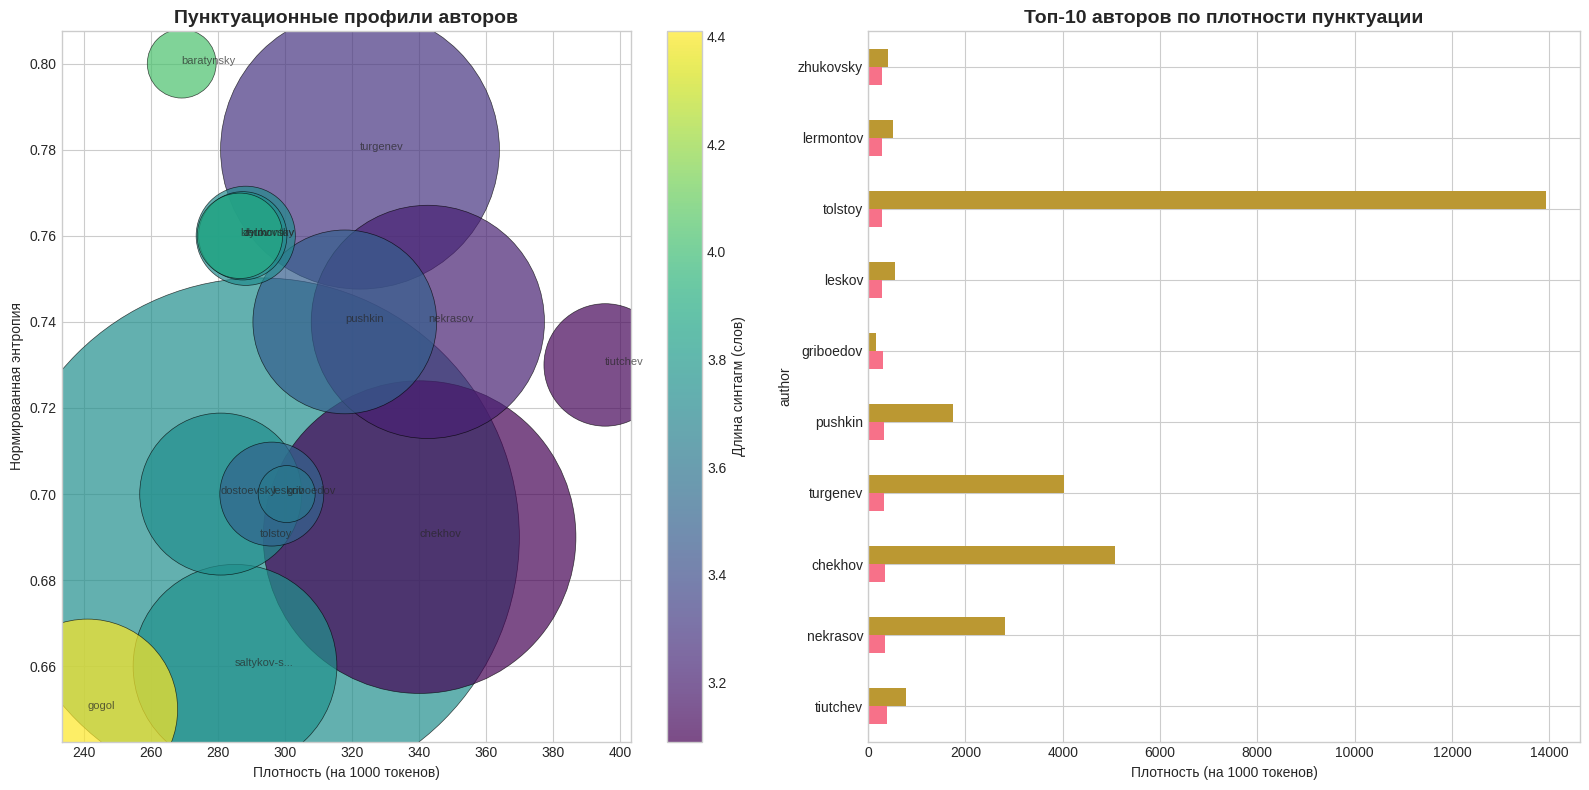


Тексты-выбросы

Найдено 2313 текстов-выбросов

        filename   author         category  total_tokens  density_per_1000_tokens  normalized_entropy  mean_words_between_all
 writing_542.xml nekrasov  writing_542.xml            22               136.363636            0.918296                6.500000
writing_1251.xml nekrasov writing_1251.xml           603               721.393035            0.779559                1.387097
writing_1318.xml nekrasov writing_1318.xml            21               666.666667            0.714956                1.538462
 writing_421.xml nekrasov  writing_421.xml            38                78.947368            0.918296                8.500000
writing_1263.xml nekrasov writing_1263.xml            25               640.000000            0.801466                1.600000
writing_2498.xml nekrasov writing_2498.xml            14               857.142857            0.822377                1.181818
 writing_456.xml nekrasov  writing_456.xml            21              

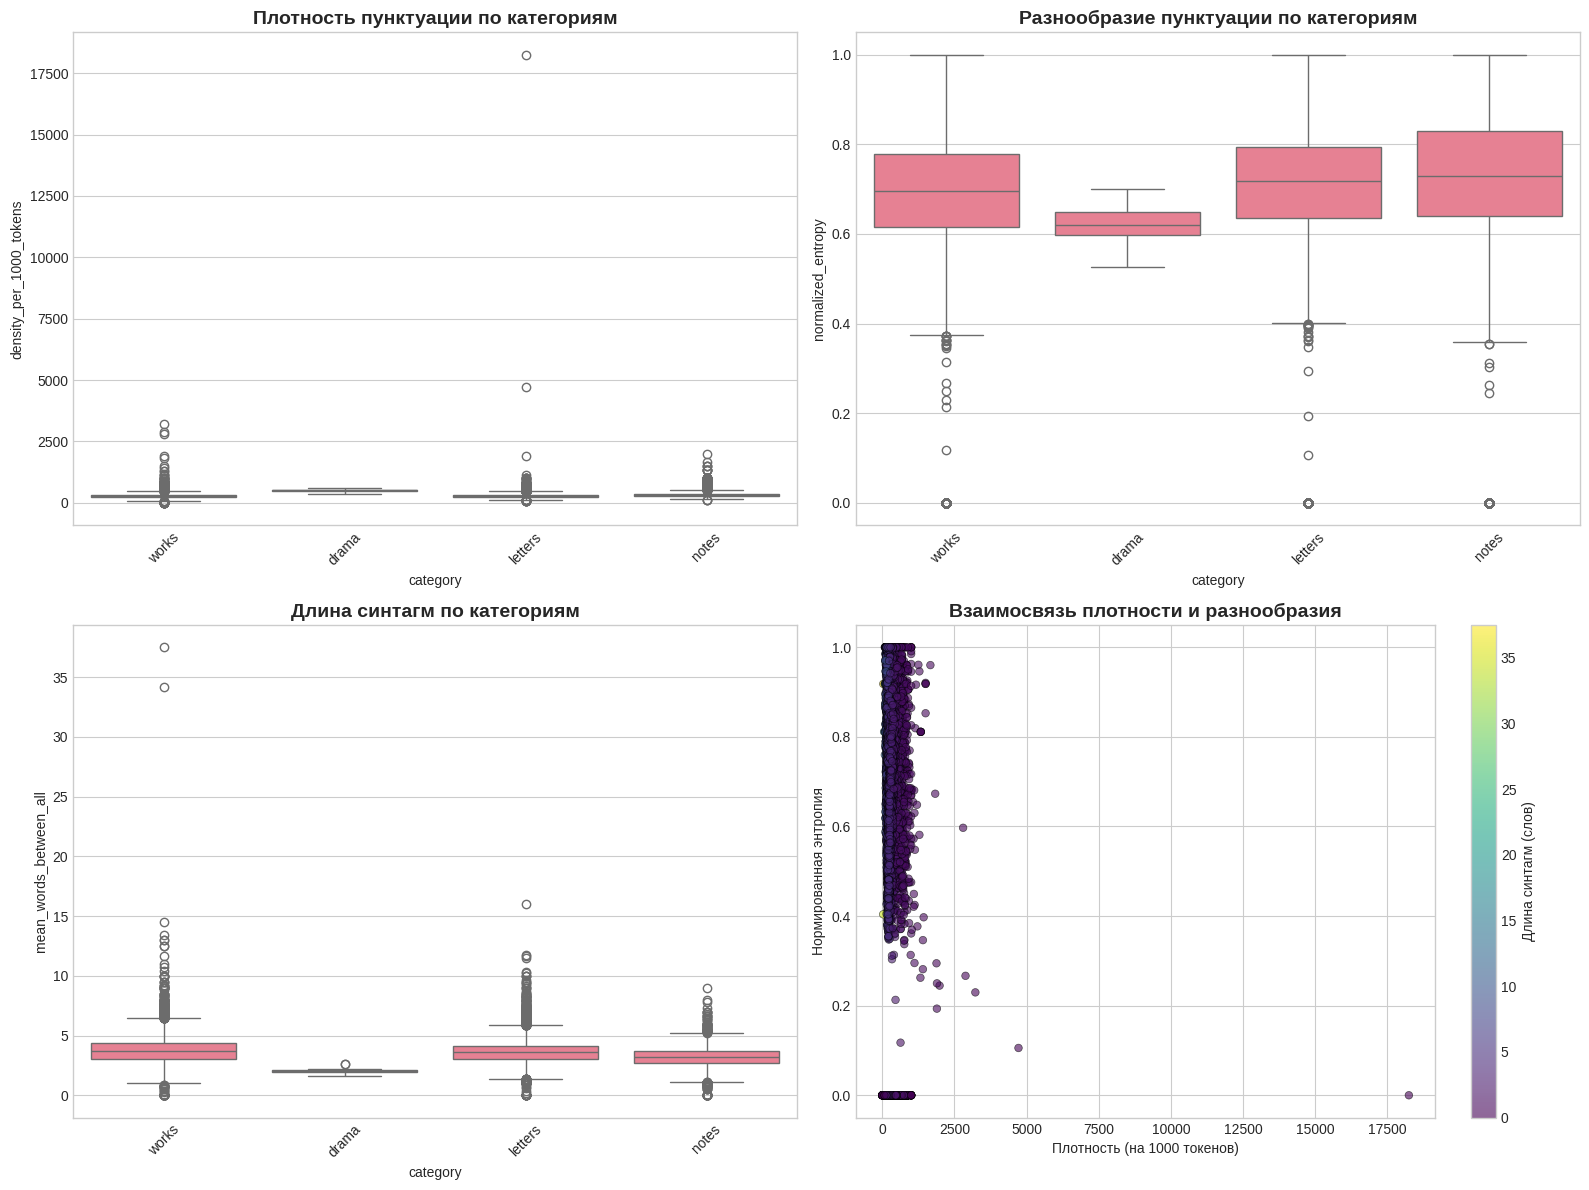


Корреляционная матрица метрик

График сохранён: classics_interpretation/correlation_matrix.png



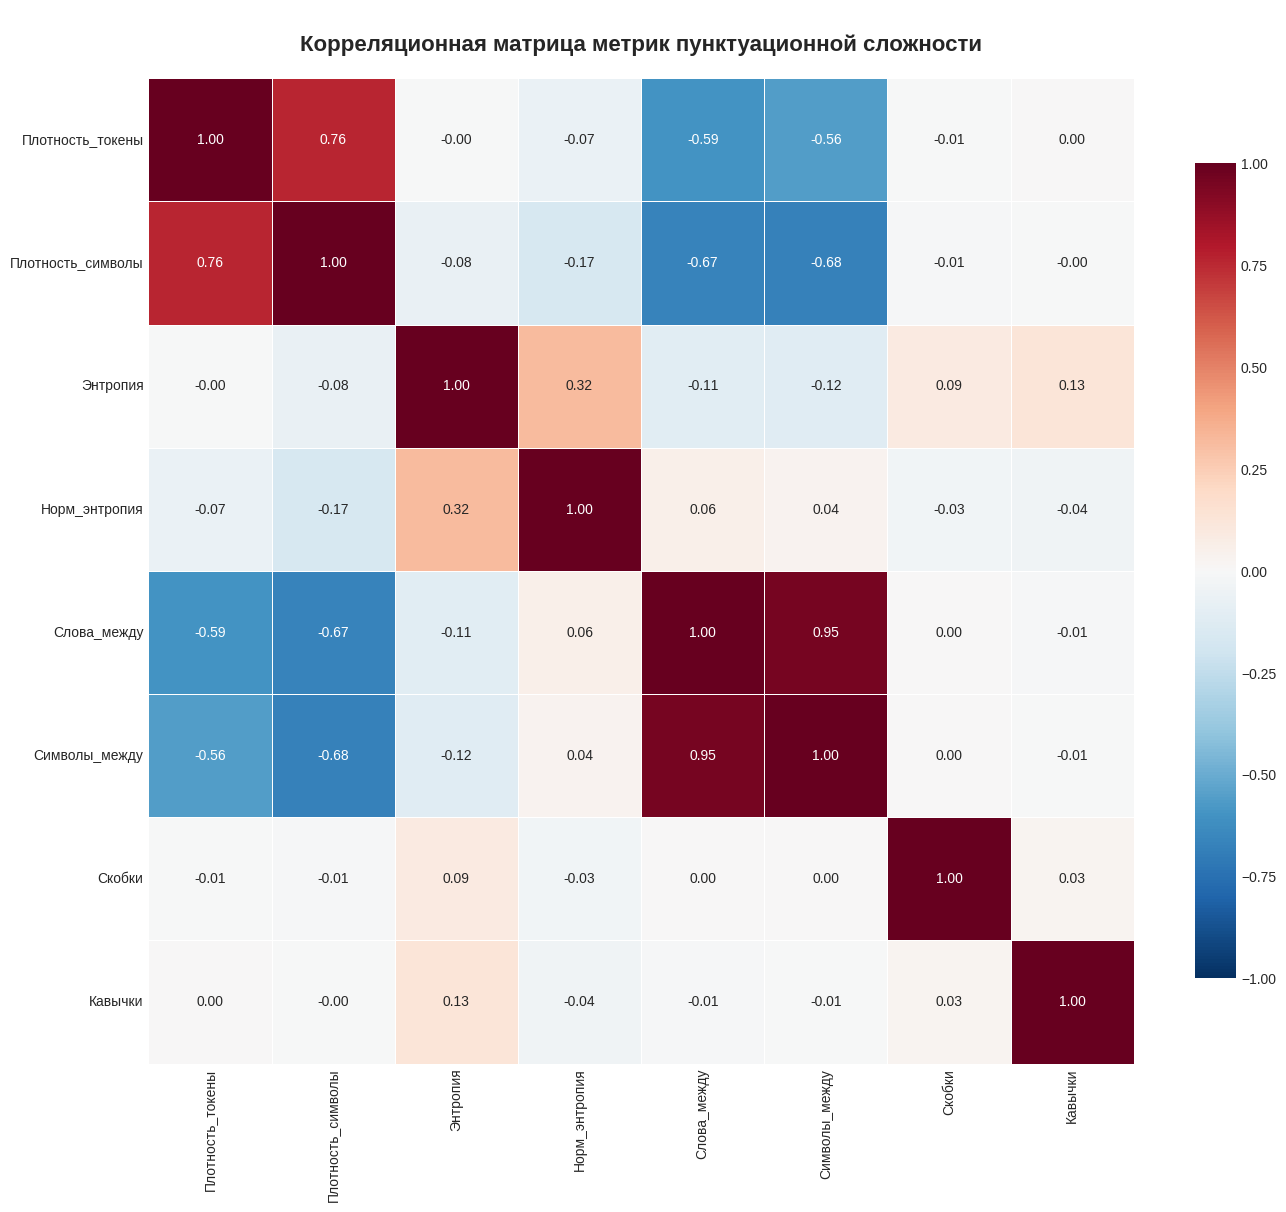


Корреляционная матрица (числовые значения):

                         density_per_1000_tokens  density_per_1000_chars  \
density_per_1000_tokens                    1.000                   0.761   
density_per_1000_chars                     0.761                   1.000   
entropy                                   -0.003                  -0.076   
normalized_entropy                        -0.067                  -0.166   
mean_words_between_all                    -0.594                  -0.665   
mean_chars_between_all                    -0.559                  -0.678   
parentheses_mean_tokens                   -0.008                  -0.014   
quotes_mean_tokens                         0.001                  -0.003   

                         entropy  normalized_entropy  mean_words_between_all  \
density_per_1000_tokens   -0.003              -0.067                  -0.594   
density_per_1000_chars    -0.076              -0.166                  -0.665   
entropy                    1.

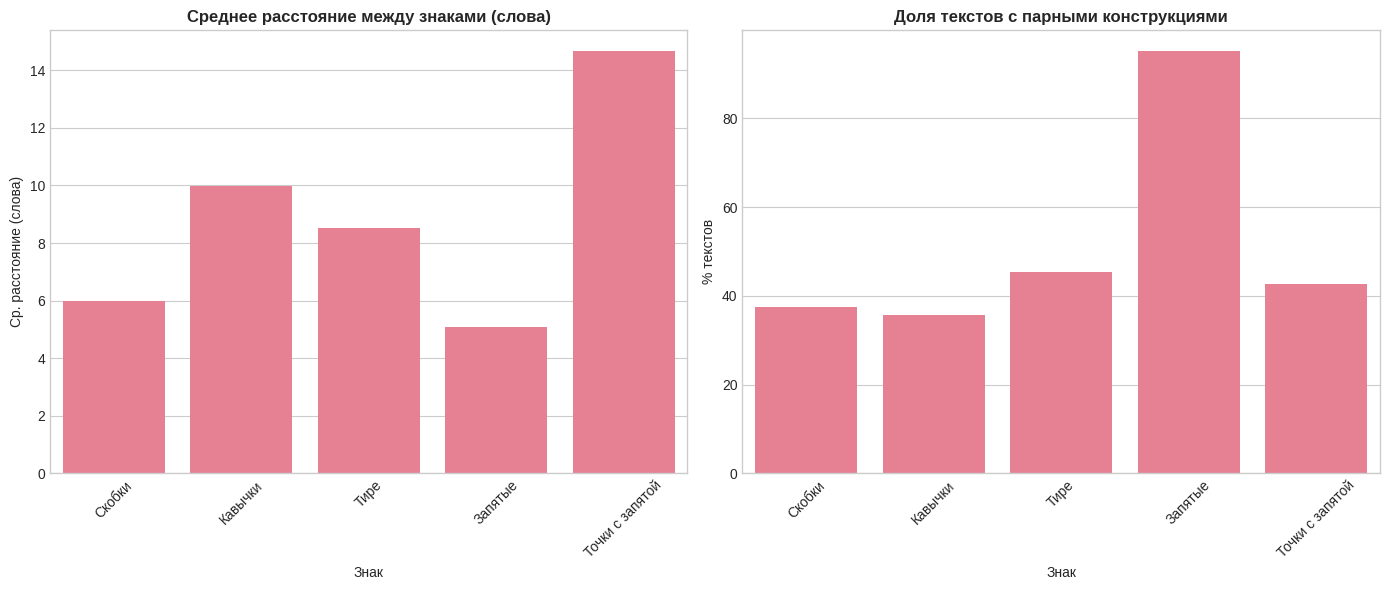


Результаты интерпретации сохранены: classics_interpretation/classics_with_interpretation.csv


In [ ]:
interpreter = ClassicsCorpusInterpreter(data_file)
interpreter.generate_full_report()

### Выводы по корпусу «Русская классика»

**Общая характеристика**

Средняя плотность пунктуации в корпусе «Русская классика» — 306,19 знаков на 1000 токенов, что близко к значениям, полученным для Обучающего корпуса (305,92) и корпуса «От 2 до 15» (306.14). Возможно, этот параметр в какой-то степени универсален для русского письменного текста.

Средняя нормированная энтропия — 0,707, средняя длина синтагматических отрезков — 3.57 слова. Эти метрики указывают на умеренное разнообразие знаков и среднюю длину отрезков между ними.

**Уровни пунктуационной сложности**

Более 62% текстов (22 412) характеризуются высокой пунктуационной сложностью, 30% — средней, 7,6% — низкой. Это говорит о том, что корпус состоит из текстов с развитой и разнообразной пунктуацией, что характерно для художественной литературы и публицистики.

**Методы расчёта**

Корреляция между плотностью на 1000 токенов и на 1000 символов равна 0,761 — ниже, чем в других корпусах.

Высокая корреляция (0,954) между длиной синтагм в словах и в символах подтверждает устойчивость этого показателя, как и в анализе других корпусов. При этом между «сырой» и нормированной энтропией корреляция низкая, что не было характерно для других корпусов. Это значит, что нормирование существенно меняет картину, делая показатели более сопоставимыми для текстов разной длины.

**Парные знаки препинания**

Запятые встречаются в 95,1% текстов. Среднее расстояние между ними — 5,1 слова.

Скобки и кавычки присутствуют примерно в трети текстов (37,5% и 35,6% соответственно). Средняя длина заключённого в них фрагмента — 5,98 слова для скобок и 9,97 слова для кавычек. Интересно, что конструкции с кавычками в среднем длиннее, чем со скобками.

Тире в парных конструкциях встречаются в 45,4% текстов со средним расстоянием в 8,52 слова между сосединими знаками. Этот показатель для также выше, чем для скобок.

Точки с запятой есть в 42,8% текстов. В среднем между ними 14,65 слова, что соответствует функции разделения крупных синтаксических блоков.

**Анализ категорий**

*Works (художественные произведения)*

Самая многочисленная категория (9508 текстов). Характеризуется очень высокой вариативностью длины текста (среднее 1658 слов, std 7870). Это объясняется наличием как коротких (стихи, басни, рассказы), так и объёмных произведений.

Плотность пунктуации — 291,85, энтропия — 0,687, длина синтагматических отрезков — 3,75 слова. Показатели близки к средним по корпусу.

*Drama (драма)*

В этой категории всего 16 текстов, но они резко выделяются на общем фоне. Плотность пунктуации (497,68 знака на 1000 токенов) почти в 1,6 раза выше средней по корпусу.

Длина синтагм равна 2,07 слова: знаки ставятся очень часто, что характерно для диалогической речи, ремарок и экспрессивного синтаксиса. Достаточно низкая энтропия (0,621) говорит о небольшом разнообразии знаков.

*Letters (письма)*

Самая крупная категория, в которую входит 16 731 текст. При этом длина текстов маленькая и составляет в среднем 201 слово.

Плотность пунктуации (293,71) и длина синтагматических отрезков (3,65) близки к средним показателям по корпусу, но энтропия выше (0,716). Это может объясняться большим разнообразием эмоционально-экспрессивных знаков в эпистолярном жанре.

*Notes (заметки)*

В этой категории 4579 текстов, средняя длина которых минимальна и равна 188 словам. Эти материалы также характеризуются самой высокой плотностью пунктуации по сравнению с другими категориями (351,08 знака на 1000 токенов), что согласуется с короткими синтагматическими отрезками (3,13 слова). Вероятно, авторы часто использовали знаки препинания, чтобы структурировать текст.

**Пунктуационные профили авторов**

Если пунктуационные профили авторов Обучающего корпуса оказались неинформативными, то для «Русской классики» можно выявить некоторые закономерности.

Самая высокая плотность пунктуации в словах на 1000 токенов у Н. С. Лескова (395,45), Л. Н. Толстого (340,11), И. С. Тургенева (342,57), А. П. Чехова (322,34). Их же тексты характеризуются наиболее короткими синтагматическими отрезками (от 3,09 до 3,29 слова). При этом самая низкая плотность (241,07 слова на 1000 токенов) и самые длинные синтагмы (4,41 слова) у А. С. Пушкина.

Наиболее разнообразная пунктуация исходя из нормированной энтропии у Е. А. Баратынского (0,8), А. С. Грибоедова (0,76), В. А. Жуковского (0,76) и М. Ю. Лермонтова (0,76).

Интересно, что у некоторых авторов — например, у Н. В. Гоголя, Ф. М. Достоевского — длина текстов очень вариативна (высокое стандартное отклонение). Это отражает разнообразие жанров в их творчестве.

**Корреляционный анализ**

Как отмечалось выше, видна сильная обратная связь между плотностью пунктуации и длиной синтагм (r = -0.59...-0.67); очень высокая корреляция между метриками парных знаков в словах и символах (r > 0.99 для скобок, кавычек, тире).

Энтропия практически не коррелирует с плотностью (r = -0.003), что указывает на независимость этих двух характеристик: одни и те же знаки препинания могут встречаться часто, а высокое разнообразие пунктуации может сочетаться с редкостью их постановки.

**Итог**

Корпус «Русская классика» — обширный и разнородный массив текстов, пунктуационные характеристики которых закономерно варьируются в зависимости от жанра (категории) и индивидуального стиля автора. Особенно выделяется категория drama с высокой плотностью пунктуации и короткими синтагмами, в то время как letters и notes характеризуются большей вариативностью, которая отражает спонтанность и жанровую свободу.

## Общие выводы

Средние показатели по корпусам достаточно близки друг к другу. С одной стороны, это может говорить об универсальности как минимум некоторых из них (например, плотности пунктуации). С другой — быть следствием того, что корпуса неоднородны с точки зрения жанров представленных в них текстов.

| Метрика | Обучающий | «От 2 до 15» | Классика |
|---------|-----------|--------------|----------|
| Плотность (знаков на 1000 токенов) | 305,92 | 306,14 | 306,19 |
| Нормированная энтропия | 0,713 | 0,620 | 0,707 |
| Длина синтагм (слов) | 3,59 | 3,32 | 3,57 |

Тексты, ориентированные на детей, закономерно смещены в сторону среднего уровня сложности, тогда как взрослые корпуса демонстрируют преобладание высокого уровня сложности. Это отражает процесс освоения пунктуационных норм, который учитывается в том числе при редактировании литературных произведений в издательствах.

| Корпус | Высокая сложность | Средняя сложность | Низкая сложность |
|--------|-------------------|-------------------|------------------|
| Обучающий | 65,8% (1294) | 30,7% (604) | 3,5% (68) |
| «От 2 до 15» | 16,0% (12) | 78,7% (59) | 5,3% (4) |
| Классика | 62,3% (22412) | 30,1% (10827) | 7,6% (2721) |

Во всех трёх корпусах устойчиво проявляются одни и те же корреляционные закономерности:

- Сильная отрицательная связь между плотностью пунктуации и длиной синтагм (r от -0,84 до -0,94): чем чаще ставятся знаки, тем короче отрезки между ними

- Высокая корреляция между метриками парных знаков в словах и символах (r > 0,93) — подтверждает надёжность измерений

- Слабая связь между плотностью и энтропией (r от 0,11 до -0,07): эти характеристики независимы: в тексте можно часто ставить одни и те же знаки, а можно редко ставить разные

Пунктуационные характеристики различаются в зависимости от функционального стиля:

| Стиль | Плотность | Длина синтагм | Энтропия |
|-------|-----------|----------------|----------|
| Официально-деловой | низкая (201,5) | высокая (5,41) | высокая (0,74) |
| Публицистика | ниже средней (243,4) | выше средней (4,42) | средняя (0,72) |
| Разговорный | средняя (304,3) | выше средней (3,70) | средняя (0,72) |
| Научный | высокая (316,5) | низкая (3,35) | высокая (0,75) |
| Художественный | высокая (356,9) | низкая (3,01) | низкая (0,64) |
| Драма | экстремально высокая (497,7) | экстремально низкая (2,07) | низкая (0,62) |

Из результатов анализа следует, что пунктуационную сложность в предложенной здесь трактовке можно считать устойчивой и информативной характеристикой текста, закономерно варьирующейся в зависимости от жанра, возраста целевой аудитории и индивидуального стиля автора.